# Transaccionalidad por estación de trabajo

Análisis de las fuentes de datos y modelo de proyección por sucursal: se le pasa un rango de
fechas y devuelve, para cada día, cada hora y cada estación de trabajo, la transaccionalidad
estimada.

## 1. Imports y configuración

Tres celdas: librerías, paleta/estilo de los gráficos y funciones auxiliares. Todavía no se
lee nada de disco.

In [1]:
# --- Librerías --------------------------------------------------------------
from __future__ import annotations

import os
import warnings

# Evita que loky sondee los núcleos físicos en Windows y ensucie la salida con un traceback
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

from scipy.stats import loguniform, randint
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (ExtraTreesRegressor, HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 200)

# En Windows, la primera vez que scikit-learn arranca su backend paralelo intenta contar los
# núcleos físicos con `wmic`, que ya no existe, e imprime un traceback en stderr. Se dispara
# aquí con un ajuste de juguete —el resultado queda en caché— para que no aparezca después
# en medio de la sección del modelo.
import contextlib, io
with contextlib.redirect_stderr(io.StringIO()):
    HistGradientBoostingRegressor(max_iter=2).fit(np.zeros((10, 1)), np.arange(10.0))

import sklearn
print(f"pandas {pd.__version__} | numpy {np.__version__} | "
      f"matplotlib {mpl.__version__} | scikit-learn {sklearn.__version__}")

pandas 2.1.4 | numpy 1.26.4 | matplotlib 3.8.0 | scikit-learn 1.7.2


### 1.1 Paleta y estilo

Paleta categórica de orden fijo, validada para daltonismo (ΔE CVD de al menos 8 y ΔE de visión normal
de al menos 15 entre pares adyacentes). El color se ata a la **entidad**, no al ranking: los mapas
sucursal→color y área→color se construyen una sola vez, así que filtrar una serie nunca
repinta a las demás. Para magnitud se usa una rampa de un solo tono, claro → oscuro.

In [2]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRIS_OTROS = "#898781"   # residuales, nunca un slot de serie

TINTA      = "#0b0b0b"
TINTA_2    = "#52514e"
TINTA_MUTE = "#898781"
REJILLA    = "#e1e0d9"
EJE        = "#c3c2b7"
SUPERFICIE = "#fcfcfb"

RAMPA = LinearSegmentedColormap.from_list(
    "azul_secuencial",
    ["#f5f9fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.bbox": "tight", "figure.dpi": 110,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial", "sans-serif"],
    "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 9,
    "axes.labelsize": 9.5, "axes.labelcolor": TINTA_2,
    "axes.edgecolor": EJE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": TINTA_MUTE, "ytick.color": TINTA_MUTE,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 1.8, "lines.markersize": 5,
})

print("Estilo aplicado.")

Estilo aplicado.


### 1.2 Funciones auxiliares

`num()` formatea a la colombiana (miles con `.`, decimales con `,`). `titulo_figura()` y
`leyenda_figura()` devuelven la fracción de figura a reservar arriba y abajo, para que el
título y la leyenda nunca se monten sobre los paneles ni queden recortados.

In [3]:
def _decimales(v):
    '''Decimales según magnitud: sin esto, un eje de 0 a 0,2 se rotula todo "0".'''
    a = abs(v)
    if a == 0 or a >= 10:
        return 0
    return 1 if a >= 1 else 2


def num(v, dec=None):
    '''Formato colombiano: 12.345,6'''
    if pd.isna(v):
        return "-"
    dec = _decimales(v) if dec is None else dec
    return f"{v:,.{dec}f}".replace(",", "|").replace(".", ",").replace("|", ".")


FMT_EJE = FuncFormatter(lambda v, _: num(v))


def marco(ax, titulo=None, xlabel=None, ylabel=None, y_miles=True):
    '''Título de panel + ejes recesivos, sin rejilla vertical.'''
    if titulo:
        ax.set_title(titulo)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.grid(axis="x", visible=False)
    if y_miles:
        ax.yaxis.set_major_formatter(FMT_EJE)
    return ax


def titulo_figura(fig, titulo, subtitulo=None):
    '''Título (y subtítulo) de figura. Devuelve el `top` para tight_layout.'''
    alto = fig.get_size_inches()[1]
    fig.text(0.004, 1 - 0.10 / alto, titulo, ha="left", va="top",
             fontsize=13, fontweight="semibold", color=TINTA)
    if subtitulo:
        fig.text(0.004, 1 - 0.34 / alto, subtitulo, ha="left", va="top",
                 fontsize=9, color=TINTA_MUTE)
    return 1 - (0.62 if subtitulo else 0.38) / alto


def leyenda_figura(fig, ax, ncol):
    '''Leyenda única bajo los paneles. Devuelve el `bottom` para tight_layout.'''
    alto = fig.get_size_inches()[1]
    manijas, etiquetas = ax.get_legend_handles_labels()
    fig.legend(manijas, etiquetas, ncol=ncol, loc="lower center",
               bbox_to_anchor=(0.5, 0.005), labelcolor=TINTA_2)
    filas = int(np.ceil(len(etiquetas) / max(ncol, 1)))
    return (0.16 + 0.20 * filas) / alto


def mapa_calor(ax, matriz, titulo, subtitulo=None, etiqueta_color="Transacciones",
               dec="auto", tam_anot=7.5):
    '''Heatmap secuencial de un solo tono, con el valor escrito en cada celda.

    Anotar cada celda es lo que evita que el valor dependa del color.
    '''
    datos = matriz.values.astype(float)
    vmax = float(np.nanmax(datos)) if datos.size else 1.0
    vmax = vmax if vmax > 0 else 1.0
    if dec == "auto":
        dec = 0 if vmax >= 20 else (1 if vmax >= 2 else 2)

    im = ax.imshow(datos, cmap=RAMPA, aspect="auto", vmin=0, vmax=vmax)
    ax.set_xticks(range(matriz.shape[1]))
    ax.set_xticklabels(matriz.columns, fontsize=8.5)
    ax.set_yticks(range(matriz.shape[0]))
    ax.set_yticklabels(matriz.index, fontsize=8.5)
    ax.grid(False, which="both")
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)

    # Separación entre celdas con el color de la superficie: un hueco, no un borde
    ax.set_xticks(np.arange(-0.5, matriz.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matriz.shape[0], 1), minor=True)
    ax.grid(which="minor", color=SUPERFICIE, linewidth=1.6)
    ax.tick_params(which="minor", length=0)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            v = datos[i, j]
            if np.isnan(v) or round(v, dec) == 0:
                continue
            ax.text(j, i, num(v, dec), ha="center", va="center", fontsize=tam_anot,
                    color="#ffffff" if v > 0.60 * vmax else TINTA_2)

    ax.set_title(titulo, pad=20 if subtitulo else 9)
    if subtitulo:
        ax.text(0, 1.012, subtitulo, transform=ax.transAxes, fontsize=9,
                color=TINTA_MUTE, va="bottom", ha="left")

    cb = ax.figure.colorbar(im, ax=ax, fraction=0.02, pad=0.012)
    cb.set_label(etiqueta_color, fontsize=8.5, color=TINTA_2)
    cb.ax.tick_params(labelsize=8, colors=TINTA_MUTE, length=0)
    cb.ax.yaxis.set_major_formatter(FMT_EJE)
    cb.outline.set_visible(False)
    return im


def guardar(fig, nombre):
    '''Guarda la figura como PNG si GUARDAR_FIGURAS está activo.'''
    if not GUARDAR_FIGURAS:
        return
    CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)
    fig.savefig(CARPETA_SALIDA / f"{nombre}.png", dpi=150)


print("Funciones auxiliares listas.")

Funciones auxiliares listas.


## 2. Parámetros globales

Todo lo configurable vive aquí.

In [4]:
# --- Entradas ---------------------------------------------------------------
BASE = Path(r"C:\Users\andre")

ARCHIVO_VENTAS = BASE / "venta_acumulada_2026-01_a_2026-09.csv"
ARCHIVO_EXCEL  = BASE / "Gestion_Personal_Documento_Ajustado_v8.xlsx"

HOJAS = {
    "sucursales":         "Sucursales",
    "areas":              "Areas y Estaciones",
    "estaciones_sucursal": "Estaciones Sucursal",
    "item_estacion":      "Estaciones x Item",
    "horarios":           "Horarios Sucursal",
    "productividad":      "Productividad",
}

# --- Salidas ----------------------------------------------------------------
CARPETA_SALIDA  = BASE / "salidas_modelo"
ARCHIVO_RESUMEN = CARPETA_SALIDA / "analisis_y_proyeccion.xlsx"
GUARDAR_FIGURAS = True

# --- Reglas de negocio ------------------------------------------------------
ZONA_HORARIA = "America/Bogota"   # la API entrega UTC

# Cantidades por encima de esto son errores de digitación, no ventas (ver la sección 4.2).
UMBRAL_ATIPICO = 500

# Una hora entra a la grilla del modelo si tuvo ventas en al menos este % de los días
# de ese día de la semana. Filtra horas sueltas sin descartar operación real (sección 7.3).
MIN_PRESENCIA_HORA = 0.10

SIN_ESTACION = "SIN ESTACION"
SIN_AREA     = "SIN AREA"

DIAS_ES = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
DIAS_CORTO = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

# --- Modelo -----------------------------------------------------------------
FRACCION_VALIDACION = 0.20   # último 20 % de las fechas, por fechas completas
SEMILLA = 0

print("Archivos de entrada:")
for r in (ARCHIVO_VENTAS, ARCHIVO_EXCEL):
    print(f"  {'OK   ' if r.exists() else 'FALTA'}  {r}")

Archivos de entrada:
  OK     C:\Users\andre\venta_acumulada_2026-01_a_2026-09.csv
  OK     C:\Users\andre\Gestion_Personal_Documento_Ajustado_v8.xlsx


## 3. Inventario de fuentes

Antes de analizar nada, la foto de qué hay disponible y qué se decide hacer con cada cosa.
Las hojas que se excluyen se listan también: un inventario que solo muestra lo que se usó no
permite auditar la decisión.

In [5]:
inventario = []

inventario.append({
    "fuente": ARCHIVO_VENTAS.name, "hoja": "-", "filas": None, "columnas": None,
    "uso": "SÍ", "para qué": "Historial de ventas: la demanda observada",
})

_xl = pd.ExcelFile(ARCHIVO_EXCEL)
_decisiones = {
    "Sucursales":          ("SÍ", "Catálogo id y nombre de sucursal"),
    "Areas y Estaciones":  ("SÍ", "Maestro estación → área de servicio"),
    "Estaciones Sucursal": ("SÍ", "Qué estaciones declara cada sucursal"),
    "Estaciones x Item":   ("SÍ", "Mapeo ítem del menú → estación que lo prepara"),
    "Horarios Sucursal":   ("SÍ", "Ventana operativa por sucursal y día"),
    "Productividad":       ("SÍ", "Benchmark de transacciones/hora por estación y nivel"),
    "Transacciones":       ("NO", "Regla de dotación por facturas: asignación de personal, no demanda"),
    "Empleados":           ("NO", "Fuera de alcance en esta etapa"),
    "Estaciones Empleado": ("NO", "Fuera de alcance en esta etapa"),
    "Sucursales Empleado": ("NO", "Fuera de alcance en esta etapa"),
    "Actividades":         ("NO", "Alistamiento de personal: fuera de alcance"),
    "Descansos":           ("NO", "Fuera de alcance en esta etapa"),
    "Hoja1":               ("NO", "Hoja de trabajo sin encabezados, con datos de empleados"),
}
for hoja in _xl.sheet_names:
    d = _xl.parse(hoja, nrows=0)
    uso, para = _decisiones.get(hoja, ("NO", "No revisada"))
    inventario.append({"fuente": ARCHIVO_EXCEL.name, "hoja": hoja, "filas": None,
                       "columnas": d.shape[1], "uso": uso, "para qué": para})

inventario = pd.DataFrame(inventario)
display(inventario.style.hide(axis="index"))

fuente,hoja,filas,columnas,uso,para qué
venta_acumulada_2026-01_a_2026-09.csv,-,None,nan,SÍ,Historial de ventas: la demanda observada
Gestion_Personal_Documento_Ajustado_v8.xlsx,Sucursales,None,8.000000,SÍ,Catálogo id y nombre de sucursal
Gestion_Personal_Documento_Ajustado_v8.xlsx,Areas y Estaciones,None,2.000000,SÍ,Maestro estación → área de servicio
Gestion_Personal_Documento_Ajustado_v8.xlsx,Estaciones Empleado,None,4.000000,NO,Fuera de alcance en esta etapa
Gestion_Personal_Documento_Ajustado_v8.xlsx,Estaciones x Item,None,2.000000,SÍ,Mapeo ítem del menú → estación que lo prepara
Gestion_Personal_Documento_Ajustado_v8.xlsx,Estaciones Sucursal,None,3.000000,SÍ,Qué estaciones declara cada sucursal
Gestion_Personal_Documento_Ajustado_v8.xlsx,Horarios Sucursal,None,6.000000,SÍ,Ventana operativa por sucursal y día
Gestion_Personal_Documento_Ajustado_v8.xlsx,Descansos,None,4.000000,NO,Fuera de alcance en esta etapa
Gestion_Personal_Documento_Ajustado_v8.xlsx,Hoja1,None,5.000000,NO,"Hoja de trabajo sin encabezados, con datos de empleados"
Gestion_Personal_Documento_Ajustado_v8.xlsx,Sucursales Empleado,None,2.000000,NO,Fuera de alcance en esta etapa


## 4. Fuente de ventas — `venta_acumulada_2026-01_a_2026-09.csv`

Una fila por **línea de venta**: qué ítem, cuántas unidades, en qué sucursal y en qué momento.
No trae estación ni área — eso sale del cruce con el Excel (sección 5).

### 4.1 Carga y tipado

`dia_de_la_venta` viene en **UTC** y en ISO8601 **con milisegundos en unas filas y sin ellos en
otras**. De ahí el `format="ISO8601"` explícito: sin él, pandas infiere el formato de la
primera fila y manda a `NaT` todo lo demás — en silencio si se usa `errors="coerce"`.

In [6]:
CATEGORICAS = ["item_id", "item_desc", "item_u_m", "periodo"]

ventas = pd.read_csv(ARCHIVO_VENTAS, encoding="utf-8-sig",
                     dtype={c: "category" for c in CATEGORICAS})
print(f"Leído {ARCHIVO_VENTAS.name}: {len(ventas):,} filas, {ARCHIVO_VENTAS.stat().st_size/1024**2:.1f} MB")
print("Columnas:", ventas.columns.tolist())

ventas["sucursal"] = ventas["sucursal"].astype("int16")
ventas["cantidad"] = pd.to_numeric(ventas["cantidad"], errors="coerce")

ts_utc = pd.to_datetime(ventas["dia_de_la_venta"], utc=True, format="ISO8601", errors="coerce")
print(f"\nTimestamps que no se pudieron parsear: {ts_utc.isna().sum()}")

# --- UTC -> hora local ------------------------------------------------------
local = ts_utc.dt.tz_convert(ZONA_HORARIA)
ventas["ts_local"] = local
ventas["fecha"] = local.dt.normalize().dt.tz_localize(None)
ventas["hora"]  = local.dt.hour.astype("int8")
ventas["dia_semana"] = ventas["fecha"].dt.dayofweek.astype("int8")

# El timestamp identifica el ticket: todas las líneas de un mismo pedido lo comparten
ventas["ticket"] = ventas["sucursal"].astype(str) + "_" + ts_utc.astype(str)

ventas.head(4)

Leído venta_acumulada_2026-01_a_2026-09.csv: 658,259 filas, 49.7 MB
Columnas: ['sucursal', 'dia_de_la_venta', 'item_id', 'item_desc', 'item_u_m', 'cantidad', 'periodo']

Timestamps que no se pudieron parsear: 0


,sucursal,dia_de_la_venta,item_id,item_desc,item_u_m,cantidad,periodo,ts_local,fecha,hora,dia_semana,ticket
0,116,2026-01-02 12:03:40.207000+00:00,8T0389,CAFE LATTE COLABORADORES,UND.,2,2026-01,2026-01-02 07:03:40.207000-05:00,2026-01-02,7,4,116_2026-01-02 12:03:40.207000+00:00
1,116,2026-01-02 13:39:05.993000+00:00,8P1095,AGUA SIERRA FRIA CON GAS,UND,1,2026-01,2026-01-02 08:39:05.993000-05:00,2026-01-02,8,4,116_2026-01-02 13:39:05.993000+00:00
2,116,2026-01-02 13:39:05.993000+00:00,8T0033,CAFÉ AMERICANO,UND.,1,2026-01,2026-01-02 08:39:05.993000-05:00,2026-01-02,8,4,116_2026-01-02 13:39:05.993000+00:00
3,116,2026-01-02 13:39:05.993000+00:00,8P1239,DESAYUNO PARMESSANO,UND.,1,2026-01,2026-01-02 08:39:05.993000-05:00,2026-01-02,8,4,116_2026-01-02 13:39:05.993000+00:00


### 4.2 Perfil y calidad

Cuatro revisiones: nulos, duplicados, cantidades negativas y cantidades atípicas.

**Las negativas se omiten.** Son anulaciones y devoluciones. Netean contra la venta original,
pero el reverso no siempre queda registrado en la misma hora que la venta, así que dentro de
una franja puede aparecer una carga negativa que operativamente no existe: si el plato se
preparó, el trabajo se hizo. Como pesan muy poco sobre el total, se descartan y cada franja
queda con su venta bruta.

In [7]:
print("Nulos por columna:")
_n = ventas.isna().sum().to_frame("nulos").query("nulos > 0")
display(_n if len(_n) else "Sin nulos en ninguna columna.")

_dup = ventas.duplicated(subset=["sucursal", "dia_de_la_venta", "item_id", "cantidad"]).sum()
print(f"\nFilas exactamente repetidas (sucursal+timestamp+ítem+cantidad): {_dup:,} "
      f"({_dup/len(ventas):.2%})")
print("  No se eliminan: un mismo ítem pedido dos veces en el mismo ticket es una venta real,")
print("  no un duplicado técnico. El POS no entrega número de línea para distinguirlos.")

print("\nDistribución de `cantidad`:")
display(ventas["cantidad"].describe().to_frame().T)

Nulos por columna:


'Sin nulos en ninguna columna.'


Filas exactamente repetidas (sucursal+timestamp+ítem+cantidad): 59,775 (9.08%)
  No se eliminan: un mismo ítem pedido dos veces en el mismo ticket es una venta real,
  no un duplicado técnico. El POS no entrega número de línea para distinguirlos.

Distribución de `cantidad`:


,count,mean,std,min,25%,50%,75%,max
cantidad,658259.0,1.09987,39.13009,-22222.0,1.0,1.0,1.0,22222.0


In [8]:
# --- Cantidades negativas: anulaciones y devoluciones -----------------------
negativas = ventas[ventas["cantidad"] < 0]
print(f"Filas con cantidad negativa: {len(negativas):,} ({len(negativas)/len(ventas):.2%}) · "
      f"{negativas['cantidad'].sum():,.0f} unidades")
display(negativas.groupby("sucursal")["cantidad"].agg(filas="size", unidades="sum"))
print(f"Peso sobre el total vendido: "
      f"{abs(negativas['cantidad'].sum()) / ventas.loc[ventas['cantidad'] > 0, 'cantidad'].sum():.2%}")
print("DECISIÓN: se omiten.\n")

_ceros = int((ventas["cantidad"] == 0).sum())
print(f"Filas con cantidad exactamente 0: {_ceros}\n")

# --- Atípicos: errores de digitación ---------------------------------------
atipicos = ventas[ventas["cantidad"].abs() > UMBRAL_ATIPICO]
print(f"Filas con |cantidad| > {UMBRAL_ATIPICO}: {len(atipicos)}")
display(atipicos[["sucursal", "fecha", "hora", "item_id", "item_desc", "cantidad"]]
        .sort_values(["item_id", "fecha"]))

Filas con cantidad negativa: 1,675 (0.25%) · -27,248 unidades


,filas,unidades
sucursal,,
116,527,-3749
117,1008,-23319
122,140,-180


Peso sobre el total vendido: 3.63%
DECISIÓN: se omiten.

Filas con cantidad exactamente 0: 0

Filas con |cantidad| > 500: 4


,sucursal,fecha,hora,item_id,item_desc,cantidad
62242,116,2026-02-02,14,8P1399,ENSALADA GRIEGA POLLO,3163
62299,116,2026-02-02,16,8P1399,ENSALADA GRIEGA POLLO,-3163
30848,117,2026-01-08,19,8T0324,POR. FLAN DE LECHE,22222
30986,117,2026-01-08,20,8T0324,POR. FLAN DE LECHE,-22222


**Los atípicos son dos pares de digitación errada**, cada uno cargado y luego reversado:
`±22.222` en un flan de leche de la 117 y `±3.163` en una ensalada griega de la 116. El reverso
ya cae con las negativas; el cargo hay que quitarlo aparte, porque si no, una sola celda se
lleva por delante el perfil horario de esa sucursal.

El umbral de 500 los elimina y conserva pedidos grandes legítimos (160 cocadas, 53 pandeyucas).

In [9]:
antes = len(ventas)
ventas = ventas.dropna(subset=["fecha", "cantidad"])
ventas = ventas[(ventas["cantidad"] > 0) & (ventas["cantidad"] <= UMBRAL_ATIPICO)]
ventas = ventas.reset_index(drop=True)
print(f"AJUSTE: {antes - len(ventas):,} filas descartadas "
      f"(negativas, ceros y atípicas) -> quedan {len(ventas):,}")
print(f"Unidades en el universo de trabajo: {ventas['cantidad'].sum():,.0f}")

AJUSTE: 1,677 filas descartadas (negativas, ceros y atípicas) -> quedan 656,582
Unidades en el universo de trabajo: 725,862


### 4.3 Cobertura temporal

Las sucursales **no cubren el mismo periodo**. Por eso todas las comparaciones de este notebook
van en promedio por día operativo, nunca en totales, y por eso cada modelo se entrena con su
propio historial.

In [10]:
cobertura = ventas.groupby("sucursal").agg(
    lineas=("fecha", "size"), desde=("fecha", "min"), hasta=("fecha", "max"),
    dias_con_venta=("fecha", "nunique"), items=("item_id", "nunique"),
    tickets=("ticket", "nunique"), unidades=("cantidad", "sum"),
)
cobertura["dias_calendario"] = (cobertura["hasta"] - cobertura["desde"]).dt.days + 1
cobertura["dias_sin_venta"] = cobertura["dias_calendario"] - cobertura["dias_con_venta"]
display(cobertura)

SUCURSALES = sorted(ventas["sucursal"].unique().tolist())
COLOR_SUC = {suc: SERIES[i] for i, suc in enumerate(SUCURSALES)}
print(f"Sucursales con ventas: {SUCURSALES}")

,lineas,desde,hasta,dias_con_venta,items,tickets,unidades,dias_calendario,dias_sin_venta
sucursal,,,,,,,,,
116,246048,2026-01-02,2026-09-09,251,495,46392,270252,251,0
117,328120,2026-01-02,2026-09-09,251,490,57911,358095,251,0
122,82414,2026-05-27,2026-09-09,106,403,14966,97515,106,0


Sucursales con ventas: [116, 117, 122]


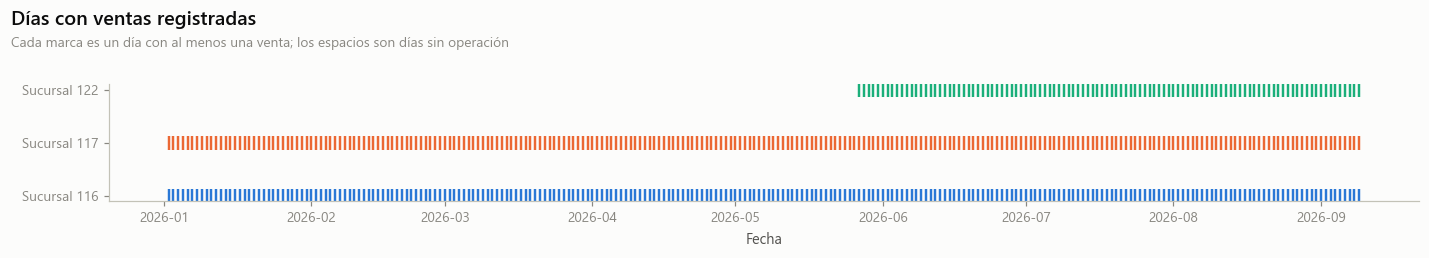

In [11]:
# Calendario de días con venta: deja ver los huecos, que un min/max no muestra
fig, ax = plt.subplots(figsize=(13, 2.4))
for i, suc in enumerate(SUCURSALES):
    dias = sorted(ventas.loc[ventas["sucursal"] == suc, "fecha"].unique())
    ax.scatter(dias, [i] * len(dias), marker="|", s=90, linewidths=1.6, color=COLOR_SUC[suc])
ax.set_yticks(range(len(SUCURSALES)))
ax.set_yticklabels([f"Sucursal {s}" for s in SUCURSALES])
marco(ax, xlabel="Fecha", y_miles=False)
ax.grid(axis="y", visible=False)
top = titulo_figura(fig, "Días con ventas registradas",
                    "Cada marca es un día con al menos una venta; los espacios son días sin operación")
fig.tight_layout(rect=[0, 0, 1, top])
guardar(fig, "04_cobertura_dias")
plt.show()

### 4.4 Concentración de la demanda por ítem

Cuánto del volumen explica cuántos ítems. Importa para el modelo: si la demanda se concentra
en pocos productos, la cola larga del menú no aporta señal y el ruido que mete es puro costo.

108 de 515 ítems (21.0%) explican el 80 % de las unidades.
Los 5 más vendidos concentran el 18.1% del total.


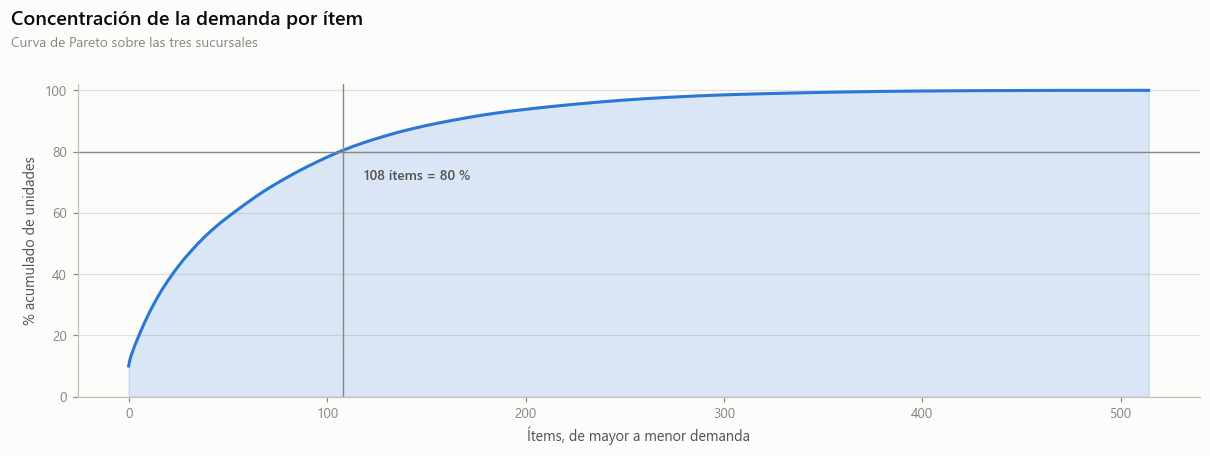

,,unidades
item_id,item_desc,
8P0295,CORTESIA PARMESSANO,72642
8T0033,CAFÉ AMERICANO,21173
8T0389,CAFE LATTE COLABORADORES,13120
8P1461,MAR Y TIERRA CON RES,12984
8P1094,AGUA DE NACIMIENTO,11529
8P0379,LIMONADA NATURAL FRAPPÉ,11453
8T0132,PANDEYUCA,11016
8T0254,MANDARINA NATURAL,10856
8P0252,SODA SANDIA,10473


In [12]:
por_item = ventas.groupby("item_id", observed=True)["cantidad"].sum().sort_values(ascending=False)
por_item = por_item[por_item > 0]
acumulado = por_item.cumsum() / por_item.sum()
n80 = int((acumulado <= 0.80).sum()) + 1

print(f"{n80} de {len(por_item)} ítems ({n80/len(por_item):.1%}) explican el 80 % de las unidades.")
print(f"Los 5 más vendidos concentran el {acumulado.iloc[4]:.1%} del total.")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(range(len(por_item)), acumulado.values * 100, color=SERIES[0], alpha=0.16)
ax.plot(range(len(por_item)), acumulado.values * 100, color=SERIES[0], lw=2)
ax.axhline(80, color=TINTA_MUTE, lw=0.9)
ax.axvline(n80, color=TINTA_MUTE, lw=0.9)
ax.annotate(f"{n80} ítems = 80 %", xy=(n80, 80), xytext=(14, -18),
            textcoords="offset points", fontsize=9, color=TINTA_2, fontweight="semibold")
marco(ax, xlabel="Ítems, de mayor a menor demanda", ylabel="% acumulado de unidades")
ax.set_ylim(0, 102)
top = titulo_figura(fig, "Concentración de la demanda por ítem",
                    "Curva de Pareto sobre las tres sucursales")
fig.tight_layout(rect=[0, 0, 1, top])
guardar(fig, "04_pareto_items")
plt.show()

display(
    ventas.groupby(["item_id", "item_desc"], observed=True)["cantidad"].sum()
    .sort_values(ascending=False).head(10).to_frame("unidades")
)

### Resumen — la fuente de ventas

658.259 líneas de venta entre el 2 de enero y el 9 de septiembre de 2026. Tres sucursales, 515
ítems. Sin nulos y sin días faltantes: las tres operaron todos los días de su periodo, 251 días
Atlantis y Santafé, 106 Atrio, que arranca el 27 de mayo.

Se descartaron 1.677 filas, el 0,25 % del total:

| Qué se quitó | Por qué |
|---|---|
| Anulaciones (cantidad negativa) | El reverso no siempre queda en la misma hora que la venta |
| 2 cargos de digitación errada | 22.222 y 3.163 unidades; una sola celda arrastraba el perfil horario de su sucursal |

Quedan 725.862 unidades. Las anulaciones pesaban 3,6 % del volumen, así que el total queda algo
por encima de la venta neta.

Dos ajustes más, sin pérdida de filas: los timestamps se leen con `format="ISO8601"` porque
vienen con y sin milisegundos, y se convierten de UTC a hora local.

**Concentración por ítem.** 108 de 515 ítems explican el 80 % de las unidades. Los 5 más
vendidos, solo el 18 %. No hay un producto que domine, así que modelar por ítem no aporta: el
nivel correcto es la estación.

## 5. Maestros del Excel

Seis hojas, una subsección cada una. Antes hay que resolver un problema transversal: las hojas
**no cruzan por el mismo campo**. `Estaciones Sucursal` y `Horarios Sucursal` usan el *nombre*
de la sucursal, no el id, y usan variantes ("Parmessano Atlantis" vs. "Parmessano Atlantis
Bogota"). Y los nombres de estación traen espacios dobles y capitalización mixta.

Sin normalizadores, esos cruces pierden filas **en silencio**: no fallan, simplemente devuelven
menos filas de las que deberían.

### 5.1 Normalizadores

In [13]:
import unicodedata


def sin_tildes(s):
    if not isinstance(s, str):
        return s
    return "".join(c for c in unicodedata.normalize("NFD", s)
                   if unicodedata.category(c) != "Mn")


def clave_sucursal(nombre):
    '''Clave robusta: sin tildes, sin "parmessano", sin "bogota", sin espacios sobrantes.'''
    if not isinstance(nombre, str):
        return nombre
    s = sin_tildes(nombre).lower().replace("parmessano", "").replace("bogota", "")
    return " ".join(s.split()).strip()


def limpia_estacion(nombre):
    '''Colapsa espacios dobles y recorta. NO cambia la capitalización: el maestro de áreas
    usa "preparacion de bebidas" en minúscula y hay que poder cruzar textualmente con él.'''
    if not isinstance(nombre, str):
        return nombre
    return " ".join(nombre.split()).strip()


def clave_estacion(nombre):
    '''Clave para comparar catálogos entre sí (ahí sí ignorando mayúsculas y tildes).'''
    return sin_tildes(limpia_estacion(nombre)).lower() if isinstance(nombre, str) else nombre


print("Ejemplos:")
for n in ["Parmessano Atlantis Bogota", "Parmessano Atlantis", "Parmessano Santafe Bogota"]:
    print(f"  {n!r:36} -> {clave_sucursal(n)!r}")
for n in ["patinador de  Comidas ", "preparacion de bebidas", "Panaderia Y Reposteria"]:
    print(f"  {n!r:36} -> {limpia_estacion(n)!r}")

Ejemplos:
  'Parmessano Atlantis Bogota'         -> 'atlantis'
  'Parmessano Atlantis'                -> 'atlantis'
  'Parmessano Santafe Bogota'          -> 'santafe'
  'patinador de  Comidas '             -> 'patinador de Comidas'
  'preparacion de bebidas'             -> 'preparacion de bebidas'
  'Panaderia Y Reposteria'             -> 'Panaderia Y Reposteria'


### 5.2 `Sucursales` — catálogo id y nombre

In [14]:
sucursales = pd.read_excel(ARCHIVO_EXCEL, sheet_name=HOJAS["sucursales"])
sucursales["Id de la Sucursal"] = sucursales["Id de la Sucursal"].astype(int)
sucursales["clave"] = sucursales["Nombre de la sucursal"].map(clave_sucursal)

ID_A_NOMBRE = dict(zip(sucursales["Id de la Sucursal"], sucursales["Nombre de la sucursal"]))
CLAVE_A_ID  = dict(zip(sucursales["clave"], sucursales["Id de la Sucursal"]))

# Etiqueta corta para las tablas: "116 Atlantis" en vez de un número suelto.
def etiqueta_sucursal(suc):
    corto = (ID_A_NOMBRE.get(suc, "").replace("Parmessano", "").replace("Bogota", "").strip())
    return f"{suc} {corto}".strip()

ETIQUETA_SUC = {suc: etiqueta_sucursal(suc) for suc in SUCURSALES}
print("Etiquetas:", list(ETIQUETA_SUC.values()))

sucursales["tiene_ventas"] = sucursales["Id de la Sucursal"].isin(SUCURSALES)
display(sucursales[["Id de la Sucursal", "Nombre de la sucursal", "Municipio",
                    "Es franquicia", "tiene_ventas"]].style.hide(axis="index"))

_faltan = sucursales.loc[~sucursales["tiene_ventas"], "Nombre de la sucursal"].tolist()
print(f"HALLAZGO: el maestro tiene {len(sucursales)} sucursales pero solo {len(SUCURSALES)} "
      f"registran ventas en el archivo.")
print(f"  Sin datos de venta: {_faltan}")
print("  No se pueden modelar. Si se necesitan, hay que pedir su historial a la API.")

Etiquetas: ['116 Atlantis', '117 Santafe', '122 Atrio']


Id de la Sucursal,Nombre de la sucursal,Municipio,Es franquicia,tiene_ventas
117,Parmessano Santafe Bogota,Bogota D.C.,No,True
119,Parmessano Gran Estacion,Bogota D.C.,No,False
121,Parmessano Nuestro Bogota,Bogota D.C.,No,False
116,Parmessano Atlantis,Bogota D.C.,No,True
122,Parmessano Atrio,Bogota D.C.,No,True
123,Parmessano Unicentro,Bogota D.C.,No,False


HALLAZGO: el maestro tiene 6 sucursales pero solo 3 registran ventas en el archivo.
  Sin datos de venta: ['Parmessano Gran Estacion', 'Parmessano Nuestro Bogota', 'Parmessano Unicentro']
  No se pueden modelar. Si se necesitan, hay que pedir su historial a la API.


### 5.3 `Areas y Estaciones` — maestro de áreas de servicio

In [15]:
areas = pd.read_excel(ARCHIVO_EXCEL, sheet_name=HOJAS["areas"])
areas = areas[["Area de servicio", "Estacion"]].rename(
    columns={"Area de servicio": "area", "Estacion": "estacion"})
for c in ("area", "estacion"):
    areas[c] = areas[c].map(limpia_estacion)
areas = areas[~areas["estacion"].isin(["nan", "None", ""])].dropna()

_dups = areas["estacion"].duplicated().sum()
areas = areas.drop_duplicates("estacion").reset_index(drop=True)
print(f"{len(areas)} estaciones en {areas['area'].nunique()} áreas "
      f"({_dups} duplicados eliminados).")

MAPA_AREA = dict(zip(areas["estacion"], areas["area"]))
display(areas.groupby("area")["estacion"].agg(n="size", detalle=lambda s: " · ".join(sorted(s))))

19 estaciones en 6 áreas (0 duplicados eliminados).


,n,detalle
area,,
Bar,2,Jugos · Sodas
Cocina 1,4,Cocina Fria · Freidora / Apanados · Parrilla ·...
Cocina 2,2,Pastas · Risottos
Cocina 3,2,Stewart · Stoker
Salon,6,Caja / Toma Pedidos · Fila ( Hostes ) · Pasa C...
Todo Fresa,3,Caja · Panaderia Y Reposteria · preparacion de...


### 5.4 `Estaciones Sucursal` — qué estaciones declara cada sucursal

In [16]:
est_suc = pd.read_excel(ARCHIVO_EXCEL, sheet_name=HOJAS["estaciones_sucursal"])
est_suc = est_suc.rename(columns={"Nombre de la sucursal": "nombre",
                                  "Area de servicio": "area", "Estacion": "estacion"})
est_suc["estacion"] = est_suc["estacion"].map(limpia_estacion)
est_suc["sucursal"] = est_suc["nombre"].map(clave_sucursal).map(CLAVE_A_ID)

_sin_match = est_suc["sucursal"].isna().sum()
print(f"Filas: {len(est_suc)} · sucursales que no cruzaron con el catálogo: {_sin_match}")
print("  (el normalizador de la sección 5.1 es lo que evita que esto sea > 0)\n")

_por_suc = est_suc.groupby("nombre")["estacion"].agg(n="size", firma=lambda s: tuple(sorted(s)))
print("Estaciones declaradas por sucursal:")
display(_por_suc["n"].to_frame("estaciones declaradas"))
_conjuntos = _por_suc["firma"].nunique()
print(f"HALLAZGO: entre las {len(_por_suc)} sucursales hay {_conjuntos} conjunto(s) distinto(s) "
      "de estaciones.")
print("  El maestro es PLANO: todas declaran exactamente las mismas 19 estaciones.")
print("  Por eso NO sirve para recortar la grilla por sucursal; se usa solo como validación.")

Filas: 114 · sucursales que no cruzaron con el catálogo: 0
  (el normalizador de la sección 5.1 es lo que evita que esto sea > 0)

Estaciones declaradas por sucursal:


,estaciones declaradas
nombre,
Parmessano Atlantis,19
Parmessano Atrio,19
Parmessano Gran Estacion,19
Parmessano Nuestro Bogota,19
Parmessano Santafe Bogota,19
Parmessano Unicentro,19


HALLAZGO: entre las 6 sucursales hay 1 conjunto(s) distinto(s) de estaciones.
  El maestro es PLANO: todas declaran exactamente las mismas 19 estaciones.
  Por eso NO sirve para recortar la grilla por sucursal; se usa solo como validación.


**Consecuencia de diseño.** Como el maestro no diferencia sucursales, las estaciones de cada
modelo se toman de **las que realmente registran ventas en esa sucursal**, y el maestro queda
como control: sirve para ver cuántas de las 19 declaradas no mueven nada.

### 5.5 `Estaciones x Item` — mapeo ítem del menú → estación

Es la hoja que convierte una venta en carga de trabajo. Tres cosas que revisar: duplicados,
cobertura sobre lo que realmente se vende, e ítems que afectan más de una estación.

In [17]:
item_est = pd.read_excel(ARCHIVO_EXCEL, sheet_name=HOJAS["item_estacion"])
item_est = item_est[["Item del menu", "Estacion afectada"]].rename(
    columns={"Item del menu": "item_id", "Estacion afectada": "estacion"})
item_est["item_id"] = item_est["item_id"].astype(str).str.strip()
item_est["estacion"] = item_est["estacion"].map(limpia_estacion)

_crudas = len(item_est)
item_est = item_est.dropna(subset=["estacion"])
item_est = item_est[~item_est["estacion"].isin(["nan", "None", ""])]
item_est = item_est.drop_duplicates(["item_id", "estacion"]).reset_index(drop=True)
print(f"AJUSTE: {_crudas} filas crudas -> {len(item_est)} pares ítem-estación únicos "
      f"({_crudas - len(item_est)} duplicados o vacíos eliminados).")

# --- ¿Las estaciones del mapeo existen en el maestro de áreas? --------------
_mapeo = set(item_est["estacion"].map(clave_estacion))
_maestro = set(areas["estacion"].map(clave_estacion))
_huerfanas = sorted(item_est.loc[~item_est["estacion"].map(clave_estacion).isin(_maestro),
                                 "estacion"].unique())
print(f"\nEstaciones del mapeo que NO están en 'Areas y Estaciones': {_huerfanas or 'ninguna'}")

AJUSTE: 444 filas crudas -> 435 pares ítem-estación únicos (9 duplicados o vacíos eliminados).

Estaciones del mapeo que NO están en 'Areas y Estaciones': ['Licores']


In [18]:
# --- Cobertura: medida en UNIDADES, no solo en número de ítems --------------
ITEMS_CATALOGO = set(item_est["item_id"])
ventas["mapeado"] = ventas["item_id"].astype(str).isin(ITEMS_CATALOGO)

_tot = ventas.groupby("sucursal").agg(
    items_vendidos=("item_id", "nunique"), unidades=("cantidad", "sum"))
_falt = (ventas[~ventas["mapeado"]].groupby("sucursal")
         .agg(items_sin_mapeo=("item_id", "nunique"), unidades_sin_mapeo=("cantidad", "sum")))

_res = _tot.join(_falt).fillna(0)
_res["% items_sin_mapeo"] = 100 * _res["items_sin_mapeo"] / _res["items_vendidos"]
_res["% unidades_sin_mapeo"] = 100 * _res["unidades_sin_mapeo"] / _res["unidades"]
_res = _res[["items_vendidos", "items_sin_mapeo", "% items_sin_mapeo",
             "unidades", "unidades_sin_mapeo", "% unidades_sin_mapeo"]]

display(_res.style.format({"items_vendidos": "{:,.0f}", "items_sin_mapeo": "{:,.0f}",
                           "% items_sin_mapeo": "{:,.1f} %", "unidades": "{:,.0f}",
                           "unidades_sin_mapeo": "{:,.0f}", "% unidades_sin_mapeo": "{:,.1f} %"}))

items_sin_estacion = (
    ventas[~ventas["mapeado"]].groupby(["item_id", "item_desc"], observed=True)
    .agg(unidades=("cantidad", "sum"), lineas=("cantidad", "size"),
         sucursales=("sucursal", "nunique"))
    .sort_values("unidades", ascending=False).reset_index()
)
print(f"\n>>> {len(items_sin_estacion)} ítems distintos no se mueven en NINGUNA estación, "
      f"y suman {items_sin_estacion['unidades'].sum():,.0f} unidades "
      f"({100*items_sin_estacion['unidades'].sum()/ventas['cantidad'].sum():.1f} % del total).")
print("Son los que hay que mapear en la hoja 'Estaciones x Item'. Top 15 por volumen:")
display(items_sin_estacion.head(15).style.format(
    {"unidades": "{:,.0f}", "lineas": "{:,.0f}"}).hide(axis="index"))

,items_vendidos,items_sin_mapeo,% items_sin_mapeo,unidades,unidades_sin_mapeo,% unidades_sin_mapeo
sucursal,,,,,,
116,495,122,24.6 %,"270,252","15,052",5.6 %
117,490,117,23.9 %,"358,095","25,456",7.1 %
122,403,39,9.7 %,"97,515",711,0.7 %



>>> 134 ítems distintos no se mueven en NINGUNA estación, y suman 41,219 unidades (5.7 % del total).
Son los que hay que mapear en la hoja 'Estaciones x Item'. Top 15 por volumen:


item_id,item_desc,unidades,lineas,sucursales
8P0505,MIXTO MAR Y TIERRA,"3,271","3,079",2
8P0191,MIXTO ARBOREA,"2,594","2,517",2
8P0434,CORDON BLUE FLORENTINO,"2,253","2,116",2
8P0195,MIXTO DE SALMON,"2,128","2,047",2
8P1441,VO-LATTE,"2,122","1,896",2
8P0125,CORDON BLEU CARBONARA,"1,572","1,507",2
8P0100,CAMARON Y POLLO CARBONARA,"1,571","1,517",2
8P0216,POLLO A LA MILANESA,"1,460","1,403",2
8P0331,SPAGHETTI PASTA COMPLETA,"1,403","1,376",2
8P1299,RISOTTO TRUFADO,"1,401","1,363",2


In [19]:
# --- Ítems multi-estación: el efecto de réplica ----------------------------
n_est_por_item = item_est.groupby("item_id")["estacion"].nunique()
print("Ítems del catálogo según cuántas estaciones afectan:")
display(n_est_por_item.value_counts().sort_index().rename_axis("n_estaciones").to_frame("items"))

_vend = ventas[ventas["mapeado"]].copy()
_vend["n_est"] = _vend["item_id"].astype(str).map(n_est_por_item)
_replica = (_vend["cantidad"] * _vend["n_est"]).sum() / _vend["cantidad"].sum()
print(f"\nFactor de réplica sobre lo realmente vendido: {_replica:.3f}")
print("  Es decir: la carga total de las estaciones es ~"
      f"{(_replica-1)*100:.1f} % mayor que las unidades vendidas, porque un plato que pasa")
print("  por 3 estaciones le genera trabajo a las 3. Es el comportamiento correcto.")

print("\nÍtems del catálogo que nunca se vendieron en el periodo:")
_nunca = sorted(ITEMS_CATALOGO - set(ventas["item_id"].astype(str)))
print(f"  {len(_nunca)} ítems. Primeros 15: {_nunca[:15]}")

Ítems del catálogo según cuántas estaciones afectan:


,items
n_estaciones,
1,336
2,39
3,7



Factor de réplica sobre lo realmente vendido: 1.199
  Es decir: la carga total de las estaciones es ~19.9 % mayor que las unidades vendidas, porque un plato que pasa
  por 3 estaciones le genera trabajo a las 3. Es el comportamiento correcto.

Ítems del catálogo que nunca se vendieron en el periodo:
  1 ítems. Primeros 15: ['8P0387']


### 5.6 `Horarios Sucursal` — ventana operativa

Define a qué horas opera cada sucursal **cada día de la semana**. Es información que ningún
notebook anterior del proyecto estaba usando, y sí varía: viernes y sábado cierran más tarde,
domingo más temprano.

In [20]:
DIA_EXCEL_A_NUM = {"LUNES": 0, "MARTES": 1, "MIERCOLES": 2, "MIÉRCOLES": 2,
                   "JUEVES": 3, "VIERNES": 4, "SABADO": 5, "SÁBADO": 5, "DOMINGO": 6}


def a_hora(t):
    '''"22:30" o datetime.time -> 22.5'''
    if pd.isna(t):
        return np.nan
    if isinstance(t, str):
        p = t.split(":")
        return int(p[0]) + (int(p[1]) / 60 if len(p) > 1 else 0)
    return t.hour + t.minute / 60


horarios = pd.read_excel(ARCHIVO_EXCEL, sheet_name=HOJAS["horarios"])
horarios = horarios.rename(columns={"Nombre de la sucursal": "nombre", "Dia": "dia_txt"})
horarios["sucursal"] = horarios["nombre"].map(clave_sucursal).map(CLAVE_A_ID)
horarios["dia_semana"] = horarios["dia_txt"].str.upper().str.strip().map(DIA_EXCEL_A_NUM)
for col, nuevo in [("Hora de apertura", "apertura"), ("Hora de cierre", "cierre"),
                   ("Hora Inicio Operación", "inicio_op"), ("Hora Finalización Operación", "fin_op")]:
    horarios[nuevo] = horarios[col].map(a_hora)

print(f"Filas: {len(horarios)} · sin cruce de sucursal: {horarios['sucursal'].isna().sum()} · "
      f"sin cruce de día: {horarios['dia_semana'].isna().sum()}")

_h = horarios[horarios["sucursal"].isin(SUCURSALES)].copy()
_h["dia"] = _h["dia_semana"].map(dict(enumerate(DIAS_ES)))
display(
    _h.pivot_table(index="sucursal", columns="dia", values=["apertura", "cierre"])
    .reindex(columns=DIAS_ES, level=1)
)

Filas: 42 · sin cruce de sucursal: 0 · sin cruce de día: 0


apertura                                                cierre                                               
dia         Lunes Martes Miércoles Jueves Viernes Sábado Domingo  Lunes Martes Miércoles Jueves Viernes Sábado Domingo
sucursal                                                                                                              
116           6.0    6.0       6.0    6.0     6.0    6.0     6.0   22.5   22.5      22.5   22.5    23.5   23.5    23.0
117           6.0    6.0       6.0    6.0     6.0    6.0     6.0   22.0   22.0      22.0   22.0    23.0   23.0    21.0
122           5.0    5.0       5.0    5.0     5.0    5.0     5.0   22.0   22.0      22.0   22.0    23.0   23.0    21.0

In [21]:
# --- Contraste contra lo que dicen las ventas -------------------------------
obs = ventas.groupby("sucursal")["hora"].agg(primera_hora_obs="min", ultima_hora_obs="max")
dec = (_h.groupby("sucursal")
       .agg(apertura_decl=("apertura", "min"), cierre_decl=("cierre", "max")))
contraste = dec.join(obs)
contraste["ventas_antes_de_abrir"] = contraste["primera_hora_obs"] < contraste["apertura_decl"]
contraste["ventas_despues_de_cerrar"] = contraste["ultima_hora_obs"] >= contraste["cierre_decl"]
display(contraste)

print("HALLAZGO: el horario declarado y el observado no coinciden.")
print("  - Atrio (122) declara apertura a las 05:00 pero no registra ventas antes de las 06:00,")
print("    y declara cierre a las 22:00 cuando su última venta habitual es a las 20:00.")
print("  - Atlantis (116) y Santafé (117) registran ventas a las 23:00, después del cierre declarado.")
print("\nDECISIÓN: el maestro se usa como VALIDACIÓN, no para recortar la grilla.")
print("  Recortar a la ventana declarada perdería ventas reales; extenderla a horas declaradas")
print("  sin ventas metería ceros estructurales que inflan el R2 y distorsionan el MAE.")
print("  La grilla se deriva de los datos observados (sección 7.3), y ahí se comprueba que reproduce")
print("  por su cuenta el patrón que el maestro documenta: viernes y sábado más largos.")

,apertura_decl,cierre_decl,primera_hora_obs,ultima_hora_obs,ventas_antes_de_abrir,ventas_despues_de_cerrar
sucursal,,,,,,
116,6.0,23.5,6,23,False,False
117,6.0,23.0,6,23,False,True
122,5.0,23.0,6,21,False,False


HALLAZGO: el horario declarado y el observado no coinciden.
  - Atrio (122) declara apertura a las 05:00 pero no registra ventas antes de las 06:00,
    y declara cierre a las 22:00 cuando su última venta habitual es a las 20:00.
  - Atlantis (116) y Santafé (117) registran ventas a las 23:00, después del cierre declarado.

DECISIÓN: el maestro se usa como VALIDACIÓN, no para recortar la grilla.
  Recortar a la ventana declarada perdería ventas reales; extenderla a horas declaradas
  sin ventas metería ceros estructurales que inflan el R2 y distorsionan el MAE.
  La grilla se deriva de los datos observados (sección 7.3), y ahí se comprueba que reproduce
  por su cuenta el patrón que el maestro documenta: viernes y sábado más largos.


### 5.7 `Productividad` — benchmark de transacciones por hora

Cuántas transacciones por hora rinde una persona en cada estación según su nivel. No entra al
modelo como variable, pero es lo que convierte la proyección en dotación, así que hay que saber
para qué estaciones existe el benchmark y para cuáles no.

In [22]:
productividad = pd.read_excel(ARCHIVO_EXCEL, sheet_name=HOJAS["productividad"])
productividad = productividad.rename(columns={
    "Estacion": "estacion", "Nivel": "nivel",
    "Promedio de transacciones por hora": "tx_hora"})
productividad["estacion"] = productividad["estacion"].map(limpia_estacion)

prod_pivot = productividad.pivot_table(index="estacion", columns="nivel", values="tx_hora")
prod_pivot = prod_pivot.reindex(columns=["BASICO", "INTERMEDIO", "AVANZADO"])
prod_pivot["ganancia BÁSICO→AVANZADO"] = (prod_pivot["AVANZADO"] / prod_pivot["BASICO"] - 1) * 100
display(prod_pivot.sort_values("AVANZADO", ascending=False)
        .style.format({"BASICO": "{:,.0f}", "INTERMEDIO": "{:,.0f}", "AVANZADO": "{:,.0f}",
                       "ganancia BÁSICO→AVANZADO": "{:,.0f} %"}, na_rep="—"))

print(f"{productividad['estacion'].nunique()} estaciones con benchmark, de las "
      f"{len(areas)} del maestro de áreas.")
_sin_bench = sorted(set(areas["estacion"]) - set(productividad["estacion"]))
print(f"Sin benchmark definido: {_sin_bench}")

nivel,BASICO,INTERMEDIO,AVANZADO,ganancia BÁSICO→AVANZADO
estacion,,,,
Freidora / Apanados,31,47,65,110 %
Sodas,28,43,60,114 %
patinador de bebidas,28,43,60,114 %
Pastas,28,42,59,111 %
patinador de Comidas,26,40,55,112 %
Cocina Fria,24,37,52,117 %
Jugos,21,32,45,114 %
Parrilla,21,32,45,114 %
preparacion de bebidas,19,29,40,111 %


12 estaciones con benchmark, de las 19 del maestro de áreas.
Sin benchmark definido: ['Caja', 'Caja / Toma Pedidos', 'Fila ( Hostes )', 'Pasa Cuentas', 'Stewart', 'Stoker', 'pase de cominas']


### Resumen — los maestros

Seis hojas revisadas. Dos sirven tal cual, cuatro tienen algo que arreglar.

| Maestro | Estado | Qué pasa |
|---|---|---|
| `Sucursales` | Sirve | 6 sucursales, pero solo 3 tienen ventas |
| `Areas y Estaciones` | Sirve | 19 estaciones en 6 áreas |
| `Estaciones Sucursal` | No sirve para lo que debería | Las 6 sucursales declaran las mismas 19 estaciones |
| `Estaciones x Item` | Sirve con reservas | 9 pares duplicados y 134 ítems vendidos sin estación |
| `Horarios Sucursal` | Solo informativo | El horario declarado no coincide con el observado |
| `Productividad` | Incompleto | Faltan benchmarks de estaciones que sí venden |

Dos cosas bloquean de verdad:

1. **134 ítems no tienen estación asignada.** Son 41.219 unidades, el 5,7 % del volumen. Nadie
   los mapeó, así que esa carga hoy no se le atribuye a ninguna estación.
2. **`Licores` no tiene área** y varias estaciones no tienen benchmark de productividad. Sin
   benchmark no se puede pasar de transacciones a personas.

Los normalizadores hicieron falta porque `Estaciones Sucursal` y `Horarios Sucursal` cruzan por
nombre, no por id, y usan variantes con sufijo "Bogota". Sin normalizar, el cruce pierde filas
sin avisar.

## 6. Calendario de festivos de Colombia

En vez de pegar una lista a mano —que se vence cada año— los festivos se **calculan**: los
móviles salen del cómputo de la Pascua y los trasladables, de la **Ley Emiliani** (Ley 51 de
1983), que corre al lunes siguiente los que no caen en lunes.

Son 18 al año, todos nacionales: **Bogotá no tiene festivos municipales propios**, así que la
lista aplica igual a las tres sucursales.

In [23]:
def domingo_de_pascua(anio: int) -> date:
    '''Cómputo gregoriano (algoritmo de Meeus/Jones/Butcher).'''
    a = anio % 19
    b, c = divmod(anio, 100)
    d, e = divmod(b, 4)
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i, k = divmod(c, 4)
    ele = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * ele) // 451
    mes, dia = divmod(h + ele - 7 * m + 114, 31)
    return date(anio, mes, dia + 1)


def _siguiente_lunes(d: date) -> date:
    return d + timedelta(days=(7 - d.weekday()) % 7)


def festivos_colombia(anio: int) -> pd.DataFrame:
    '''Los 18 festivos de un año. `traslado=True` = movido al lunes por la Ley Emiliani.'''
    p = domingo_de_pascua(anio)
    fijos = [
        (date(anio, 1, 1), "Año Nuevo"), (date(anio, 5, 1), "Día del Trabajo"),
        (date(anio, 7, 20), "Independencia"), (date(anio, 8, 7), "Batalla de Boyacá"),
        (date(anio, 12, 8), "Inmaculada Concepción"), (date(anio, 12, 25), "Navidad"),
        (p - timedelta(days=3), "Jueves Santo"), (p - timedelta(days=2), "Viernes Santo"),
    ]
    # Los trasladables se mueven al lunes siguiente si no caen en lunes.
    trasladables = [
        (date(anio, 1, 6), "Reyes Magos"), (date(anio, 3, 19), "San José"),
        (date(anio, 6, 29), "San Pedro y San Pablo"), (date(anio, 8, 15), "Asunción de la Virgen"),
        (date(anio, 10, 12), "Día de la Raza"), (date(anio, 11, 1), "Todos los Santos"),
        (date(anio, 11, 11), "Independencia de Cartagena"),
        (p + timedelta(days=39), "Ascensión del Señor"),
        (p + timedelta(days=60), "Corpus Christi"),
        (p + timedelta(days=68), "Sagrado Corazón"),
    ]
    filas = [{"fecha": d, "festivo": n, "traslado": False} for d, n in fijos]
    filas += [{"fecha": _siguiente_lunes(d), "festivo": n, "traslado": _siguiente_lunes(d) != d}
              for d, n in trasladables]
    out = pd.DataFrame(filas).sort_values("fecha").reset_index(drop=True)
    out["fecha"] = pd.to_datetime(out["fecha"])
    out["dia_semana"] = out["fecha"].dt.dayofweek
    out["dia"] = out["dia_semana"].map(dict(enumerate(DIAS_ES)))
    return out


ANIOS = sorted({ventas["fecha"].dt.year.min(), ventas["fecha"].dt.year.max(),
                ventas["fecha"].dt.year.max() + 1})
calendario = pd.concat([festivos_colombia(a) for a in ANIOS], ignore_index=True)
FESTIVOS = set(calendario["fecha"])

print(f"Domingo de Pascua: " + " · ".join(f"{a} = {domingo_de_pascua(a)}" for a in ANIOS))
print(f"{len(calendario)} festivos generados para {ANIOS}\n")
display(calendario[calendario["fecha"].dt.year == ventas["fecha"].dt.year.min()]
        [["fecha", "dia", "festivo", "traslado"]].style.hide(axis="index"))

Domingo de Pascua: 2026 = 2026-04-05 · 2027 = 2027-03-28
36 festivos generados para [2026, 2027]



fecha,dia,festivo,traslado
2026-01-01 00:00:00,Jueves,Año Nuevo,False
2026-01-12 00:00:00,Lunes,Reyes Magos,True
2026-03-23 00:00:00,Lunes,San José,True
2026-04-02 00:00:00,Jueves,Jueves Santo,False
2026-04-03 00:00:00,Viernes,Viernes Santo,False
2026-05-01 00:00:00,Viernes,Día del Trabajo,False
2026-05-18 00:00:00,Lunes,Ascensión del Señor,True
2026-06-08 00:00:00,Lunes,Corpus Christi,True
2026-06-15 00:00:00,Lunes,Sagrado Corazón,True
2026-06-29 00:00:00,Lunes,San Pedro y San Pablo,False


In [24]:
# --- Festivos que caen dentro del periodo con datos -------------------------
en_rango = calendario[(calendario["fecha"] >= ventas["fecha"].min()) &
                      (calendario["fecha"] <= ventas["fecha"].max())]
print(f"Festivos dentro del periodo de datos ({ventas['fecha'].min():%Y-%m-%d} a "
      f"{ventas['fecha'].max():%Y-%m-%d}): {len(en_rango)}")
display(en_rango[["fecha", "dia", "festivo"]].style.hide(axis="index"))

_lunes = int((en_rango["dia_semana"] == 0).sum())
print(f"De esos, {_lunes} caen en lunes: son puentes, y el bloque sábado-domingo-lunes")
print("se comporta distinto a un lunes suelto. Por eso `es_puente` va como variable aparte.")

Festivos dentro del periodo de datos (2026-01-02 a 2026-09-09): 12


fecha,dia,festivo
2026-01-12 00:00:00,Lunes,Reyes Magos
2026-03-23 00:00:00,Lunes,San José
2026-04-02 00:00:00,Jueves,Jueves Santo
2026-04-03 00:00:00,Viernes,Viernes Santo
2026-05-01 00:00:00,Viernes,Día del Trabajo
2026-05-18 00:00:00,Lunes,Ascensión del Señor
2026-06-08 00:00:00,Lunes,Corpus Christi
2026-06-15 00:00:00,Lunes,Sagrado Corazón
2026-06-29 00:00:00,Lunes,San Pedro y San Pablo
2026-07-20 00:00:00,Lunes,Independencia


De esos, 8 caen en lunes: son puentes, y el bloque sábado-domingo-lunes
se comporta distinto a un lunes suelto. Por eso `es_puente` va como variable aparte.


### 6.1 Variables derivadas del calendario

Con 12 festivos en el periodo no alcanza para aprender el efecto de **cada** festivo por
separado, pero sí el de la condición. Cuatro señales, cada una con su propia razón de ser:

| Variable | Qué captura |
|---|---|
| `es_festivo` | El día no laboral en sí |
| `es_vispera_festivo` | La noche anterior, que suele dispararse |
| `es_post_festivo` | El día siguiente, que suele quedar flojo |
| `es_puente` | Festivo en lunes: convierte sábado-domingo-lunes en un bloque |
| `dia_semana_efectivo` | Un festivo entre semana se parece a un domingo, no al martes que dice el calendario |

In [25]:
def marcas_festivo(fechas) -> pd.DataFrame:
    '''Banderas de festivo para una lista de fechas.

    Vive aparte porque la usan dos consumidores distintos: la grilla de entrenamiento
    y los modelos de nivel de la sección 12.3. Con la definición en un solo sitio no
    se pueden desincronizar.
    '''
    f = pd.DatetimeIndex(fechas)
    return pd.DataFrame({
        "es_festivo": f.isin(FESTIVOS).astype("int8"),
        "es_vispera_festivo": (f + pd.Timedelta(days=1)).isin(FESTIVOS).astype("int8"),
        "es_post_festivo": (f - pd.Timedelta(days=1)).isin(FESTIVOS).astype("int8"),
        "es_puente": (f.isin(FESTIVOS) & (f.dayofweek == 0)).astype("int8"),
    })


def marcar_calendario(frame: pd.DataFrame, col_fecha: str = "fecha") -> pd.DataFrame:
    '''Agrega las variables de calendario y festivos. Sirve igual para el histórico
    y para una grilla futura, que es lo que garantiza que el modelo vea lo mismo
    al entrenar y al proyectar.'''
    f = frame.copy()
    fecha = f[col_fecha]

    f["dia_semana"] = fecha.dt.dayofweek.astype("int8")
    f["dia_mes"]    = fecha.dt.day.astype("int8")
    f["mes"]        = fecha.dt.month.astype("int8")
    f["trimestre"]  = fecha.dt.quarter.astype("int8")
    f["es_fin_semana"] = (f["dia_semana"] >= 5).astype("int8")
    f["es_inicio_mes"] = (f["dia_mes"] <= 3).astype("int8")
    f["es_fin_mes"]    = fecha.dt.is_month_end.astype("int8")

    # Cíclicas: evitan el salto artificial 23h -> 0h y domingo -> lunes
    f["hora_sin"] = np.sin(2 * np.pi * f["hora"] / 24)
    f["hora_cos"] = np.cos(2 * np.pi * f["hora"] / 24)
    f["dia_semana_sin"] = np.sin(2 * np.pi * f["dia_semana"] / 7)
    f["dia_semana_cos"] = np.cos(2 * np.pi * f["dia_semana"] / 7)
    f["mes_sin"] = np.sin(2 * np.pi * f["mes"] / 12)
    f["mes_cos"] = np.cos(2 * np.pi * f["mes"] / 12)

    # Festivos
    for col, valores in marcas_festivo(fecha).items():
        f[col] = valores.to_numpy()
    f["dia_semana_efectivo"] = np.where(f["es_festivo"] == 1, 6, f["dia_semana"]).astype("int8")
    return f


print("Función lista. Se usa idéntica para el histórico y para la grilla de proyección.")

Función lista. Se usa idéntica para el histórico y para la grilla de proyección.


**Nota sobre variables que se dejaron por fuera a propósito.** `dia_del_anio` y
`semana_del_anio` no entran. Con 8 meses de historial son casi identificadores únicos de fecha:
un modelo de árboles las usa para memorizar días concretos, y al proyectar hacia octubre o
diciembre caen fuera del rango visto, donde un árbol no extrapola. La estacionalidad anual la
llevan `mes`, `mes_sin` y `mes_cos`.

### Resumen — los festivos

18 festivos al año, calculados con el cómputo de Pascua y la Ley Emiliani. Al calcularlos, el
notebook sirve para cualquier año y la proyección puede marcar festivos en fechas futuras.

Dentro del periodo con datos caen 12, y 8 de ellos en lunes. La Ley Emiliani corre al lunes los
festivos trasladables, así que lo normal no es un día suelto sino un puente de tres días. Por
eso `es_puente` va aparte de `es_festivo`.

Se derivan cinco variables: el festivo, la víspera, el día siguiente, el puente y el día de la
semana efectivo, que trata el festivo como domingo. Si tienen señal real se comprueba en la
sección 11.

Atrio solo tiene 6 festivos observados contra 12 de las otras dos. Es la misma brecha de
historial que reaparece en el modelo.

## 7. Construcción del dataset

Tres pasos: cruzar la venta con su estación, definir qué se está contando, y armar la grilla
completa sobre la que trabaja el modelo.

### 7.1 Cruce venta × estación

`left join` contra el mapeo. **La cantidad no se reparte entre estaciones: se replica en cada
una.** Una venta de 5 unidades de un plato que pasa por Parrilla, Pastas y Freidora son 5
transacciones en cada una de las tres, no 5 repartidas — las tres tuvieron que preparar los 5
platos.

**Los ítems sin estación se omiten.** No se puede proyectar carga para una estación que no se
sabe cuál es, y meterlos como una categoría `SIN ESTACION` le enseñaría al modelo a proyectar
demanda de algo que no existe en la operación. Se cuantifica cuánto se va (sección 5.5 ya listó
cuáles son) y se deja anotado como pendiente: en cuanto se mapeen en el Excel, vuelven solos.

In [26]:
ventas_estacion = ventas.merge(item_est, on="item_id", how="left")
print(f"{len(ventas):,} líneas de venta -> {len(ventas_estacion):,} pares línea-estación")

# --- Cuánto se pierde al omitir los ítems sin estación ----------------------
sin_est = ventas_estacion[ventas_estacion["estacion"].isna()]
descarte_sin_estacion = (
    sin_est.groupby("sucursal")
    .agg(lineas=("cantidad", "size"), unidades=("cantidad", "sum"),
         items=("item_id", "nunique"))
)
descarte_sin_estacion["% de unidades"] = (
    100 * descarte_sin_estacion["unidades"]
    / ventas_estacion.groupby("sucursal")["cantidad"].sum()
)
print(f"\nSe omiten {len(sin_est):,} líneas sin estación "
      f"({sin_est['item_id'].nunique()} ítems distintos):")
display(descarte_sin_estacion.style.format({"lineas": "{:,.0f}", "unidades": "{:,.0f}",
                                            "items": "{:,.0f}", "% de unidades": "{:,.1f} %"}))

ventas_estacion = ventas_estacion.dropna(subset=["estacion"]).reset_index(drop=True)
ventas_estacion["area"] = ventas_estacion["estacion"].map(MAPA_AREA).fillna(SIN_AREA)
print(f"Quedan {len(ventas_estacion):,} pares línea-estación.\n")

# --- Estaciones sin área en el maestro --------------------------------------
_sin_area = (ventas_estacion["area"] == SIN_AREA)
if _sin_area.any():
    print(f"Estaciones que quedaron en {SIN_AREA} (tienen estación, pero el maestro "
          "'Areas y Estaciones' no les asigna área):")
    display(ventas_estacion[_sin_area].groupby("estacion", observed=True)
            .agg(filas=("cantidad", "size"), unidades=("cantidad", "sum"))
            .sort_values("unidades", ascending=False))
    print("Se CONSERVAN: sí se sabe dónde se preparan, solo falta agruparlas. Es carga real.")

656,582 líneas de venta -> 788,430 pares línea-estación

Se omiten 39,317 líneas sin estación (134 ítems distintos):


,lineas,unidades,items,% de unidades
sucursal,,,,
116,"14,249","15,052",122,4.7 %
117,"24,387","25,456",117,6.0 %
122,681,711,39,0.6 %


Quedan 749,113 pares línea-estación.

Estaciones que quedaron en SIN AREA (tienen estación, pero el maestro 'Areas y Estaciones' no les asigna área):


,filas,unidades
estacion,,
Licores,11765,12849


Se CONSERVAN: sí se sabe dónde se preparan, solo falta agruparlas. Es carga real.


### 7.2 Qué se cuenta como "transacción"

**`transacciones` = suma de `cantidad`** en cada cruce de sucursal, fecha, hora y estación. Es
la misma definición que consume la hoja `Productividad` (transacciones/hora por persona), así
que la salida del modelo es directamente comparable contra el benchmark de dotación.

Es aditiva entre los tres niveles de análisis —sucursal = suma de sus áreas = suma de sus
estaciones— y mayor que las unidades vendidas, por la réplica de la sección 5.5.

In [27]:
ORDEN_AREAS = sorted(a for a in ventas_estacion["area"].unique() if a != SIN_AREA) + [SIN_AREA]
COLOR_AREA = {a: SERIES[i] for i, a in enumerate(ORDEN_AREAS[:-1])}
COLOR_AREA[SIN_AREA] = GRIS_OTROS

agregado = (
    ventas_estacion
    .groupby(["sucursal", "fecha", "hora", "area", "estacion"], observed=True)
    .agg(transacciones=("cantidad", "sum"), lineas=("cantidad", "size"),
         tickets=("ticket", "nunique"))
    .reset_index()
)
print(f"Agregado a sucursal × fecha × hora × estación: {len(agregado):,} filas")
display(agregado.head(5))

Agregado a sucursal × fecha × hora × estación: 62,962 filas


,sucursal,fecha,hora,area,estacion,transacciones,lineas,tickets
0,116,2026-01-02,7,Todo Fresa,preparacion de bebidas,2,1,1
1,116,2026-01-02,8,Bar,Jugos,2,2,1
2,116,2026-01-02,8,Cocina 1,Cocina Fria,3,2,2
3,116,2026-01-02,8,Cocina 1,Parrilla,8,6,2
4,116,2026-01-02,8,Todo Fresa,Panaderia Y Reposteria,6,3,1


### 7.3 Ventana operativa y grilla del modelo

El modelo necesita ver también las **horas en que no pasó nada** dentro del horario de
operación: un cero a las 4 de la tarde es información. Pero no debe ver las horas en que el
local está cerrado, porque esos ceros son estructurales, inflan el R² y ensucian el MAE.

La ventana se deriva **por sucursal y por día de la semana**: entran las horas con ventas en al
menos el `MIN_PRESENCIA_HORA` de los días de ese día de la semana. Así se respeta que el
viernes se cierre más tarde que el lunes.

In [28]:
def ventana_operativa(df_suc: pd.DataFrame) -> dict[int, list[int]]:
    '''Horas válidas por día de la semana: SOLO las que efectivamente registran ventas.

    No se usa la hora de apertura declarada. Que el local abra a las 6:00 no significa que
    venda desde las 6:00, y una hora abierta pero sin venta habitual es un cero estructural
    que le enseña al modelo una demanda que nunca existió.
    '''
    dias_por_dow = df_suc.groupby("dia_semana")["fecha"].nunique()
    pres = (df_suc.groupby(["dia_semana", "hora"])["fecha"].nunique()
            .reset_index(name="dias_con_venta"))
    pres["presencia"] = pres["dias_con_venta"] / pres["dia_semana"].map(dias_por_dow)
    validas = pres[pres["presencia"] >= MIN_PRESENCIA_HORA]
    return {int(dow): sorted(g["hora"].astype(int).tolist())
            for dow, g in validas.groupby("dia_semana")}


ventas["dia_semana"] = ventas["fecha"].dt.dayofweek
VENTANAS = {suc: ventana_operativa(ventas[ventas["sucursal"] == suc]) for suc in SUCURSALES}

filas = []
for suc in SUCURSALES:
    for dow in range(7):
        hs = VENTANAS[suc].get(dow, [])
        huecos = sorted(set(range(hs[0], hs[-1] + 1)) - set(hs)) if hs else []
        filas.append({
            "sucursal": suc, "día": DIAS_ES[dow],
            "ventana con ventas": f"{hs[0]}h a {hs[-1]}h" if hs else "sin datos",
            "horas": len(hs),
            "huecos internos": ", ".join(f"{h}h" for h in huecos) if huecos else "—",
        })
ventana_tabla = pd.DataFrame(filas)
display(ventana_tabla.pivot(index="sucursal", columns="día", values="ventana con ventas")
        .reindex(columns=DIAS_ES))

_huecos = ventana_tabla[ventana_tabla["huecos internos"] != "—"]
print(f"Días con huecos internos (horas dentro del rango que no registran ventas): {len(_huecos)}")
if len(_huecos):
    display(_huecos[["sucursal", "día", "ventana con ventas", "huecos internos"]]
            .style.hide(axis="index"))

print("\nComparación contra el horario DECLARADO en 'Horarios Sucursal' (sección 5.6):")
_cmp = (_h.groupby("sucursal").agg(apertura_decl=("apertura", "min"),
                                   cierre_decl=("cierre", "max")))
_cmp["primera_hora_con_ventas"] = [min(min(v.values(), key=min)) for v in
                                   (VENTANAS[s] for s in _cmp.index)]
_cmp["ultima_hora_con_ventas"] = [max(max(v.values(), key=max)) for v in
                                  (VENTANAS[s] for s in _cmp.index)]
display(_cmp)
print("La ventana del modelo sale de la columna de ventas, no de la declarada.")

día,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
sucursal,,,,,,,
116,7h a 21h,7h a 21h,7h a 21h,7h a 21h,7h a 22h,6h a 22h,7h a 21h
117,7h a 21h,7h a 21h,7h a 21h,7h a 21h,7h a 22h,7h a 22h,7h a 21h
122,6h a 20h,6h a 20h,6h a 20h,6h a 20h,6h a 20h,7h a 19h,7h a 19h


Días con huecos internos (horas dentro del rango que no registran ventas): 0

Comparación contra el horario DECLARADO en 'Horarios Sucursal' (sección 5.6):


,apertura_decl,cierre_decl,primera_hora_con_ventas,ultima_hora_con_ventas
sucursal,,,,
116,6.0,23.5,6,22
117,6.0,23.0,7,22
122,5.0,23.0,6,20


La ventana del modelo sale de la columna de ventas, no de la declarada.


In [29]:
def construir_grilla(suc: int, fechas, estaciones) -> pd.DataFrame:
    '''Grilla fecha × hora válida × estación, con las variables de calendario ya puestas.

    Se usa tanto para el histórico (sección 7.4) como para proyectar (sección 13): que sea la misma
    función es lo que garantiza que el modelo reciba exactamente la misma forma de datos
    al entrenar y al predecir.
    '''
    ventana = VENTANAS[suc]
    pares = [(f, h) for f in pd.to_datetime(fechas) for h in ventana.get(f.dayofweek, [])]
    if not pares:
        return pd.DataFrame()
    base = pd.DataFrame(pares, columns=["fecha", "hora"])
    grilla = base.merge(pd.DataFrame({"estacion": list(estaciones)}), how="cross")
    grilla["sucursal"] = suc
    grilla["area"] = grilla["estacion"].map(MAPA_AREA).fillna(SIN_AREA)
    return marcar_calendario(grilla)


print("Función de grilla lista.")

Función de grilla lista.


### 7.4 Un dataset por sucursal

Aquí se materializa la separación: cada sucursal queda con su propio conjunto de estaciones
(las que registran ventas ahí), su propia ventana horaria y su propio historial.

Las celdas de la grilla que no registran ninguna venta quedan en **cero**, no ausentes: dentro
del horario en que la sucursal sí vende, una hora sin movimiento es información que el modelo
necesita. Las horas en que no vende nunca ya quedaron fuera de la grilla por la sección 7.3.

In [30]:
@dataclass
class DatosSucursal:
    sucursal: int
    frame: pd.DataFrame          # grilla completa con target
    estaciones: list
    fecha_min: pd.Timestamp
    fecha_max: pd.Timestamp


datos = {}
for suc in SUCURSALES:
    obs = agregado[agregado["sucursal"] == suc]
    estaciones = sorted(obs["estacion"].unique())
    fechas = pd.date_range(obs["fecha"].min(), obs["fecha"].max(), freq="D")

    grilla = construir_grilla(suc, fechas, estaciones)
    frame = grilla.merge(
        obs[["fecha", "hora", "estacion", "transacciones", "tickets"]],
        on=["fecha", "hora", "estacion"], how="left",
    )
    frame["transacciones"] = frame["transacciones"].fillna(0.0)
    frame["tickets"] = frame["tickets"].fillna(0).astype(int)

    datos[suc] = DatosSucursal(suc, frame, estaciones, fechas.min(), fechas.max())

resumen_datasets = pd.DataFrame([{
    "sucursal": s,
    "nombre": ID_A_NOMBRE.get(s, "?"),
    "filas": len(d.frame),
    "días": d.frame["fecha"].nunique(),
    "estaciones": len(d.estaciones),
    "desde": d.fecha_min.date(), "hasta": d.fecha_max.date(),
    "transacciones": d.frame["transacciones"].sum(),
    "% celdas en cero": 100 * (d.frame["transacciones"] == 0).mean(),
} for s, d in datos.items()])

display(resumen_datasets.style.format({
    "filas": "{:,.0f}", "transacciones": "{:,.0f}", "% celdas en cero": "{:,.1f} %"
}).hide(axis="index"))

_cubierto = sum(d.frame["transacciones"].sum() for d in datos.values())
print(f"Transacciones en los datasets: {_cubierto:,.0f}")
print(f"Transacciones en el agregado:  {agregado['transacciones'].sum():,.0f}")
print(f"Diferencia (ventas en horas fuera de la ventana): "
      f"{agregado['transacciones'].sum() - _cubierto:,.0f} "
      f"({100*(agregado['transacciones'].sum()-_cubierto)/agregado['transacciones'].sum():.2f} %)")

sucursal,nombre,filas,días,estaciones,desde,hasta,transacciones,% celdas en cero
116,Parmessano Atlantis,"38,730",251,10,2026-01-02,2026-09-09,"305,781",31.9 %
117,Parmessano Santafe Bogota,"38,370",251,10,2026-01-02,2026-09-09,"398,015",30.4 %
122,Parmessano Atrio,"15,300",106,10,2026-05-27,2026-09-09,"116,259",36.0 %


Transacciones en los datasets: 820,055
Transacciones en el agregado:  821,090
Diferencia (ventas en horas fuera de la ventana): 1,035 (0.13 %)


### 7.5 Consolidado de calidad de datos

Todo lo encontrado, con lo que se hizo al respecto y lo que queda pendiente para el negocio.

In [31]:
hallazgos = pd.DataFrame([
    ("Ventas", "Timestamps ISO8601 con y sin milisegundos", "Medio",
     "Resuelto", "format='ISO8601' explícito; sin él se perderían ~2.700 ventas en silencio"),
    ("Ventas", "Fechas en UTC, no en hora local", "Alto",
     "Resuelto", "Convertidas a America/Bogota antes de derivar fecha y hora"),
    ("Ventas", "2 pares de digitación errada (±22.222, ±3.163)", "Alto",
     "Resuelto", f"Descartados por |cantidad| > {UMBRAL_ATIPICO}; cargo y reverso caían en horas distintas"),
    ("Ventas", "Cantidades negativas (anulaciones)", "Bajo",
     "Omitido", "El reverso no siempre cae en la misma hora que la venta; pesan poco sobre el total"),
    ("Ventas", "Sucursales sin historial", "Medio",
     "Pendiente", "3 de 6 sucursales del maestro no tienen ventas: no se pueden modelar"),
    ("Estaciones x Item", "Ítems vendidos sin estación asignada", "Alto",
     "Omitido", "Se excluyen del dataset mientras se mapean en el Excel; la sección 7.1 cuantifica cuánto se va"),
    ("Estaciones x Item", "Pares ítem-estación duplicados", "Bajo",
     "Resuelto", "drop_duplicates antes del cruce; si no, duplica la carga de esos ítems"),
    ("Areas y Estaciones", "'Licores' no está en el maestro", "Medio",
     "Mitigado", "Queda en SIN AREA; hay que asignarle su área de servicio"),
    ("Areas y Estaciones", "Nombres con espacios dobles y finales", "Bajo",
     "Resuelto", "limpia_estacion(); 'patinador de  Comidas ' no cruzaba con nada"),
    ("Estaciones Sucursal", "Maestro plano: las 6 sucursales declaran lo mismo", "Medio",
     "Pendiente", "No permite saber qué estación existe realmente en cada local"),
    ("Estaciones Sucursal", "Nombres de sucursal con variantes 'Bogota'", "Alto",
     "Resuelto", "clave_sucursal(); sin normalizar, el cruce por nombre pierde filas sin avisar"),
    ("Horarios Sucursal", "Horario declarado distinto del observado", "Medio",
     "Mitigado", "Se usa como validación; la grilla sale de los datos"),
    ("Productividad", "Estaciones con demanda real sin benchmark", "Alto",
     "Pendiente", "Sin tx/hora no se puede convertir la proyección en número de personas"),
], columns=["fuente", "hallazgo", "severidad", "estado", "detalle"])

display(hallazgos.style.hide(axis="index"))
print(f"{(hallazgos['estado'] == 'Pendiente').sum()} hallazgos quedan pendientes: "
      "requieren una decisión del negocio, no un ajuste de código.")

fuente,hallazgo,severidad,estado,detalle
Ventas,Timestamps ISO8601 con y sin milisegundos,Medio,Resuelto,format='ISO8601' explícito; sin él se perderían ~2.700 ventas en silencio
Ventas,"Fechas en UTC, no en hora local",Alto,Resuelto,Convertidas a America/Bogota antes de derivar fecha y hora
Ventas,"2 pares de digitación errada (±22.222, ±3.163)",Alto,Resuelto,Descartados por |cantidad| > 500; cargo y reverso caían en horas distintas
Ventas,Cantidades negativas (anulaciones),Bajo,Omitido,El reverso no siempre cae en la misma hora que la venta; pesan poco sobre el total
Ventas,Sucursales sin historial,Medio,Pendiente,3 de 6 sucursales del maestro no tienen ventas: no se pueden modelar
Estaciones x Item,Ítems vendidos sin estación asignada,Alto,Omitido,Se excluyen del dataset mientras se mapean en el Excel; la sección 7.1 cuantifica cuánto se va
Estaciones x Item,Pares ítem-estación duplicados,Bajo,Resuelto,"drop_duplicates antes del cruce; si no, duplica la carga de esos ítems"
Areas y Estaciones,'Licores' no está en el maestro,Medio,Mitigado,Queda en SIN AREA; hay que asignarle su área de servicio
Areas y Estaciones,Nombres con espacios dobles y finales,Bajo,Resuelto,limpia_estacion(); 'patinador de Comidas ' no cruzaba con nada
Estaciones Sucursal,Maestro plano: las 6 sucursales declaran lo mismo,Medio,Pendiente,No permite saber qué estación existe realmente en cada local


3 hallazgos quedan pendientes: requieren una decisión del negocio, no un ajuste de código.


### Resumen — el dataset

Tres datasets independientes, en grano `fecha x hora x estación`:

| Sucursal | Filas | Días | Estaciones | Transacciones | Celdas en cero |
|---|---|---|---|---|---|
| 116 Atlantis | 38.730 | 251 | 10 | 305.781 | 31,9 % |
| 117 Santafé | 38.370 | 251 | 10 | 398.015 | 30,4 % |
| 122 Atrio | 15.300 | 106 | 10 | 116.259 | 36,0 % |

Tres decisiones lo formaron:

1. **La cantidad se replica en cada estación, no se reparte.** Un plato que pasa por tres
   estaciones genera trabajo en las tres. El total queda por encima de las unidades vendidas, y
   es lo correcto para dimensionar personal.
2. **Los ítems sin estación se omiten** mientras se mapean en el Excel. `Licores` se conserva:
   tiene estación, solo le falta el área.
3. **La grilla sale de las horas que venden**, no del horario declarado. Con ese criterio se
   pierde 0,13 % de las transacciones y no quedó ningún hueco interno: las horas descartadas
   están todas en los extremos del día.

La ventana derivada de los datos reproduce el patrón del maestro de horarios sin haberlo
consultado: viernes y sábado más largos, domingo más corto.

Un tercio de las celdas está en cero. Son horas abiertas en que esa estación no movió nada, y el
modelo necesita verlas.

## 8. Análisis por sucursal

Los tres niveles de análisis (secciones 8, 9 y 10) van siempre en promedio por día operativo, porque
las sucursales no cubren el mismo periodo, y siempre con el día como dimensión.

In [32]:
# Tablas base para los tres niveles de análisis
panel = pd.concat([d.frame.assign(sucursal=s) for s, d in datos.items()], ignore_index=True)
panel["dia_nombre"] = pd.Categorical(
    panel["dia_semana"].map(dict(enumerate(DIAS_ES))), categories=DIAS_ES, ordered=True)

dias_suc = panel.groupby("sucursal")["fecha"].nunique().rename("dias")
dias_suc_dow = (panel.groupby(["sucursal", "dia_semana"])["fecha"].nunique()
                .rename("dias").reset_index())


def promedio_hora(corte=()):
    t = panel.groupby(["sucursal", *corte, "hora"], observed=True)["transacciones"].sum().reset_index()
    t["promedio"] = t["transacciones"] / t["sucursal"].map(dias_suc)
    return t


def promedio_dia(corte=()):
    t = panel.groupby(["sucursal", *corte, "dia_semana"], observed=True)["transacciones"].sum().reset_index()
    t = t.merge(dias_suc_dow, on=["sucursal", "dia_semana"])
    t["promedio"] = t["transacciones"] / t["dias"]
    t["dia_nombre"] = pd.Categorical(
        t["dia_semana"].map(dict(enumerate(DIAS_ES))), categories=DIAS_ES, ordered=True)
    return t


kpi = panel.groupby("sucursal").agg(
    transacciones=("transacciones", "sum"), dias=("fecha", "nunique"),
).join(resumen_datasets.set_index("sucursal")[["nombre", "estaciones"]])
# Los tickets salen de la sección 4.3: sumar el `nunique` de cada celda los contaría una vez
# por cada hora-estación en la que aparecen.
kpi = kpi.join(cobertura["tickets"])
kpi["tx_por_dia"] = kpi["transacciones"] / kpi["dias"]
kpi["tickets_por_dia"] = kpi["tickets"] / kpi["dias"]
kpi["tx_por_ticket"] = kpi["transacciones"] / kpi["tickets"]
display(kpi[["nombre", "estaciones", "dias", "transacciones", "tx_por_dia",
             "tickets", "tickets_por_dia", "tx_por_ticket"]]
        .style.format({"transacciones": "{:,.0f}", "tx_por_dia": "{:,.0f}",
                       "tickets": "{:,.0f}", "tickets_por_dia": "{:,.0f}",
                       "tx_por_ticket": "{:,.2f}"}))

,nombre,estaciones,dias,transacciones,tx_por_dia,tickets,tickets_por_dia,tx_por_ticket
sucursal,,,,,,,,
116,Parmessano Atlantis,10,251,"305,781","1,218","46,392",185,6.59
117,Parmessano Santafe Bogota,10,251,"398,015","1,586","57,911",231,6.87
122,Parmessano Atrio,10,106,"116,259","1,097","14,966",141,7.77


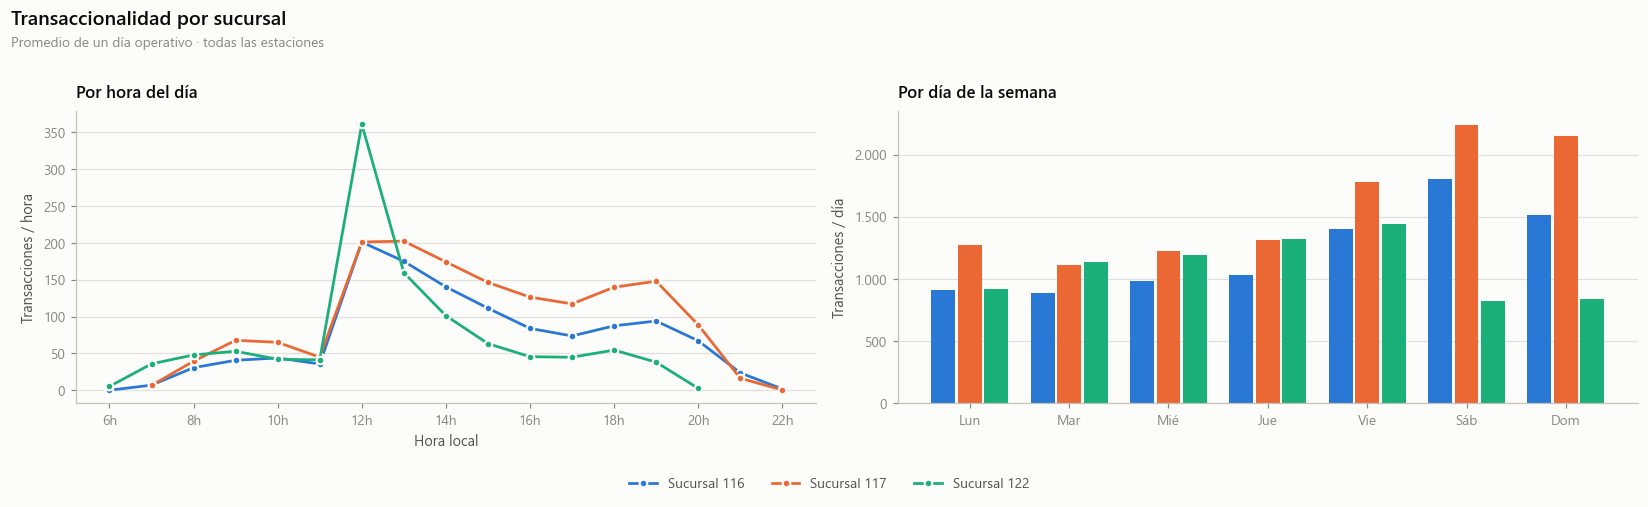

sucursal,116,117,122
hora,,,
6,0.1,nan,5.3
7,7.0,6.6,35.9
8,30.7,39.5,48.0
9,40.7,67.8,53.0
10,43.9,65.1,42.1
11,35.7,45.0,41.4
12,201.2,201.3,361.2
13,175.1,202.4,159.6
14,140.4,174.3,101.2


sucursal,116,117,122
dia_nombre,,,
Lunes,912,"1,274",923
Martes,884,"1,110","1,134"
Miércoles,983,"1,226","1,191"
Jueves,"1,030","1,312","1,320"
Viernes,"1,401","1,782","1,441"
Sábado,"1,801","2,239",826
Domingo,"1,513","2,151",836


In [33]:
ph = promedio_hora()
HORAS_EJE = sorted(panel["hora"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
for suc in SUCURSALES:
    s = ph[ph["sucursal"] == suc].sort_values("hora")
    ax1.plot(s["hora"], s["promedio"], color=COLOR_SUC[suc], label=f"Sucursal {suc}",
             marker="o", markeredgecolor=SUPERFICIE, markeredgewidth=1.4)
marco(ax1, "Por hora del día", xlabel="Hora local", ylabel="Transacciones / hora")
ax1.set_xticks(HORAS_EJE[::2])
ax1.set_xticklabels([f"{h}h" for h in HORAS_EJE[::2]])

pdw = promedio_dia()
x = np.arange(7)
ancho = 0.8 / len(SUCURSALES)
for i, suc in enumerate(SUCURSALES):
    s = pdw[pdw["sucursal"] == suc].set_index("dia_nombre").reindex(DIAS_ES)
    ax2.bar(x + (i - (len(SUCURSALES) - 1) / 2) * ancho, s["promedio"],
            width=ancho * 0.9, color=COLOR_SUC[suc], label=f"Sucursal {suc}")
marco(ax2, "Por día de la semana", ylabel="Transacciones / día")
ax2.set_xticks(x)
ax2.set_xticklabels(DIAS_CORTO)

top = titulo_figura(fig, "Transaccionalidad por sucursal",
                    "Promedio de un día operativo · todas las estaciones")
bot = leyenda_figura(fig, ax1, ncol=3)
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "08_sucursal_hora_dia")
plt.show()

display(ph.pivot(index="hora", columns="sucursal", values="promedio").style.format("{:,.1f}"))
display(pdw.pivot(index="dia_nombre", columns="sucursal", values="promedio").style.format("{:,.0f}"))

**Lo que se ve.** Las tres tienen el pico de almuerzo, pero el perfil semanal las separa: 116 y
117 crecen hacia el fin de semana (sábado +76 % y +72 % sobre el promedio de entre semana),
mientras la 122 **cae** el fin de semana (-33 %). Atrio es una torre de oficinas; las otras dos
están en centro comercial. Es la misma división que va a reaparecer en los festivos (sección 11).

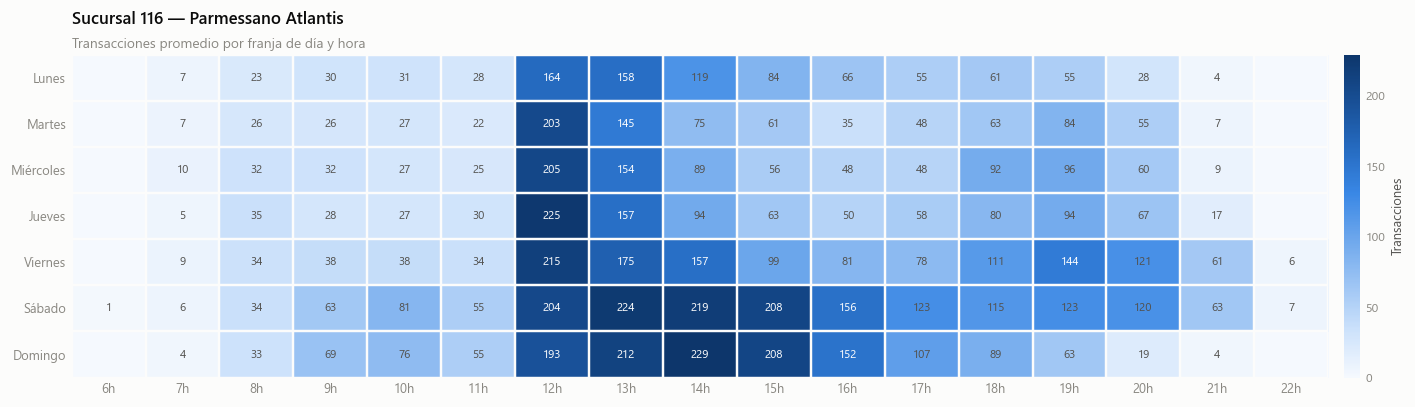

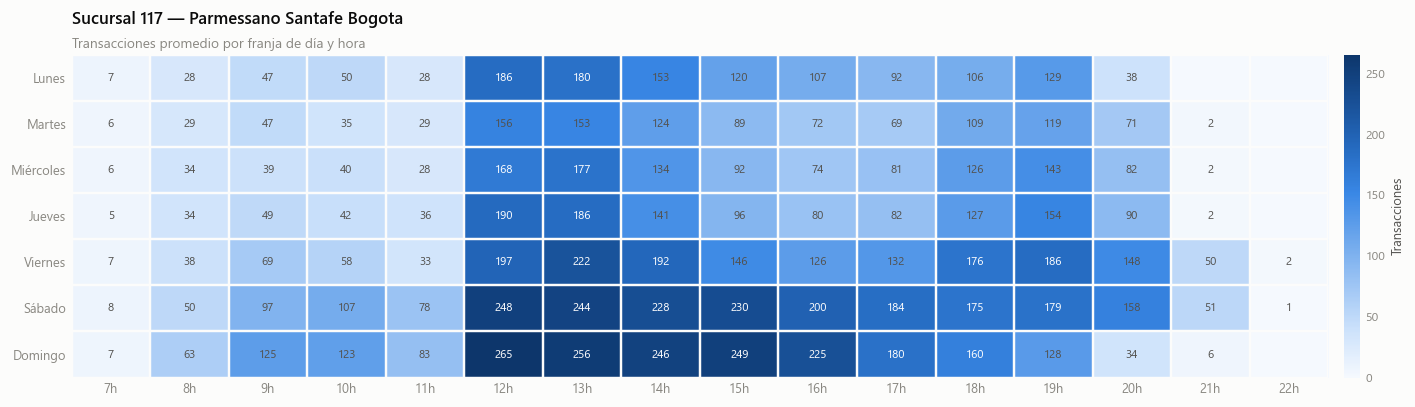

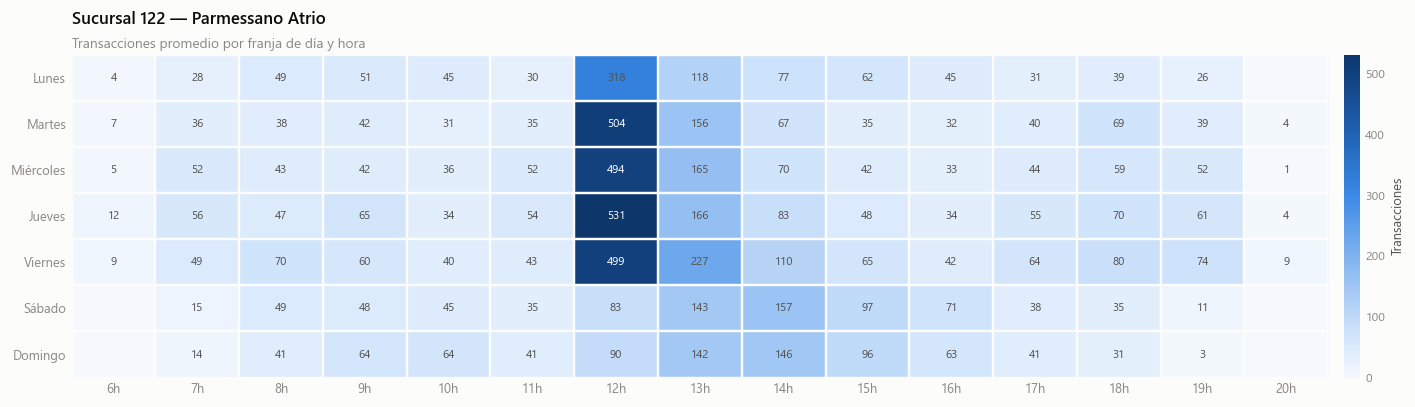

In [34]:
for suc in SUCURSALES:
    b = panel[panel["sucursal"] == suc]
    t = b.groupby(["dia_semana", "hora"], observed=True)["transacciones"].sum().reset_index()
    d = dias_suc_dow[dias_suc_dow["sucursal"] == suc].set_index("dia_semana")["dias"]
    t["promedio"] = t["transacciones"] / t["dia_semana"].map(d)
    m = t.pivot(index="dia_semana", columns="hora", values="promedio").fillna(0)
    m.index = [DIAS_ES[i] for i in m.index]
    m.columns = [f"{h}h" for h in m.columns]

    fig, ax = plt.subplots(figsize=(13, 3.8))
    mapa_calor(ax, m, f"Sucursal {suc} — {ID_A_NOMBRE.get(suc, '')}",
               "Transacciones promedio por franja de día y hora")
    fig.tight_layout()
    guardar(fig, f"08_heatmap_suc{suc}")
    plt.show()

### Resumen — por sucursal

Santafé mueve 1.586 transacciones por día, Atlantis 1.218 y Atrio 1.097. El volumen es lo de
menos: lo que las separa es la forma de la semana.

| | 116 Atlantis | 117 Santafé | 122 Atrio |
|---|---|---|---|
| Domingo vs. entre semana | +49 % | +67 % | -33 % |

Las tres comparten el pico de almuerzo. De ahí en adelante se separan:

- **116 y 117** crecen hacia el fin de semana y tienen un segundo repunte de cena. Son de centro
  comercial y el flujo lo trae el sábado y el domingo.
- **122 Atrio** cae un tercio el fin de semana y cierra más temprano, 20h contra 21-22h. Es una
  torre de oficinas y vive del almuerzo de semana.

Es una diferencia de forma, no de escala. No se corrige con un factor.

## 9. Análisis por área de servicio

Mismo dato, repartido entre las áreas del maestro. Suma exactamente el total de la sección 8.

In [35]:
res_area = panel.groupby(["sucursal", "area"], observed=True)["transacciones"].sum().reset_index()
res_area["tx_por_dia"] = res_area["transacciones"] / res_area["sucursal"].map(dias_suc)
res_area["participacion"] = (res_area["transacciones"] /
                             res_area.groupby("sucursal")["transacciones"].transform("sum") * 100)

display(res_area.pivot(index="area", columns="sucursal", values="tx_por_dia")
        .reindex(ORDEN_AREAS).style.format("{:,.0f}", na_rep="—")
        .set_caption("Transacciones por día operativo, por área"))
display(res_area.pivot(index="area", columns="sucursal", values="participacion")
        .reindex(ORDEN_AREAS).style.format("{:,.1f} %", na_rep="—")
        .set_caption("Participación dentro de cada sucursal"))

sucursal,116,117,122
area,,,
Bar,211,280,152
Cocina 1,543,676,503
Cocina 2,127,154,107
Salon,0,0,0
Todo Fresa,317,452,319
SIN AREA,20,24,14


sucursal,116,117,122
area,,,
Bar,17.3 %,17.6 %,13.9 %
Cocina 1,44.5 %,42.6 %,45.9 %
Cocina 2,10.4 %,9.7 %,9.8 %
Salon,0.0 %,0.0 %,0.0 %
Todo Fresa,26.0 %,28.5 %,29.1 %
SIN AREA,1.7 %,1.5 %,1.3 %


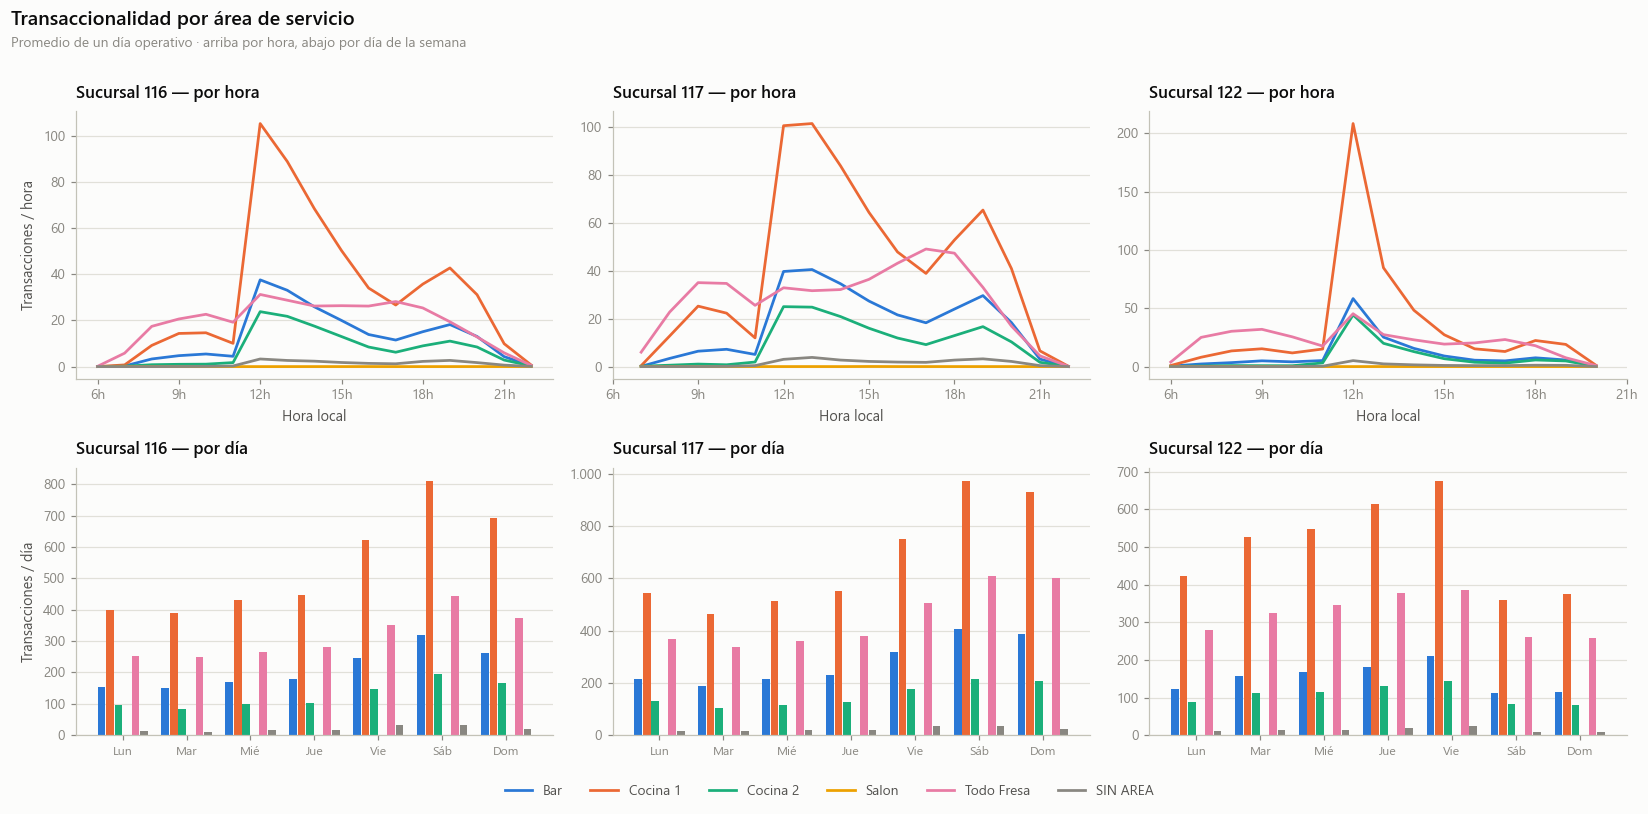

In [36]:
ph_area = promedio_hora(corte=("area",))
pdw_area = promedio_dia(corte=("area",))

fig, axes = plt.subplots(2, len(SUCURSALES), figsize=(15, 7.4))
for j, suc in enumerate(SUCURSALES):
    s = ph_area[ph_area["sucursal"] == suc]
    ax = axes[0, j]
    for area in ORDEN_AREAS:
        a = s[s["area"] == area].sort_values("hora")
        if a.empty:
            continue
        ax.plot(a["hora"], a["promedio"], color=COLOR_AREA[area], label=area)
    marco(ax, f"Sucursal {suc} — por hora", xlabel="Hora local",
          ylabel="Transacciones / hora" if j == 0 else None)
    ax.set_xticks(HORAS_EJE[::3])
    ax.set_xticklabels([f"{h}h" for h in HORAS_EJE[::3]])

    s2 = pdw_area[pdw_area["sucursal"] == suc]
    ax = axes[1, j]
    presentes = [a for a in ORDEN_AREAS if not s2[s2["area"] == a].empty]
    anc = 0.8 / max(len(presentes), 1)
    for i, area in enumerate(presentes):
        a = s2[s2["area"] == area].set_index("dia_nombre").reindex(DIAS_ES)
        ax.bar(np.arange(7) + (i - (len(presentes) - 1) / 2) * anc, a["promedio"],
               width=anc * 0.9, color=COLOR_AREA[area], label=area)
    marco(ax, f"Sucursal {suc} — por día",
          ylabel="Transacciones / día" if j == 0 else None)
    ax.set_xticks(np.arange(7))
    ax.set_xticklabels(DIAS_CORTO, fontsize=8)

top = titulo_figura(fig, "Transaccionalidad por área de servicio",
                    "Promedio de un día operativo · arriba por hora, abajo por día de la semana")
bot = leyenda_figura(fig, axes[0, 0], ncol=len(ORDEN_AREAS))
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "09_area_hora_dia")
plt.show()

### Resumen — por área de servicio

El reparto es estable entre sucursales, a diferencia del perfil semanal:

| Área | 116 | 117 | 122 |
|---|---|---|---|
| Cocina 1 | 44,5 % | 42,6 % | 45,9 % |
| Todo Fresa | 26,0 % | 28,5 % | 29,1 % |
| Bar | 17,3 % | 17,6 % | 13,9 % |
| Cocina 2 | 10,4 % | 9,7 % | 9,8 % |
| SIN AREA | 1,7 % | 1,5 % | 1,3 % |
| Salón | ~0 % | ~0 % | ~0 % |

**Cocina 1 concentra más del 42 % de la carga en las tres.** Es el cuello de botella del
negocio. Todo Fresa es la segunda y tiene un perfil más plano: empieza temprano y no depende
tanto del pico de almuerzo, así que es más fácil de programar.

Dos cosas vienen del maestro. `SIN AREA` es `Licores`, que vende pero no tiene área asignada. Y
**`Salón` aparece en cero**: su única estación con ventas es `Caja / Toma Pedidos`, que casi no
registra movimiento. No es que ahí no se trabaje, es que su trabajo no pasa por el sistema de
ventas. **Este modelo no puede dimensionar el salón.**

## 10. Análisis por estación de trabajo

El nivel al que trabaja el modelo. Hay más estaciones que colores categóricos distinguibles con
seguridad, así que aquí el color no codifica la estación: se usan paneles individuales y mapas
de calor sobre la rampa secuencial.

In [37]:
res_est = panel.groupby(["sucursal", "area", "estacion"], observed=True)["transacciones"].sum().reset_index()
res_est["tx_por_dia"] = res_est["transacciones"] / res_est["sucursal"].map(dias_suc)

tabla_est = res_est.pivot_table(index=["area", "estacion"], columns="sucursal",
                                values="tx_por_dia", observed=True).fillna(0)
tabla_est["TOTAL / día"] = tabla_est.sum(axis=1)
display(tabla_est.sort_values("TOTAL / día", ascending=False).style.format("{:,.1f}")
        .set_caption("Transacciones por día operativo, por estación"))

_declaradas = set(est_suc["estacion"])
_con_ventas = set(panel["estacion"])
print(f"El maestro declara {len(_declaradas)} estaciones; {len(_con_ventas & _declaradas)} registran ventas.")
print(f"Declaradas sin ninguna venta: {sorted(_declaradas - _con_ventas)}")

El maestro declara 19 estaciones; 9 registran ventas.
Declaradas sin ninguna venta: ['Caja', 'Fila ( Hostes )', 'Pasa Cuentas', 'Risottos', 'Servicio ( Zonas )', 'Stewart', 'Stoker', 'pase de cominas', 'patinador de Comidas', 'patinador de bebidas']


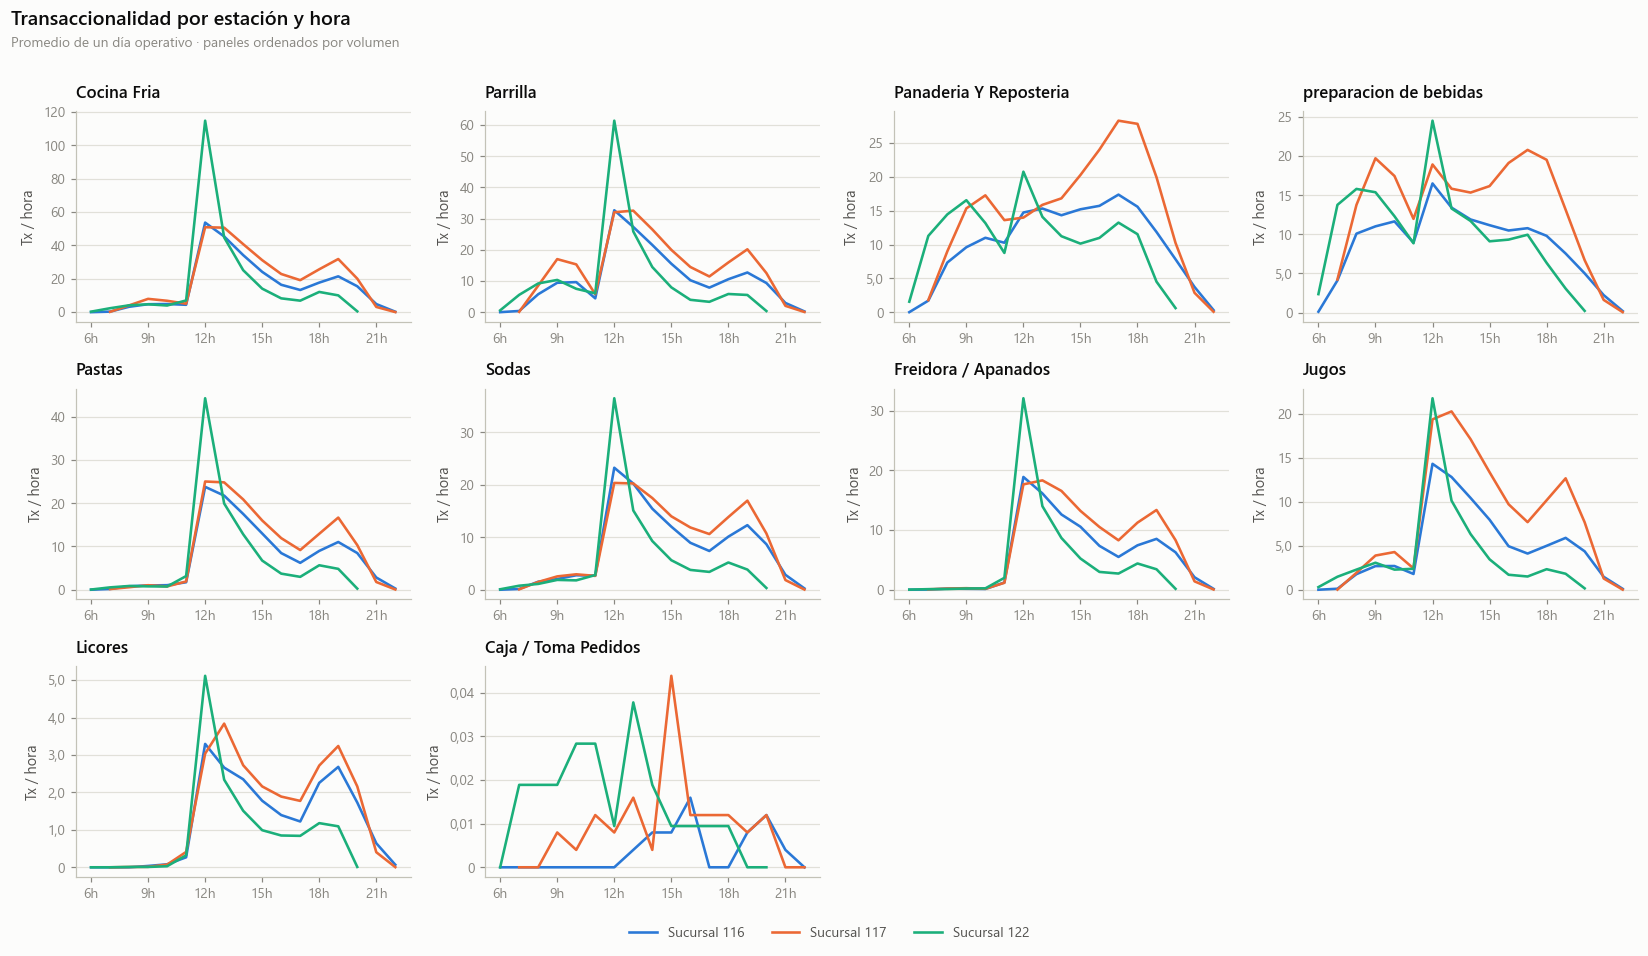

In [38]:
ph_est = promedio_hora(corte=("estacion",))
orden_est = (ph_est.groupby("estacion", observed=True)["transacciones"].sum()
             .sort_values(ascending=False).index.tolist())

ncols = 4
nrows = int(np.ceil(len(orden_est) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.9 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, est in zip(axes, orden_est):
    s = ph_est[ph_est["estacion"] == est]
    for suc in SUCURSALES:
        a = s[s["sucursal"] == suc].sort_values("hora")
        if a.empty:
            continue
        ax.plot(a["hora"], a["promedio"], color=COLOR_SUC[suc], label=f"Sucursal {suc}", lw=1.7)
    marco(ax, est, ylabel="Tx / hora")
    ax.set_xticks(HORAS_EJE[::3])
    ax.set_xticklabels([f"{h}h" for h in HORAS_EJE[::3]])
for ax in axes[len(orden_est):]:
    ax.remove()

top = titulo_figura(fig, "Transaccionalidad por estación y hora",
                    "Promedio de un día operativo · paneles ordenados por volumen")
bot = leyenda_figura(fig, axes[0], ncol=3)
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "10_estacion_por_hora")
plt.show()

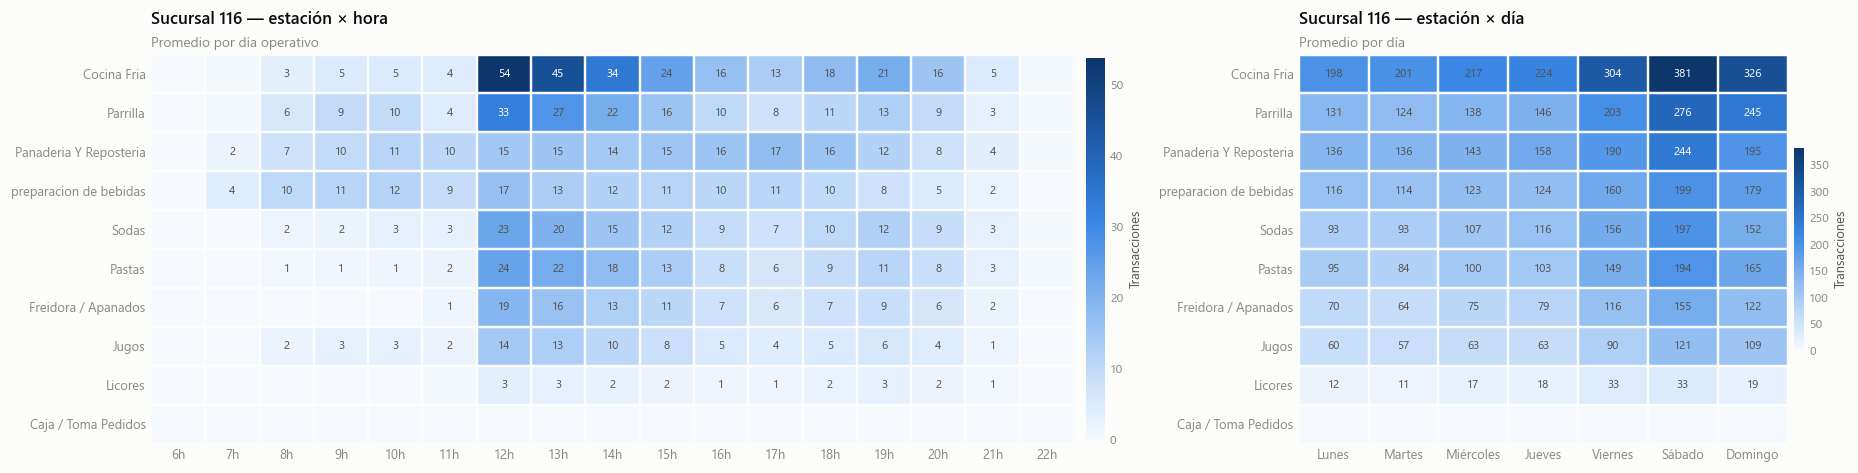

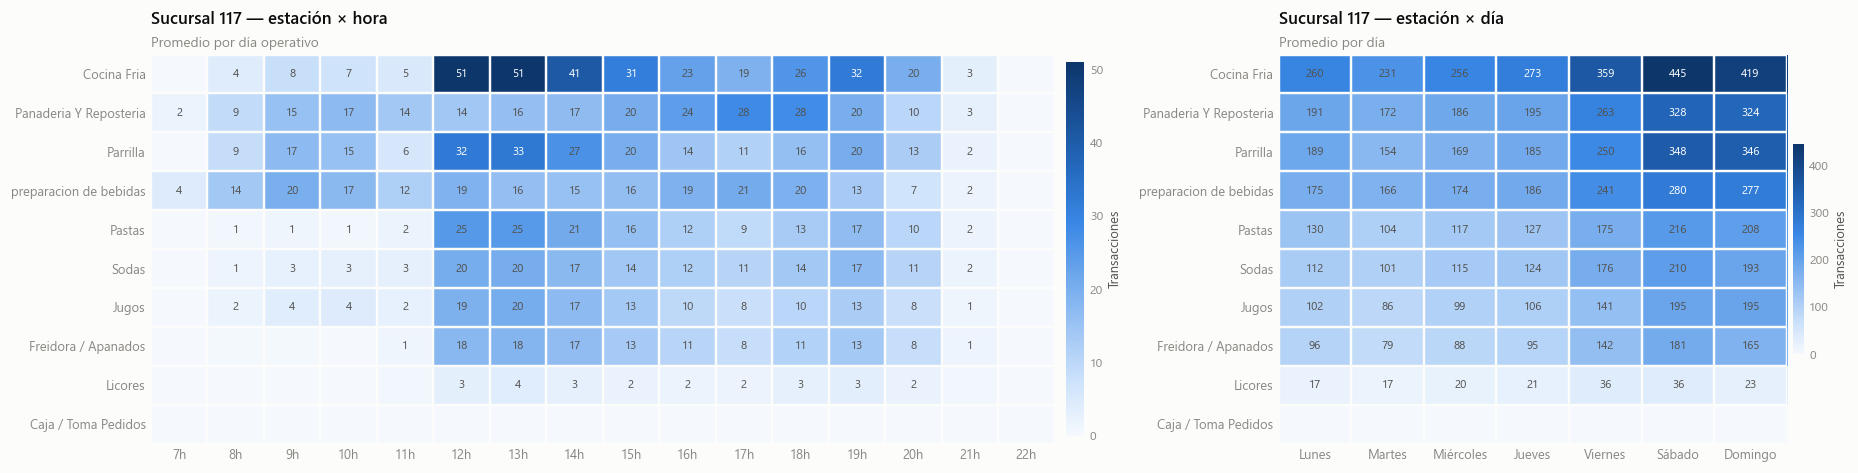

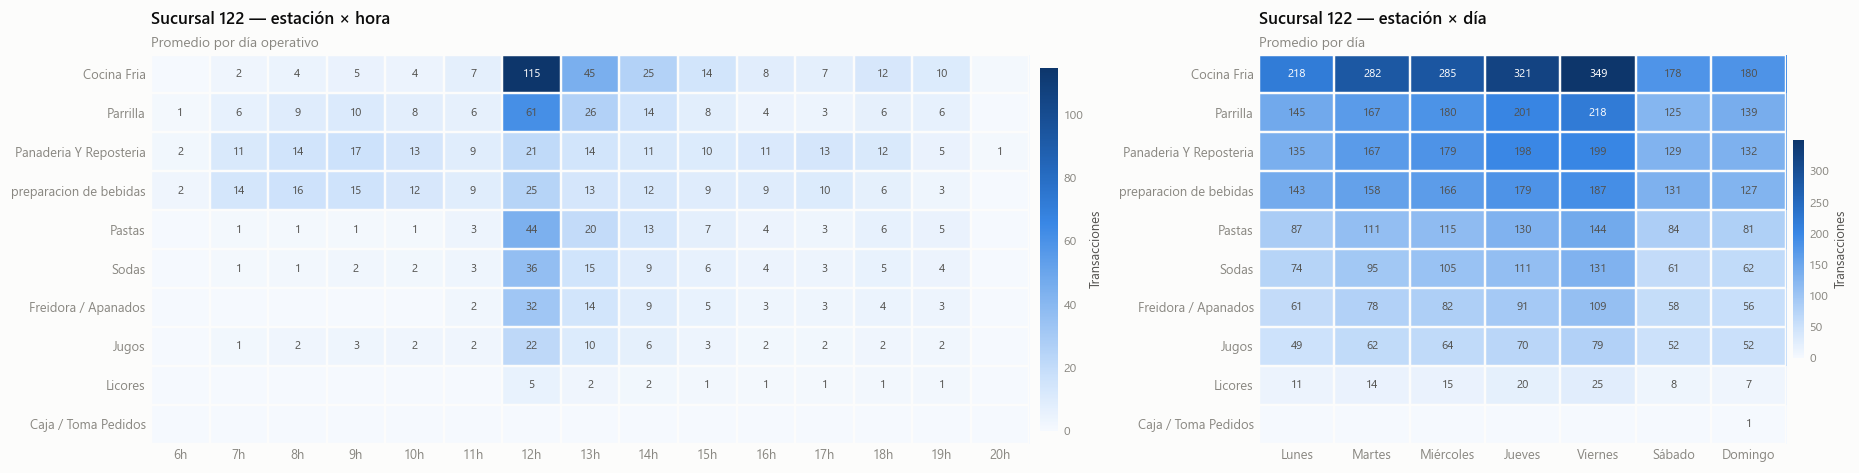

In [39]:
for suc in SUCURSALES:
    b = panel[panel["sucursal"] == suc]
    t = b.groupby(["estacion", "dia_semana"], observed=True)["transacciones"].sum().reset_index()
    d = dias_suc_dow[dias_suc_dow["sucursal"] == suc].set_index("dia_semana")["dias"]
    t["promedio"] = t["transacciones"] / t["dia_semana"].map(d)
    m = t.pivot(index="estacion", columns="dia_semana", values="promedio").fillna(0)
    m.columns = [DIAS_ES[i] for i in m.columns]
    m = m.loc[m.sum(axis=1).sort_values(ascending=False).index]

    t2 = b.groupby(["estacion", "hora"], observed=True)["transacciones"].sum().reset_index()
    m2 = (t2.pivot(index="estacion", columns="hora", values="transacciones").fillna(0)
          / dias_suc[suc])
    m2 = m2.loc[m.index]
    m2.columns = [f"{h}h" for h in m2.columns]

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 4.4),
                                 gridspec_kw={"width_ratios": [len(m2.columns), 9]})
    mapa_calor(a1, m2, f"Sucursal {suc} — estación × hora", "Promedio por día operativo")
    mapa_calor(a2, m, f"Sucursal {suc} — estación × día", "Promedio por día")
    fig.tight_layout()
    guardar(fig, f"10_heatmap_estacion_suc{suc}")
    plt.show()

### Resumen — por estación de trabajo

El ranking es el mismo en las tres, lo que sugiere que la preparación está estandarizada
(transacciones por día):

| Estación | 116 | 117 | 122 |
|---|---|---|---|
| Cocina Fría | 265 | 320 | 259 |
| Parrilla | 181 | 234 | 168 |
| Panadería y Repostería | 172 | 237 | 163 |
| Preparación de bebidas | 145 | 214 | 156 |
| Sodas | 131 | 148 | 91 |
| Pastas | 127 | 154 | 107 |
| Freidora / Apanados | 97 | 121 | 76 |
| Jugos | 81 | 132 | 61 |
| Licores | 20 | 24 | 14 |
| Caja / Toma Pedidos | ~0 | ~0 | ~0 |

Los mapas de calor muestran dos perfiles distintos, y por eso vale la pena proyectar por
estación y no solo por sucursal:

- **Cocina Fría, Parrilla, Pastas y Freidora** se saturan en la franja del almuerzo y bajan
  rápido. Necesitan refuerzo concentrado en dos horas.
- **Panadería y preparación de bebidas** arrancan antes y se mantienen altas buena parte del
  día. Necesitan cobertura sostenida.

`Caja / Toma Pedidos` registra casi cero: o no se captura su actividad, o el mapeo no le asigna
ítems. Y de las 19 estaciones del maestro, solo 10 tienen ventas.

## 11. El efecto de los festivos

Antes de meter una variable al modelo hay que comprobar que la señal existe. Esta sección es la
justificación empírica de las variables de la sección 6.1 — y, de paso, el argumento más fuerte a favor
de entrenar un modelo por sucursal.

In [40]:
dia = panel.groupby(["sucursal", "fecha"], as_index=False)["transacciones"].sum()
dia["dia_semana"] = dia["fecha"].dt.dayofweek
dia["es_festivo"] = dia["fecha"].isin(FESTIVOS)
dia["dia_nombre"] = pd.Categorical(
    dia["dia_semana"].map(dict(enumerate(DIAS_ES))), categories=DIAS_ES, ordered=True)

filas = []
for suc in SUCURSALES:
    g = dia[dia["sucursal"] == suc]
    base = g[(~g["es_festivo"]) & (g["dia_semana"] < 5)]["transacciones"].mean()
    fest = g[g["es_festivo"]]
    dom = g[(~g["es_festivo"]) & (g["dia_semana"] == 6)]["transacciones"].mean()
    filas.append({
        "sucursal": suc, "nombre": ID_A_NOMBRE.get(suc, ""),
        "entre semana normal": base,
        "domingo normal": dom, "domingo vs base": dom / base - 1,
        "n festivos": len(fest), "festivo": fest["transacciones"].mean(),
        "festivo vs base": fest["transacciones"].mean() / base - 1,
    })
efecto = pd.DataFrame(filas)
display(efecto.style.format({
    "entre semana normal": "{:,.0f}", "domingo normal": "{:,.0f}", "festivo": "{:,.0f}",
    "domingo vs base": "{:+.0%}", "festivo vs base": "{:+.0%}"}).hide(axis="index"))

sucursal,nombre,entre semana normal,domingo normal,domingo vs base,n festivos,festivo,festivo vs base
116,Parmessano Atlantis,"1,013","1,513",+49%,12,"1,448",+43%
117,Parmessano Santafe Bogota,"1,291","2,151",+67%,12,"2,032",+57%
122,Parmessano Atrio,"1,243",836,-33%,6,726,-42%


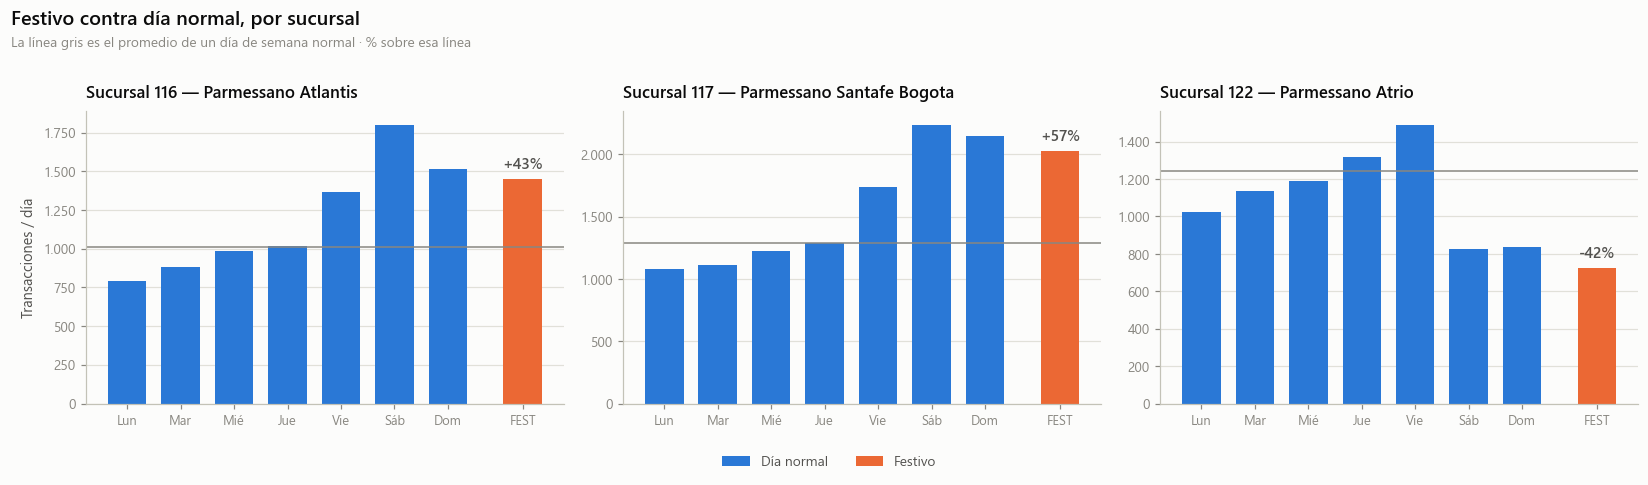

In [41]:
fig, axes = plt.subplots(1, len(SUCURSALES), figsize=(15, 4.4), sharey=False)
axes = np.atleast_1d(axes)
for ax, suc in zip(axes, SUCURSALES):
    g = dia[dia["sucursal"] == suc]
    base = g[(~g["es_festivo"]) & (g["dia_semana"] < 5)]["transacciones"].mean()
    normal = g[~g["es_festivo"]].groupby("dia_nombre", observed=True)["transacciones"].mean().reindex(DIAS_ES)
    fest = g[g["es_festivo"]]["transacciones"].mean()

    ax.bar(np.arange(7), normal.values, width=0.72, color=SERIES[0], label="Día normal")
    ax.bar([7.4], [fest], width=0.72, color=SERIES[1], label="Festivo")
    ax.axhline(base, color=TINTA_MUTE, lw=1.0)
    ax.annotate(f"{fest/base-1:+.0%}", xy=(7.4, fest), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=10, fontweight="semibold", color=TINTA_2)
    marco(ax, f"Sucursal {suc} — {ID_A_NOMBRE.get(suc,'')}",
          ylabel="Transacciones / día" if suc == SUCURSALES[0] else None)
    ax.set_xticks(list(np.arange(7)) + [7.4])
    ax.set_xticklabels(DIAS_CORTO + ["FEST"], fontsize=8.5)

top = titulo_figura(fig, "Festivo contra día normal, por sucursal",
                    "La línea gris es el promedio de un día de semana normal · % sobre esa línea")
bot = leyenda_figura(fig, axes[0], ncol=2)
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "11_efecto_festivo")
plt.show()

**El hallazgo.** El efecto del festivo tiene **signo opuesto** entre sucursales: sube fuerte en
Atlantis y Santafé, que están en centro comercial y el festivo les trae flujo, y cae 40 % en
Atrio, que vive de oficinas y el festivo se las vacía.

En las tres, además, el festivo se parece bastante a su propio domingo. Eso es lo que valida
`dia_semana_efectivo`: tratar el festivo como domingo le da al modelo un punto de partida
razonable, y `es_festivo` se encarga del residuo.

Un modelo único sobre las tres sucursales promediaría +44 % con -40 % y aprendería que el
festivo no importa. Por eso van modelos separados.

In [42]:
# Efecto por estación: ¿el festivo golpea parejo o hay estaciones más sensibles?
est_f = panel.copy()
est_f["es_festivo"] = est_f["fecha"].isin(FESTIVOS)
por_est = (est_f.groupby(["sucursal", "estacion", "es_festivo", "fecha"], observed=True)["transacciones"]
           .sum().groupby(level=[0, 1, 2]).mean().unstack())
por_est.columns = ["día normal", "festivo"]
por_est["efecto"] = por_est["festivo"] / por_est["día normal"] - 1
por_est = por_est[por_est["día normal"] > 1]

for suc in SUCURSALES:
    sub = por_est.loc[suc].sort_values("efecto", ascending=False)
    print(f"--- Sucursal {suc} — efecto del festivo por estación ---")
    display(sub.style.format({"día normal": "{:,.1f}", "festivo": "{:,.1f}", "efecto": "{:+.0%}"}))

--- Sucursal 116 — efecto del festivo por estación ---


,día normal,festivo,efecto
estacion,,,
Pastas,124.2,187.4,+51%
Parrilla,178.1,231.8,+30%
Freidora / Apanados,96.1,121.8,+27%
Licores,20.3,24.6,+21%
Jugos,79.8,95.8,+20%
Cocina Fria,262.1,312.6,+19%
Sodas,129.8,144.2,+11%
preparacion de bebidas,144.1,159.8,+11%
Panaderia Y Reposteria,172.1,170.3,-1%


--- Sucursal 117 — efecto del festivo por estación ---


,día normal,festivo,efecto
estacion,,,
Pastas,149.6,244.2,+63%
Parrilla,229.3,338.4,+48%
Freidora / Apanados,118.8,161.0,+35%
Cocina Fria,316.2,404.5,+28%
Jugos,130.5,162.0,+24%
Sodas,146.3,173.2,+18%
Panaderia Y Reposteria,235.5,274.0,+16%
preparacion de bebidas,212.7,247.2,+16%
Licores,24.3,27.0,+11%


--- Sucursal 122 — efecto del festivo por estación ---


,día normal,festivo,efecto
estacion,,,
preparacion de bebidas,158.1,121.3,-23%
Jugos,61.9,47.2,-24%
Panaderia Y Reposteria,165.3,124.2,-25%
Licores,14.5,10.7,-26%
Parrilla,170.8,120.5,-29%
Freidora / Apanados,78.2,47.0,-40%
Cocina Fria,265.9,146.0,-45%
Pastas,110.3,59.2,-46%
Sodas,93.9,49.0,-48%


In [43]:
# Víspera y día posterior
vp = dia.copy()
vp["vispera"] = (vp["fecha"] + pd.Timedelta(days=1)).isin(FESTIVOS)
vp["post"] = (vp["fecha"] - pd.Timedelta(days=1)).isin(FESTIVOS)
vp["tipo"] = np.select(
    [vp["es_festivo"], vp["vispera"], vp["post"]],
    ["Festivo", "Víspera", "Día después"], default="Día normal")

tabla_vp = (vp.groupby(["sucursal", "tipo"])["transacciones"]
            .agg(dias="size", promedio="mean").reset_index())
base_suc = vp[vp["tipo"] == "Día normal"].groupby("sucursal")["transacciones"].mean()
tabla_vp["vs día normal"] = tabla_vp["promedio"] / tabla_vp["sucursal"].map(base_suc) - 1
display(tabla_vp.pivot(index="tipo", columns="sucursal", values="vs día normal")
        .reindex(["Víspera", "Festivo", "Día después", "Día normal"])
        .style.format("{:+.1%}").set_caption("Efecto de víspera, festivo y día posterior"))

sucursal,116,117,122
tipo,,,
Víspera,+30.1%,+44.3%,-16.6%
Festivo,+21.3%,+31.9%,-36.1%
Día después,-6.0%,-11.1%,-7.8%
Día normal,+0.0%,+0.0%,+0.0%


### Resumen — el efecto de los festivos

El festivo no afecta igual a las tres sucursales. Les afecta en sentidos opuestos.

| Sucursal | Festivo vs. día de semana normal |
|---|---|
| 116 Atlantis (centro comercial) | +43 % |
| 117 Santafé (centro comercial) | +57 % |
| 122 Atrio (torre corporativa) | -42 % |

En las tres, el festivo se parece a su propio domingo. En las de centro comercial eso significa
subir; en Atrio, caer. Es lo que codifica `dia_semana_efectivo`.

El efecto se transmite a todas las estaciones por igual. Es tráfico del local, no un cambio en
lo que se pide.

Un modelo único sobre las tres tendría que aprender que el festivo sube 57 % y baja 42 % al
mismo tiempo. Aprendería que no importa. Por eso van modelos separados.

## 12. Modelo por sucursal

Un modelo independiente por sucursal, sobre su propia grilla de `fecha x hora x estación`. La
variable objetivo es `transacciones`.

### Dos etapas

| Etapa | Qué predice | Con qué |
|---|---|---|
| **1. Nivel** | Cuántas transacciones tiene el día completo | Serie de tiempo sobre la serie diaria de la sucursal |
| **2. Forma** | Cómo se reparte ese día entre horas y estaciones | Regresión con variables de calendario |

La forma es estable: el pico de almuerzo de Parrilla es el mismo en enero y en septiembre. El
nivel se mueve, y Atlantis pasó de 800 transacciones diarias en enero a unas 1.150 de julio en
adelante.

Separarlas importa porque una regresión con árboles no extrapola. Si le pides octubre, `mes =
10` es un valor que nunca vio: cae en la última división del árbol y responde como si fuera
septiembre. Una serie de tiempo sí extrapola.

La predicción de cada día se reescala para que sume el nivel que predijo la etapa 1.

### Lo que no entra

- **Rezagos.** Mejorarían el pronóstico de mañana, pero no existen a siete días vista: habría
  que alimentarlos con las propias predicciones y el error se acumula.
- **Series de tiempo por estación.** Serían 30 series. Con 106 días en Atrio, un SARIMAX por
  estación no tiene con qué ajustarse.

### 12.1 Partición en tres bloques

Cortada por **fechas completas**: si medio día quedara en un bloque y medio en otro, el modelo
vería el futuro de ese día.

| Bloque | Fechas | Para qué |
|---|---|---|
| **Ajuste** | 60 % | Entrenar. La búsqueda de hiperparámetros corre aquí dentro, con su propia validación temporal |
| **Validación** | 20 % | Elegir: qué modelo de nivel y qué configuración gana |
| **Prueba** | 20 % final | Reportar. No participa en ninguna decisión y se toca una sola vez |

Tres bloques y no dos porque **elegir y reportar con el mismo conjunto infla las cifras**: uno
se queda con el candidato que mejor le fue ahí y después presenta ese resultado como si fuera
una medición independiente. Con tres bloques, el número que se reporta es honesto.

In [44]:
FRACCION_VALIDACION = 0.20
FRACCION_PRUEBA = 0.20


def particion_tres_bloques(frame, f_val=FRACCION_VALIDACION, f_pru=FRACCION_PRUEBA):
    '''Corta por fechas completas en ajuste / validación / prueba.'''
    fechas = np.array(sorted(frame["fecha"].unique()))
    n_pru = max(1, int(round(len(fechas) * f_pru)))
    n_val = max(1, int(round(len(fechas) * f_val)))
    corte_val = pd.Timestamp(fechas[-(n_pru + n_val)])
    corte_pru = pd.Timestamp(fechas[-n_pru])

    ajuste = frame[frame["fecha"] < corte_val].copy()
    validacion = frame[(frame["fecha"] >= corte_val) & (frame["fecha"] < corte_pru)].copy()
    prueba = frame[frame["fecha"] >= corte_pru].copy()
    return ajuste, validacion, prueba, corte_val, corte_pru


PARTICIONES = {}
filas = []
for suc, d in datos.items():
    aj, va, pr, c_val, c_pru = particion_tres_bloques(d.frame)
    PARTICIONES[suc] = (aj, va, pr, c_val, c_pru)
    filas.append({
        "sucursal": suc,
        "ajuste (días)": aj["fecha"].nunique(), "ajuste (filas)": len(aj),
        "validación (días)": va["fecha"].nunique(), "validación (filas)": len(va),
        "prueba (días)": pr["fecha"].nunique(), "prueba (filas)": len(pr),
        "corte validación": c_val.date(), "corte prueba": c_pru.date(),
    })
display(pd.DataFrame(filas).style.format({
    "ajuste (filas)": "{:,.0f}", "validación (filas)": "{:,.0f}", "prueba (filas)": "{:,.0f}",
}).hide(axis="index"))

sucursal,ajuste (días),ajuste (filas),validación (días),validación (filas),prueba (días),prueba (filas),corte validación,corte prueba
116,151,"23,310",50,"7,710",50,"7,710",2026-06-02,2026-07-22
117,151,"23,090",50,"7,640",50,"7,640",2026-06-02,2026-07-22
122,64,"9,240",21,"3,030",21,"3,030",2026-07-30,2026-08-20


### 12.2 Variables de la etapa 2 y métricas

Las variables del modelo de forma son las de calendario y festivos que construyó la sección 6,
más la estación y el área como categóricas. `columnas()` incluye también `fecha`: el
`ColumnTransformer` la descarta, pero la validación cruzada temporal de la sección 12.4 la
necesita para cortar por fechas completas.

**Lo que se dejó fuera a propósito.** `dia_del_anio` y `semana_del_anio`. Con 8 meses de
historial son casi identificadores únicos de fecha: un modelo de árboles las usa para memorizar
días concretos, y al proyectar caen fuera del rango visto, donde un árbol no extrapola. La
estacionalidad anual la llevan `mes`, `mes_sin` y `mes_cos`.

En cuanto a métricas, en regresión no hay un "accuracy" como en clasificación, así que se
reportan varias lecturas. La que se usa para **elegir** es el MAE: está en las unidades del
problema (transacciones) y no castiga desproporcionadamente los picos, que es lo que haría el
RMSE.

In [45]:
FEATURES_CALENDARIO = [
    "hora", "dia_semana", "dia_mes", "mes", "trimestre",
    "es_fin_semana", "es_inicio_mes", "es_fin_mes",
    "hora_sin", "hora_cos", "dia_semana_sin", "dia_semana_cos", "mes_sin", "mes_cos",
]
FEATURES_FESTIVO = [
    "es_festivo", "es_vispera_festivo", "es_post_festivo", "es_puente", "dia_semana_efectivo",
]
FEATURES_CAT = ["estacion", "area"]
TARGET = "transacciones"


def columnas(con_festivos=True):
    '''Columnas que se le pasan al pipeline. `fecha` viaja para que el divisor temporal
    de la sección 12.4 pueda cortar por fechas; el ColumnTransformer la descarta.'''
    return (FEATURES_CALENDARIO + (FEATURES_FESTIVO if con_festivos else [])
            + FEATURES_CAT + ["fecha"])


def construir_pipeline(estimador, con_festivos=True, log_objetivo=False):
    '''Escalado + one-hot + el estimador.

    `log_objetivo` entrena contra log1p del objetivo. Suena razonable —la variable es un
    conteo con cola derecha larga— pero la transformación inversa devuelve algo cercano a la
    mediana y el modelo termina subestimando el volumen. Se deja como opción para poder
    medirlo, no como decisión tomada: la sección 12.4 lo compara con y sin.

    Aun sin transformar, el objetivo pasa por `TransformedTargetRegressor` con funciones
    identidad, para que los nombres de los hiperparámetros sean iguales en los dos casos y
    la búsqueda pueda usar el mismo espacio.
    '''
    numericas = FEATURES_CALENDARIO + (FEATURES_FESTIVO if con_festivos else [])
    pre = ColumnTransformer([
        ("num", StandardScaler(), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURES_CAT),
    ], remainder="drop")
    objetivo = TransformedTargetRegressor(
        regressor=estimador,
        func=np.log1p if log_objetivo else None,
        inverse_func=np.expm1 if log_objetivo else None)
    return Pipeline([("features", pre), ("model", objetivo)])


def wmape(y, p):
    d = np.abs(y).sum()
    return float(np.abs(y - p).sum() / d) if d else np.nan


def smape(y, p):
    den = np.abs(y) + np.abs(p)
    m = den > 0
    return float(np.mean(2 * np.abs(y[m] - p[m]) / den[m])) if m.any() else np.nan


def evaluar(y, p):
    y = np.asarray(y, dtype=float)
    p = np.clip(np.asarray(p, dtype=float), 0, None)
    return {"mae": mean_absolute_error(y, p),
            "rmse": float(np.sqrt(mean_squared_error(y, p))),
            "wmape": wmape(y, p), "smape": smape(y, p),
            "r2": float(r2_score(y, p))}


class BaselineEstacional:
    '''Promedio histórico por estación, día de la semana efectivo y hora.

    Se implementa como estimador, con fit/predict, para que compita de igual a igual.
    Un baseline que no puede ser elegido no es una comparación honesta.
    '''

    def fit(self, X, y):
        dia = "dia_semana_efectivo" if "dia_semana_efectivo" in X.columns else "dia_semana"
        self.clave_ = ["estacion", dia, "hora"]
        d = X[self.clave_].copy()
        d["_y"] = np.asarray(y, dtype=float)
        self.tabla_ = (d.groupby(self.clave_, observed=True)["_y"].mean()
                       .rename("_pred").reset_index())
        self.global_ = float(d["_y"].mean())
        return self

    def predict(self, X):
        # El left merge conserva el orden de X, así que la salida alinea fila a fila
        out = X[self.clave_].merge(self.tabla_, on=self.clave_, how="left")
        return out["_pred"].fillna(self.global_).to_numpy()


print("Métricas listas.")
print("Baseline estacional listo.")

Métricas listas.
Baseline estacional listo.


### 12.3 Etapa 1 — el nivel diario (series de tiempo)

La serie es el total de transacciones por día de la sucursal. Cuatro candidatos, cada uno fuerte
en algo distinto:

| Candidato | Tendencia | Día de la semana | Festivos |
|---|---|---|---|
| `media_dow` — promedio por día de la semana de las últimas 8 semanas | Se adapta al nivel reciente | Sí | No |
| `media_dow_efectivo` — el mismo, tratando el festivo como domingo | Se adapta al nivel reciente | Sí | Sí |
| `regresion_tendencia` — Ridge sobre tendencia lineal, día y festivos | Sí, lineal | Sí | Sí |
| `holt_winters` — suavizado exponencial con estacionalidad semanal | Sí | Sí | No |
| `sarimax` — SARIMAX con estacionalidad semanal y festivos exógenos | Sí | Sí | Sí |

Los dos primeros son ingenuos estacionales con ventana móvil — el método más simple del
repertorio de series de tiempo. Están ahí porque en pronóstico los métodos simples ganan mucho
más a menudo de lo que uno espera, y conviene saberlo antes de creerle a un SARIMAX.

Todos exponen la misma interfaz `fit(serie)` / `predict(fechas)`, así que compiten en igualdad
de condiciones. Los dos de statsmodels pronostican hacia adelante paso a paso: para fechas
dentro del entrenamiento devuelven el ajuste, y para fechas futuras, el pronóstico.

**Se ajustan sobre el bloque de ajuste y se eligen con el de validación.** La prueba no se toca.

In [46]:
def serie_diaria(frame: pd.DataFrame) -> pd.DataFrame:
    '''Total de transacciones por día: la serie que ven los modelos de nivel.'''
    return (frame.groupby("fecha", as_index=False)["transacciones"].sum()
            .sort_values("fecha").reset_index(drop=True))


class NivelMediaDow:
    '''Promedio por día de la semana de las últimas semanas. El baseline del nivel.

    No sabe de tendencia ni de festivos, pero es competitivo cuando la serie está
    plana, y conviene saberlo antes de creerle a algo más complicado.
    '''
    nombre = "media_dow"

    def __init__(self, semanas=8):
        self.semanas = semanas

    def fit(self, serie):
        s = serie.tail(self.semanas * 7)
        self.tabla_ = s.groupby(pd.DatetimeIndex(s["fecha"]).dayofweek)["transacciones"].mean()
        self.global_ = float(s["transacciones"].mean())
        return self

    def predict(self, fechas):
        dow = pd.DatetimeIndex(fechas).dayofweek
        return np.array([self.tabla_.get(d, self.global_) for d in dow], dtype=float)


class NivelMediaDowEfectivo(NivelMediaDow):
    '''Igual que el anterior, pero usando el día EFECTIVO: el festivo cuenta como domingo.

    Existe por una razón concreta. Al reescalar, el total del día lo fija la etapa 1;
    si esa etapa no sabe de festivos, le borra a la etapa 2 el efecto que sí había
    aprendido. Este candidato le devuelve esa información al nivel sin renunciar a la
    simplicidad del promedio móvil.
    '''
    nombre = "media_dow_efectivo"

    @staticmethod
    def _dia_efectivo(fechas):
        f = pd.DatetimeIndex(fechas)
        return np.where(f.isin(FESTIVOS), 6, f.dayofweek)

    def fit(self, serie):
        s = serie.tail(self.semanas * 7)
        self.tabla_ = s.groupby(self._dia_efectivo(s["fecha"]))["transacciones"].mean()
        self.global_ = float(s["transacciones"].mean())
        return self

    def predict(self, fechas):
        return np.array([self.tabla_.get(d, self.global_)
                         for d in self._dia_efectivo(fechas)], dtype=float)


class NivelRegresionTendencia:
    '''Ridge sobre tendencia lineal + día de la semana + festivos.

    El más simple de los que extrapolan: la tendencia es una recta, así que proyecta
    crecimiento o caída más allá del último dato observado.
    '''
    nombre = "regresion_tendencia"

    def _diseno(self, fechas):
        f = pd.DatetimeIndex(fechas)
        X = pd.DataFrame({"tendencia": (f - self.origen_).days})
        for d in range(6):          # domingo queda como categoría de referencia
            X[f"dow_{d}"] = (f.dayofweek == d).astype(int)
        for col, valores in marcas_festivo(f).items():
            X[col] = valores.to_numpy()
        return X.to_numpy(dtype=float)

    def fit(self, serie):
        self.origen_ = pd.DatetimeIndex(serie["fecha"]).min()
        self.modelo_ = Ridge(alpha=1.0).fit(self._diseno(serie["fecha"]),
                                            serie["transacciones"].to_numpy(float))
        return self

    def predict(self, fechas):
        return np.clip(self.modelo_.predict(self._diseno(fechas)), 0, None)


class _NivelStatsmodels:
    '''Base para los modelos de statsmodels.

    Resuelve el ida y vuelta entre valores ajustados (fechas que el modelo vio al
    entrenar) y pronóstico (fechas posteriores), para que `predict` acepte cualquier
    lista de fechas igual que los demás candidatos.
    '''

    def _ajustar(self, serie):
        raise NotImplementedError

    def _pronosticar(self, pasos, fechas_futuras):
        raise NotImplementedError

    def fit(self, serie):
        self.fechas_ = pd.DatetimeIndex(serie["fecha"])
        self.ultima_ = self.fechas_.max()
        self.promedio_ = float(serie["transacciones"].mean())
        self._ajustar(serie)
        return self

    def predict(self, fechas):
        f = pd.DatetimeIndex(fechas)
        out = pd.Series(np.nan, index=np.arange(len(f)), dtype=float)

        dentro = f <= self.ultima_
        if dentro.any():
            out.iloc[np.flatnonzero(dentro)] = self.ajustado_.reindex(f[dentro]).to_numpy()
        if (~dentro).any():
            futuras = f[~dentro]
            pasos = int((futuras.max() - self.ultima_).days)
            idx = pd.date_range(self.ultima_ + pd.Timedelta(days=1), periods=pasos, freq="D")
            fc = pd.Series(self._pronosticar(pasos, idx), index=idx)
            out.iloc[np.flatnonzero(~dentro)] = fc.reindex(futuras).to_numpy()

        return np.clip(out.fillna(self.promedio_).to_numpy(), 0, None)


class NivelHoltWinters(_NivelStatsmodels):
    '''Suavizado exponencial con tendencia aditiva y estacionalidad semanal.'''
    nombre = "holt_winters"

    def _ajustar(self, serie):
        self.modelo_ = ExponentialSmoothing(
            serie["transacciones"].to_numpy(float),
            trend="add", seasonal="add", seasonal_periods=7,
            initialization_method="estimated").fit()
        self.ajustado_ = pd.Series(self.modelo_.fittedvalues, index=self.fechas_)

    def _pronosticar(self, pasos, fechas_futuras):
        return np.asarray(self.modelo_.forecast(pasos), dtype=float)


class NivelSarimax(_NivelStatsmodels):
    '''SARIMAX con estacionalidad semanal y los festivos como variables exógenas.

    La diferenciación (d=1) aporta la tendencia; el bloque estacional de periodo 7,
    el perfil semanal; y las exógenas, el efecto del festivo.
    '''
    nombre = "sarimax"
    EXOGENAS = ["es_festivo", "es_vispera_festivo", "es_puente"]

    def _exog(self, fechas):
        return marcas_festivo(fechas)[self.EXOGENAS].to_numpy(float)

    def _ajustar(self, serie):
        self.modelo_ = SARIMAX(
            serie["transacciones"].to_numpy(float), exog=self._exog(self.fechas_),
            order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        self.ajustado_ = pd.Series(self.modelo_.fittedvalues, index=self.fechas_)

    def _pronosticar(self, pasos, fechas_futuras):
        return np.asarray(
            self.modelo_.forecast(pasos, exog=self._exog(fechas_futuras)), dtype=float)


def candidatos_nivel():
    return [NivelMediaDow(), NivelMediaDowEfectivo(), NivelRegresionTendencia(),
            NivelHoltWinters(), NivelSarimax()]


def ajustar_nivel(clase_o_instancia, serie):
    '''Ajusta silenciando los avisos de convergencia de statsmodels.'''
    modelo = clase_o_instancia() if isinstance(clase_o_instancia, type) else clase_o_instancia
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return modelo.fit(serie)


print(f"{len(candidatos_nivel())} candidatos de nivel listos.")

5 candidatos de nivel listos.


In [47]:
comparacion_nivel, MODELOS_NIVEL = [], {}

for suc, (aj, va, pr, _, _) in PARTICIONES.items():
    serie_aj, serie_va = serie_diaria(aj), serie_diaria(va)
    y_va = serie_va["transacciones"].to_numpy(float)

    mejor, mejor_mae = None, np.inf
    for cand in candidatos_nivel():
        try:
            ajustar_nivel(cand, serie_aj)
            p = cand.predict(serie_va["fecha"])
        except Exception as exc:
            print(f"  sucursal {suc}: '{cand.nombre}' falló ({type(exc).__name__}), se descarta")
            continue
        m = evaluar(y_va, p)
        comparacion_nivel.append({"sucursal": suc, "modelo": cand.nombre, **m})
        if m["mae"] < mejor_mae:
            mejor, mejor_mae = cand, m["mae"]

    MODELOS_NIVEL[suc] = mejor
    print(f"Sucursal {suc}: nivel = '{mejor.nombre}' (MAE {mejor_mae:,.0f} transacciones/día)")

comparacion_nivel = pd.DataFrame(comparacion_nivel)
_t = comparacion_nivel.pivot(index="modelo", columns="sucursal", values="mae")
_t.columns = [ETIQUETA_SUC[c] for c in _t.columns]
_t["Promedio"] = _t.mean(axis=1)
_t = _t.sort_values("Promedio")
_t.insert(0, "puesto", range(1, len(_t) + 1))
display(_t.style.format({c: "{:,.0f}" for c in _t.columns if c != "puesto"}, na_rep="no convergió")
        .set_caption("Etapa 1 — MAE del total diario en validación, de mejor a peor"))

Sucursal 116: nivel = 'media_dow_efectivo' (MAE 234 transacciones/día)
Sucursal 117: nivel = 'media_dow_efectivo' (MAE 200 transacciones/día)
Sucursal 122: nivel = 'media_dow_efectivo' (MAE 74 transacciones/día)


,puesto,116 Atlantis,117 Santafe,122 Atrio,Promedio
modelo,,,,,
media_dow_efectivo,1,234,200,74,169
media_dow,2,236,230,126,197
holt_winters,3,278,291,239,269
sarimax,4,284,365,214,288
regresion_tendencia,5,548,418,146,371


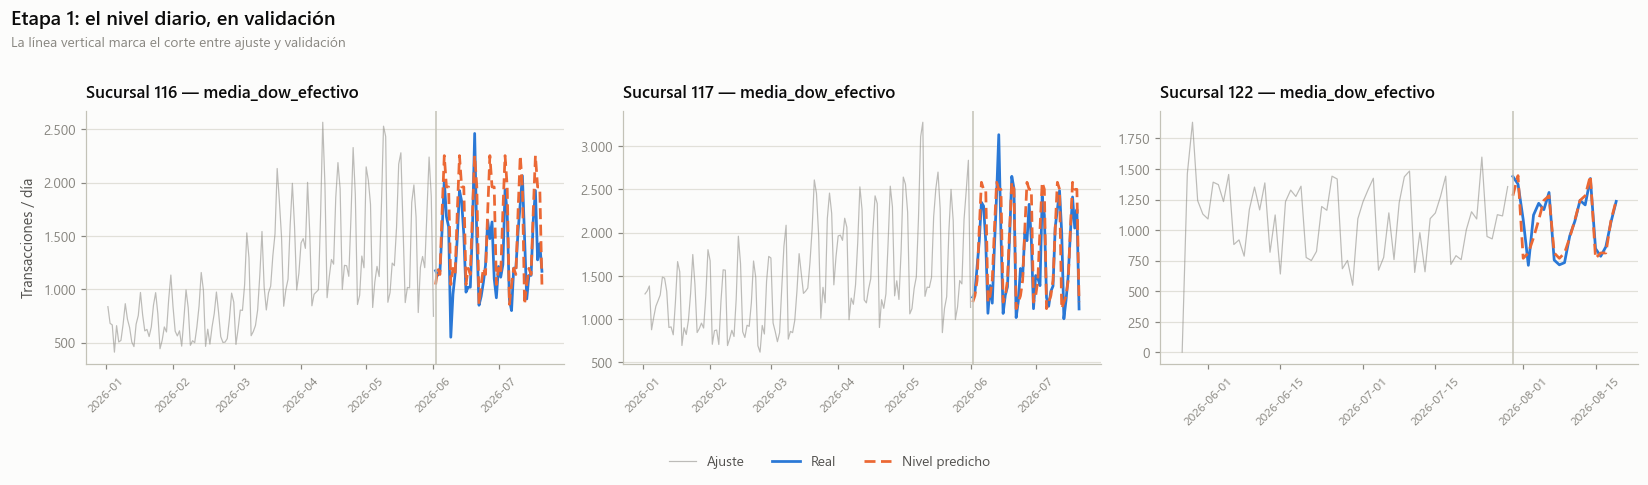

In [48]:
fig, axes = plt.subplots(1, len(SUCURSALES), figsize=(15, 4.4))
axes = np.atleast_1d(axes)
for ax, suc in zip(axes, SUCURSALES):
    aj, va, pr, c_val, c_pru = PARTICIONES[suc]
    s_aj, s_va = serie_diaria(aj), serie_diaria(va)
    modelo = MODELOS_NIVEL[suc]

    ax.plot(s_aj["fecha"], s_aj["transacciones"], color=TINTA_MUTE, lw=0.8, alpha=0.55,
            label="Ajuste")
    ax.plot(s_va["fecha"], s_va["transacciones"], color=SERIES[0], lw=1.8, label="Real")
    ax.plot(s_va["fecha"], modelo.predict(s_va["fecha"]), color=SERIES[1], lw=1.8,
            ls=(0, (4, 2)), label="Nivel predicho")
    ax.axvline(c_val, color=EJE, lw=1.0)
    marco(ax, f"Sucursal {suc} — {modelo.nombre}",
          ylabel="Transacciones / día" if suc == SUCURSALES[0] else None)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)

top = titulo_figura(fig, "Etapa 1: el nivel diario, en validación",
                    "La línea vertical marca el corte entre ajuste y validación")
bot = leyenda_figura(fig, axes[0], ncol=3)
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "12_nivel_diario")
plt.show()

### 12.4 Etapa 2 — la forma: qué modelo de regresión

Aquí se decide con qué se predice el reparto del día entre horas y estaciones. Compiten
**seis candidatos**, y a cada uno se le buscan sus propios hiperparámetros:

| Candidato | Qué es |
|---|---|
| `baseline` | Promedio histórico por estación, día efectivo y hora. El piso |
| `ridge` | Regresión lineal regularizada |
| `random_forest` | Muchos árboles en paralelo sobre muestras distintas, promediados |
| `extra_trees` | Igual, pero con cortes aleatorios en cada árbol |
| `hist_gb` | Árboles en fila, cada uno corrigiendo los errores del anterior |
| `hist_gb_log1p` | El mismo, entrenado contra `log1p` del objetivo |

Los últimos dos son el mismo modelo y se diferencian solo en la transformación del objetivo.
Están separados a propósito: permite ver cuánto cuesta esa transformación, que es sospechosa de
ser la que produce el sesgo de volumen.

Todos se ajustan sobre el bloque de **ajuste** y se comparan sobre el de **validación**. La
búsqueda usa validación cruzada **temporal y por fechas completas**: cada pliegue entrena con el
pasado y valida con el futuro inmediato. Un `KFold` normal barajaría las fechas y le dejaría ver
el futuro al modelo, lo que da métricas preciosas y un modelo inútil.

In [49]:
class DivisionTemporalPorFechas:
    '''Validación cruzada temporal: cada pliegue valida con el bloque de fechas
    siguiente al de entrenamiento.

    scikit-learn espera índices POSICIONALES, no etiquetas del índice del DataFrame:
    de ahí el np.flatnonzero en lugar de X.index[mask].
    '''

    def __init__(self, n_splits=3, min_dias_prueba=7):
        self.n_splits = n_splits
        self.min_dias_prueba = min_dias_prueba

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        fechas_fila = pd.to_datetime(np.asarray(X["fecha"]))
        fechas = np.array(sorted(pd.unique(fechas_fila)))
        tam = max(self.min_dias_prueba, len(fechas) // (self.n_splits + 2))

        for i in range(self.n_splits):
            fin = len(fechas) - tam * (self.n_splits - 1 - i)
            ini = fin - tam
            if ini <= 0:
                continue
            corte_ini = fechas[ini]
            en_train = fechas_fila < corte_ini
            en_test = (fechas_fila >= corte_ini) & (
                fechas_fila < fechas[fin] if fin < len(fechas) else np.full(len(fechas_fila), True))
            tr, te = np.flatnonzero(en_train), np.flatnonzero(en_test)
            if len(tr) and len(te):
                yield tr, te


ESPACIO_ARBOLES_BOOST = {
    "model__regressor__max_iter": randint(150, 600),
    "model__regressor__learning_rate": loguniform(0.02, 0.25),
    "model__regressor__max_depth": randint(3, 10),
    "model__regressor__min_samples_leaf": randint(10, 60),
    "model__regressor__l2_regularization": loguniform(0.05, 20),
}
ESPACIO_ARBOLES_BOSQUE = {
    "model__regressor__n_estimators": randint(120, 320),
    "model__regressor__max_depth": randint(8, 22),
    "model__regressor__min_samples_leaf": randint(2, 20),
    "model__regressor__max_features": ["sqrt", 0.5, 1.0],
}

CANDIDATOS_FORMA = {
    "ridge": dict(estimador=Ridge(), log=False,
                  espacio={"model__regressor__alpha": loguniform(0.01, 200)}),
    "random_forest": dict(estimador=RandomForestRegressor(random_state=SEMILLA, n_jobs=-1),
                          log=False, espacio=ESPACIO_ARBOLES_BOSQUE),
    "extra_trees": dict(estimador=ExtraTreesRegressor(random_state=SEMILLA, n_jobs=-1),
                        log=False, espacio=ESPACIO_ARBOLES_BOSQUE),
    "hist_gb": dict(estimador=HistGradientBoostingRegressor(random_state=SEMILLA),
                    log=False, espacio=ESPACIO_ARBOLES_BOOST),
    "hist_gb_log1p": dict(estimador=HistGradientBoostingRegressor(random_state=SEMILLA),
                          log=True, espacio=ESPACIO_ARBOLES_BOOST),
}
DESCRIPCION_MODELO = {
    "baseline":      "Promedio histórico por estación, día y hora",
    "ridge":         "Regresión lineal regularizada",
    "random_forest": "Bosque de árboles en paralelo (bagging)",
    "extra_trees":   "Bosque de árboles en paralelo con cortes aleatorios",
    "hist_gb":       "Árboles en secuencia (gradient boosting)",
    "hist_gb_log1p": "Árboles en secuencia, objetivo transformado con log1p",
}

N_ITER_BUSQUEDA = 10
N_PLIEGUES = 2

print(f"{len(CANDIDATOS_FORMA)} familias con búsqueda + 1 baseline · "
      f"{N_ITER_BUSQUEDA} combinaciones · {N_PLIEGUES} pliegues temporales")

5 familias con búsqueda + 1 baseline · 10 combinaciones · 2 pliegues temporales


In [50]:
import time

AJUSTADOS, comparacion_forma, resumen_busqueda = {}, [], []

for suc, (aj, va, pr, _, _) in PARTICIONES.items():
    y_va = va[TARGET].to_numpy(float)

    # --- el baseline no tiene nada que buscar -------------------------------
    modelo = BaselineEstacional().fit(aj[columnas()], aj[TARGET])
    AJUSTADOS[(suc, "baseline")] = modelo
    m = evaluar(y_va, modelo.predict(va[columnas()]))
    m["desvío del total"] = float(np.clip(modelo.predict(va[columnas()]), 0, None).sum()
                                  / y_va.sum() - 1)
    comparacion_forma.append({"sucursal": suc, "modelo": "baseline", **m})

    # --- las cinco familias con búsqueda ------------------------------------
    for nombre, cfg in CANDIDATOS_FORMA.items():
        t0 = time.time()
        busqueda = RandomizedSearchCV(
            construir_pipeline(cfg["estimador"], con_festivos=True, log_objetivo=cfg["log"]),
            cfg["espacio"], n_iter=N_ITER_BUSQUEDA,
            cv=DivisionTemporalPorFechas(n_splits=N_PLIEGUES),
            scoring="neg_mean_absolute_error",
            random_state=SEMILLA, n_jobs=1, refit=True,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            busqueda.fit(aj[columnas()], aj[TARGET])

        AJUSTADOS[(suc, nombre)] = busqueda.best_estimator_
        p = np.clip(busqueda.best_estimator_.predict(va[columnas()]), 0, None)
        m = evaluar(y_va, p)
        m["desvío del total"] = float(p.sum() / y_va.sum() - 1)
        comparacion_forma.append({"sucursal": suc, "modelo": nombre, **m})
        resumen_busqueda.append({
            "sucursal": suc, "modelo": nombre, "segundos": time.time() - t0,
            **{k.replace("model__regressor__", ""): v for k, v in busqueda.best_params_.items()},
        })
        print(f"  suc {suc} · {nombre:<14} MAE {m['mae']:.3f} · "
              f"desvío {m['desvío del total']:+.1%} · {time.time() - t0:.0f} s")

comparacion_forma = pd.DataFrame(comparacion_forma)
resumen_busqueda = pd.DataFrame(resumen_busqueda)

  suc 116 · ridge          MAE 6.464 · desvío +2.6% · 1 s
  suc 116 · random_forest  MAE 3.819 · desvío +11.3% · 27 s
  suc 116 · extra_trees    MAE 3.738 · desvío +10.8% · 19 s
  suc 116 · hist_gb        MAE 3.811 · desvío +5.1% · 50 s
  suc 116 · hist_gb_log1p  MAE 3.890 · desvío -11.3% · 46 s
  suc 117 · ridge          MAE 7.593 · desvío +6.4% · 1 s
  suc 117 · random_forest  MAE 4.021 · desvío +6.1% · 20 s
  suc 117 · extra_trees    MAE 3.920 · desvío +5.0% · 20 s
  suc 117 · hist_gb        MAE 4.088 · desvío +5.9% · 49 s
  suc 117 · hist_gb_log1p  MAE 3.969 · desvío -4.2% · 44 s
  suc 122 · ridge          MAE 6.423 · desvío +4.1% · 1 s
  suc 122 · random_forest  MAE 3.002 · desvío +1.2% · 13 s
  suc 122 · extra_trees    MAE 3.011 · desvío +0.3% · 12 s
  suc 122 · hist_gb        MAE 3.317 · desvío +3.2% · 53 s
  suc 122 · hist_gb_log1p  MAE 3.169 · desvío -15.2% · 50 s


#### Hiperparámetros elegidos

Un resumen de qué configuración encontró la búsqueda para cada familia y sucursal. La
comparación entre modelos viene en la sección siguiente.

In [51]:
_hp = resumen_busqueda.copy()
_hp["sucursal"] = _hp["sucursal"].map(ETIQUETA_SUC)
_hp["tipo"] = _hp["modelo"].map(DESCRIPCION_MODELO)
_hp = _hp[["sucursal", "modelo", "tipo"] + [c for c in _hp.columns
                                            if c not in ("sucursal", "modelo", "tipo")]]
display(_hp.astype({c: str for c in _hp.columns if _hp[c].dtype == object})
        .style.format({"segundos": "{:,.0f}"}, na_rep="—").hide(axis="index"))

sucursal,modelo,tipo,segundos,alpha,max_depth,max_features,min_samples_leaf,n_estimators,l2_regularization,learning_rate,max_iter
116 Atlantis,ridge,Regresión lineal regularizada,1,139.554048,—,—,—,—,—,—,—
116 Atlantis,random_forest,Bosque de árboles en paralelo (bagging),27,—,20.000000,0.500000,2.000000,187.000000,—,—,—
116 Atlantis,extra_trees,Bosque de árboles en paralelo con cortes aleatorios,19,—,19.000000,0.500000,6.000000,207.000000,—,—,—
116 Atlantis,hist_gb,Árboles en secuencia (gradient boosting),50,—,6.000000,—,13.000000,—,1.339725,0.121767,401.000000
116 Atlantis,hist_gb_log1p,"Árboles en secuencia, objetivo transformado con log1p",46,—,6.000000,—,13.000000,—,1.339725,0.121767,401.000000
117 Santafe,ridge,Regresión lineal regularizada,1,139.554048,—,—,—,—,—,—,—
117 Santafe,random_forest,Bosque de árboles en paralelo (bagging),20,—,20.000000,0.500000,2.000000,187.000000,—,—,—
117 Santafe,extra_trees,Bosque de árboles en paralelo con cortes aleatorios,20,—,19.000000,0.500000,6.000000,207.000000,—,—,—
117 Santafe,hist_gb,Árboles en secuencia (gradient boosting),49,—,6.000000,—,13.000000,—,1.339725,0.121767,401.000000
117 Santafe,hist_gb_log1p,"Árboles en secuencia, objetivo transformado con log1p",44,—,5.000000,—,34.000000,—,5.293959,0.180034,249.000000


### 12.5 La comparación final: qué configuración se usa

Cada uno de los seis modelos se evalúa de dos formas: **solo** y **con el ajuste de nivel** de la
etapa 1. Son doce configuraciones, todas sobre el mismo bloque de validación, ordenadas de mejor
a peor.

Así la pregunta "¿aporta la serie de tiempo?" se responde mirando la tabla: cada modelo aparece
dos veces y se ve cuál de las dos versiones quedó más arriba.

Gana la de menor MAE, con una regla de desempate: **diferencias por debajo del 1 % son ruido**,
así que entre configuraciones que empatan dentro de ese margen se queda la más simple, es decir
la que no lleva el ajuste de nivel. No tiene sentido cargar con una etapa más para ganar dos
milésimas que no se sostendrían con otro bloque de fechas.

La configuración ganadora se usa en las tres sucursales.

In [52]:
@dataclass
class ModeloSucursal:
    '''Las dos etapas juntas. Con `nivel=None` es solo regresión, sin reescalar.'''
    sucursal: int
    forma: object
    nivel: object = None
    estaciones: list = None
    ventana: dict = None
    fecha_max_entrenamiento: pd.Timestamp = None
    columnas_forma: list = None

    @property
    def nombre(self):
        return "solo_regresion" if self.nivel is None else f"regresion + {self.nivel.nombre}"

    def predecir(self, grilla: pd.DataFrame) -> np.ndarray:
        cols = self.columnas_forma or columnas()
        base = np.clip(self.forma.predict(grilla[cols]), 0, None)
        if self.nivel is None:
            return base

        fechas = grilla["fecha"]
        suma_dia = pd.Series(base, index=grilla.index).groupby(fechas).transform("sum").to_numpy()
        unicas = pd.DatetimeIndex(sorted(fechas.unique()))
        objetivo = fechas.map(pd.Series(self.nivel.predict(unicas), index=unicas)).to_numpy(float)

        # Si la forma da 0 en todo un día, no hay cómo repartir el nivel: queda en 0.
        factor = np.divide(objetivo, suma_dia, out=np.zeros_like(base), where=suma_dia > 0)
        return base * factor


print("Configuraciones listas.")

Configuraciones listas.


In [53]:
SUFIJO_NIVEL = " + serie de tiempo"

filas = []
for suc, (aj, va, pr, _, _) in PARTICIONES.items():
    y_va = va[TARGET].to_numpy(float)
    for nombre in ["baseline"] + list(CANDIDATOS_FORMA):
        forma = AJUSTADOS[(suc, nombre)]
        for con_nivel in (False, True):
            modelo = ModeloSucursal(suc, forma,
                                    MODELOS_NIVEL[suc] if con_nivel else None,
                                    columnas_forma=columnas())
            p = modelo.predecir(va)
            m = evaluar(y_va, p)
            filas.append({
                "sucursal": suc,
                "configuracion": nombre + (SUFIJO_NIVEL if con_nivel else ""),
                "modelo": nombre, "serie_de_tiempo": con_nivel,
                **m, "desvío del total": float(p.sum() / y_va.sum() - 1),
            })

comparacion_config = pd.DataFrame(filas)

ranking = comparacion_config.pivot(index="configuracion", columns="sucursal", values="mae")
ranking.columns = [ETIQUETA_SUC[c] for c in ranking.columns]
ranking["MAE promedio"] = ranking.mean(axis=1)
ranking = ranking.sort_values("MAE promedio")

_desv = comparacion_config.pivot(index="configuracion", columns="sucursal",
                                 values="desvío del total").abs().mean(axis=1)
_r2 = comparacion_config.pivot(index="configuracion", columns="sucursal", values="r2").mean(axis=1)

ranking.insert(0, "puesto", range(1, len(ranking) + 1))
ranking.insert(1, "tipo de modelo", [
    DESCRIPCION_MODELO[c.replace(SUFIJO_NIVEL, "")] + (" + ajuste de nivel diario"
                                                       if c.endswith(SUFIJO_NIVEL) else "")
    for c in ranking.index])
ranking["R2 promedio"] = _r2.reindex(ranking.index)
ranking["|desvío| promedio"] = _desv.reindex(ranking.index)

display(ranking.style.format({
    "puesto": "{:.0f}", "MAE promedio": "{:,.3f}", "R2 promedio": "{:.3f}",
    "|desvío| promedio": "{:.1%}",
    **{c: "{:,.3f}" for c in ranking.columns
       if c not in ("puesto", "tipo de modelo", "MAE promedio", "R2 promedio",
                    "|desvío| promedio")},
}).set_caption("Las 12 configuraciones, de mejor a peor por MAE en validación"))

,puesto,tipo de modelo,116 Atlantis,117 Santafe,122 Atrio,MAE promedio,R2 promedio,|desvío| promedio
configuracion,,,,,,,,
extra_trees + serie de tiempo,1,Bosque de árboles en paralelo con cortes aleatorios + ajuste de nivel diario,3.801,3.945,2.921,3.556,0.806,6.5%
extra_trees,2,Bosque de árboles en paralelo con cortes aleatorios,3.738,3.920,3.011,3.556,0.804,5.4%
random_forest + serie de tiempo,3,Bosque de árboles en paralelo (bagging) + ajuste de nivel diario,3.862,4.010,2.933,3.602,0.799,6.5%
random_forest,4,Bosque de árboles en paralelo (bagging),3.819,4.021,3.002,3.614,0.799,6.2%
baseline,5,"Promedio histórico por estación, día y hora",3.762,4.281,2.877,3.640,0.782,10.2%
hist_gb_log1p,6,"Árboles en secuencia, objetivo transformado con log1p",3.890,3.969,3.169,3.676,0.769,10.2%
baseline + serie de tiempo,7,"Promedio histórico por estación, día y hora + ajuste de nivel diario",3.946,4.342,2.848,3.712,0.790,6.5%
hist_gb,8,Árboles en secuencia (gradient boosting),3.811,4.088,3.317,3.739,0.797,4.7%
hist_gb + serie de tiempo,9,Árboles en secuencia (gradient boosting) + ajuste de nivel diario,4.018,4.082,3.168,3.756,0.788,6.5%


In [54]:
# --- Elección, con regla de desempate explícita -----------------------------
# Diferencias de MAE por debajo de MARGEN_EMPATE son ruido: no hay razón para creer
# que se sostendrían con otro bloque de fechas. Entre configuraciones que empatan
# dentro de ese margen gana la MÁS SIMPLE, o sea la que no lleva ajuste de nivel.
MARGEN_EMPATE = 0.01

_mejor_mae = ranking["MAE promedio"].min()
_empatadas = ranking[ranking["MAE promedio"] <= _mejor_mae * (1 + MARGEN_EMPATE)]
_simples = _empatadas[~_empatadas.index.str.endswith(SUFIJO_NIVEL)]

GANADORA = (_simples["MAE promedio"].idxmin() if len(_simples)
            else _empatadas["MAE promedio"].idxmin())

if len(_empatadas) > 1:
    print(f"{len(_empatadas)} configuraciones empatan dentro del "
          f"{MARGEN_EMPATE:.0%} del mejor MAE:")
    for nombre in _empatadas.sort_values("MAE promedio").index:
        marca = " <- elegida" if nombre == GANADORA else ""
        print(f"   {nombre:<34} MAE {ranking.loc[nombre, 'MAE promedio']:.4f} · "
              f"desvío {ranking.loc[nombre, '|desvío| promedio']:.1%}{marca}")
    print("Gana la más simple: la diferencia de MAE es ruido y el desvío de volumen")
    print("es igual o mejor.")
    print()

_fila = comparacion_config[comparacion_config["configuracion"] == GANADORA].iloc[0]
MEJOR_MODELO = _fila["modelo"]
USAR_NIVEL = bool(_fila["serie_de_tiempo"])

MODELOS_FORMA = {suc: AJUSTADOS[(suc, MEJOR_MODELO)] for suc in SUCURSALES}
CONFIG_ELEGIDA = {suc: GANADORA for suc in SUCURSALES}

_piso = ranking.loc["baseline", "MAE promedio"]
_par = GANADORA + SUFIJO_NIVEL if not USAR_NIVEL else GANADORA.replace(SUFIJO_NIVEL, "")

print("=" * 72)
print(f"MEJOR MODELO:  {GANADORA}")
print(f"  {ranking.loc[GANADORA, 'tipo de modelo']}")
print("=" * 72)
print(f"  MAE promedio        {ranking.loc[GANADORA, 'MAE promedio']:.3f}")
print(f"  R2 promedio         {ranking.loc[GANADORA, 'R2 promedio']:.3f}")
print(f"  Desvío de volumen   {ranking.loc[GANADORA, '|desvío| promedio']:.1%}")
print(f"  Contra el baseline  {1 - ranking.loc[GANADORA, 'MAE promedio'] / _piso:+.1%}")
print()
print("¿Aporta la etapa de serie de tiempo?")
print(f"  {GANADORA:<32} MAE {ranking.loc[GANADORA, 'MAE promedio']:.3f} · "
      f"puesto {int(ranking.loc[GANADORA, 'puesto'])}")
print(f"  {_par:<32} MAE {ranking.loc[_par, 'MAE promedio']:.3f} · "
      f"puesto {int(ranking.loc[_par, 'puesto'])}")
print(f"  -> {'SÍ se usa' if USAR_NIVEL else 'NO se usa'}: la versión "
      f"{'con' if USAR_NIVEL else 'sin'} ajuste quedó por encima.")

2 configuraciones empatan dentro del 1% del mejor MAE:
   extra_trees + serie de tiempo      MAE 3.5556 · desvío 6.5%
   extra_trees                        MAE 3.5564 · desvío 5.4% <- elegida
Gana la más simple: la diferencia de MAE es ruido y el desvío de volumen
es igual o mejor.

MEJOR MODELO:  extra_trees
  Bosque de árboles en paralelo con cortes aleatorios
  MAE promedio        3.556
  R2 promedio         0.804
  Desvío de volumen   5.4%
  Contra el baseline  +2.3%

¿Aporta la etapa de serie de tiempo?
  extra_trees                      MAE 3.556 · puesto 2
  extra_trees + serie de tiempo    MAE 3.556 · puesto 1
  -> NO se usa: la versión sin ajuste quedó por encima.


**Qué mirar en las dos tablas.** El MAE dice cuánto se equivoca celda a celda; el desvío del
total, si el volumen del periodo queda bien dimensionado. La regresión sola tiende a subestimar
el volumen —efecto de entrenar en escala logarítmica, cuya transformación inversa devuelve algo
cercano a la mediana—, y ahí es donde el reescalado al nivel diario tiene más que aportar.

Puede pasar que la de dos etapas gane en desvío del total pero no en MAE. Son dos cosas
distintas y conviene decidir sabiendo cuál importa más para el uso: para programar turnos,
acertar el volumen del día pesa bastante.

### 12.6 ¿Cuánto aportan los festivos?

La configuración ganadora de cada sucursal, con y sin las cinco variables de festivo. Se quitan
de las dos etapas a la vez, porque ambas las usan. También sobre validación.

In [55]:
def construir_configuracion(suc, aj, con_festivos=True, con_nivel=True):
    '''Arma una configuración desde cero para la ablación, con hiperparámetros fijos
    (los de la búsqueda no aplican si cambian las columnas de entrada).'''
    forma = construir_pipeline(
        HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, max_depth=6,
                                      min_samples_leaf=20, l2_regularization=1.0,
                                      random_state=SEMILLA), con_festivos=con_festivos)
    forma.fit(aj[columnas(con_festivos)], aj[TARGET])

    nivel = None
    if con_nivel:
        # Con festivos, el nivel usa el día efectivo; sin ellos, el de calendario.
        nivel = ajustar_nivel(NivelMediaDowEfectivo if con_festivos else NivelMediaDow,
                              serie_diaria(aj))
    return ModeloSucursal(suc, forma, nivel, columnas_forma=columnas(con_festivos))


ablacion = []
for suc, (aj, va, pr, _, _) in PARTICIONES.items():
    y_va = va[TARGET].to_numpy(float)
    fila = {"sucursal": ETIQUETA_SUC[suc], "configuración": GANADORA}

    for etiqueta, con in [("con festivos", True), ("sin festivos", False)]:
        modelo = construir_configuracion(suc, aj, con_festivos=con, con_nivel=USAR_NIVEL)
        m = evaluar(y_va, modelo.predecir(va))
        fila[f"MAE {etiqueta}"] = m["mae"]
        fila[f"WMAPE {etiqueta}"] = m["wmape"] * 100

    fila["mejora MAE"] = 1 - fila["MAE con festivos"] / fila["MAE sin festivos"]
    ablacion.append(fila)

ablacion = pd.DataFrame(ablacion)
display(ablacion.style.format({
    "MAE con festivos": "{:,.3f}", "MAE sin festivos": "{:,.3f}",
    "WMAPE con festivos": "{:,.1f} %", "WMAPE sin festivos": "{:,.1f} %",
    "mejora MAE": "{:+.1%}"}).hide(axis="index"))
print("La mejora se mide sobre toda la validación, donde los festivos son pocos días.")
print("Concentrada en esos días concretos es bastante mayor.")

sucursal,configuración,MAE con festivos,WMAPE con festivos,MAE sin festivos,WMAPE sin festivos,mejora MAE
116 Atlantis,extra_trees,3.758,42.7 %,3.873,44.0 %,+3.0%
117 Santafe,extra_trees,4.026,35.1 %,4.338,37.9 %,+7.2%
122 Atrio,extra_trees,3.255,44.2 %,3.502,47.5 %,+7.1%


La mejora se mide sobre toda la validación, donde los festivos son pocos días.
Concentrada en esos días concretos es bastante mayor.


### 12.7 Exactitud sobre el conjunto de prueba

Ya está todo decidido: el modelo de nivel, los hiperparámetros y la configuración. Ahora las dos
etapas se reajustan sobre **ajuste + validación** —porque el bloque de validación también es
historia útil— y se evalúan **una sola vez** sobre la prueba, que no participó en nada.

| Métrica | Cómo leerla |
|---|---|
| **Exactitud (1 - WMAPE)** | Lo más cercano a un porcentaje de acierto: qué fracción del volumen queda bien explicada |
| **MAE** | Cuántas transacciones se equivoca en promedio, por celda de hora-estación |
| **RMSE** | Igual, pero castiga más los errores grandes |
| **R2** | Cuánta de la variación real captura |
| **Dentro de ±2 / ±5 tx** | Qué porcentaje de las celdas cae lo bastante cerca para decidir un turno |

In [56]:
MODELOS_PRUEBA = {}
errores, exactitud = [], []

for suc, (aj, va, pr, _, c_pru) in PARTICIONES.items():
    desarrollo = pd.concat([aj, va], ignore_index=True)

    if MEJOR_MODELO == "baseline":
        forma = BaselineEstacional().fit(desarrollo[columnas()], desarrollo[TARGET])
    else:
        forma = clone(MODELOS_FORMA[suc])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            forma.fit(desarrollo[columnas()], desarrollo[TARGET])

    nivel = (ajustar_nivel(type(MODELOS_NIVEL[suc]), serie_diaria(desarrollo))
             if USAR_NIVEL else None)

    modelo = ModeloSucursal(suc, forma, nivel, datos[suc].estaciones, VENTANAS[suc], c_pru)
    MODELOS_PRUEBA[suc] = modelo

    pr = pr.copy()
    pr["sucursal"] = suc
    pr["pred"] = modelo.predecir(pr)
    pr["error_abs"] = (pr["pred"] - pr[TARGET]).abs()
    errores.append(pr)

    y, p = pr[TARGET].to_numpy(float), pr["pred"].to_numpy(float)
    m = evaluar(y, p)
    exactitud.append({
        "sucursal": ETIQUETA_SUC[suc], "configuración": GANADORA,
        "días de prueba": pr["fecha"].nunique(), "celdas": len(pr),
        "desde": c_pru.date(), "hasta": pr["fecha"].max().date(),
        "exactitud (1-WMAPE)": 1 - m["wmape"],
        "MAE": m["mae"], "RMSE": m["rmse"], "R2": m["r2"],
        "dentro de ±2 tx": float(np.mean(np.abs(y - p) <= 2)),
        "dentro de ±5 tx": float(np.mean(np.abs(y - p) <= 5)),
        "desvío del total": float(p.sum() / y.sum() - 1),
    })

errores = pd.concat(errores, ignore_index=True)
exactitud = pd.DataFrame(exactitud)
display(exactitud.style.format({
    "exactitud (1-WMAPE)": "{:.1%}", "MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.3f}",
    "dentro de ±2 tx": "{:.1%}", "dentro de ±5 tx": "{:.1%}", "celdas": "{:,.0f}",
    "desvío del total": "{:+.1%}"}).hide(axis="index"))

sucursal,configuración,días de prueba,celdas,desde,hasta,exactitud (1-WMAPE),MAE,RMSE,R2,dentro de ±2 tx,dentro de ±5 tx,desvío del total
116 Atlantis,extra_trees,50,"7,710",2026-07-22,2026-09-09,62.9%,3.43,5.85,0.794,52.2%,76.5%,-4.6%
117 Santafe,extra_trees,50,"7,640",2026-07-22,2026-09-09,68.2%,3.62,5.79,0.824,50.5%,73.2%,-1.7%
122 Atrio,extra_trees,21,"3,030",2026-08-20,2026-09-09,61.4%,3.09,6.29,0.876,58.8%,80.6%,-6.7%


### 12.8 Real contra predicho

Tres vistas del mismo conjunto de prueba. La dispersión dice si acierta celda a celda; la serie
diaria, si acierta en el volumen que importa para programar personal; y el perfil horario, si la
forma del día está bien puesta.

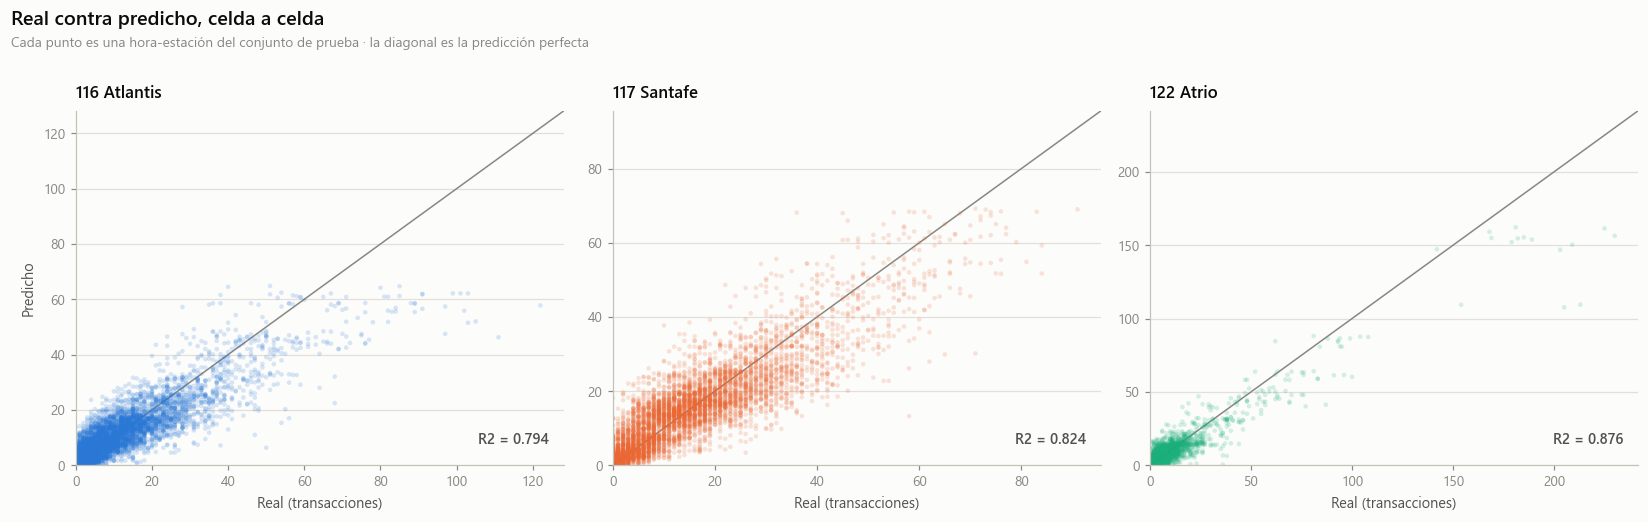

In [57]:
fig, axes = plt.subplots(1, len(SUCURSALES), figsize=(15, 4.8))
axes = np.atleast_1d(axes)
for ax, suc in zip(axes, SUCURSALES):
    e = errores[errores["sucursal"] == suc]
    lim = max(e[TARGET].max(), e["pred"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color=TINTA_MUTE, lw=1.0, zorder=1)
    ax.scatter(e[TARGET], e["pred"], s=9, alpha=0.18, color=COLOR_SUC[suc],
               edgecolors="none", zorder=2)
    r2 = exactitud.loc[exactitud["sucursal"] == ETIQUETA_SUC[suc], "R2"].iloc[0]
    ax.text(0.97, 0.06, f"R2 = {r2:.3f}", transform=ax.transAxes, ha="right",
            fontsize=9.5, color=TINTA_2, fontweight="semibold")
    marco(ax, ETIQUETA_SUC[suc], xlabel="Real (transacciones)",
          ylabel="Predicho" if suc == SUCURSALES[0] else None)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

top = titulo_figura(fig, "Real contra predicho, celda a celda",
                    "Cada punto es una hora-estación del conjunto de prueba · "
                    "la diagonal es la predicción perfecta")
fig.tight_layout(rect=[0, 0, 1, top])
guardar(fig, "12_dispersion_real_predicho")
plt.show()

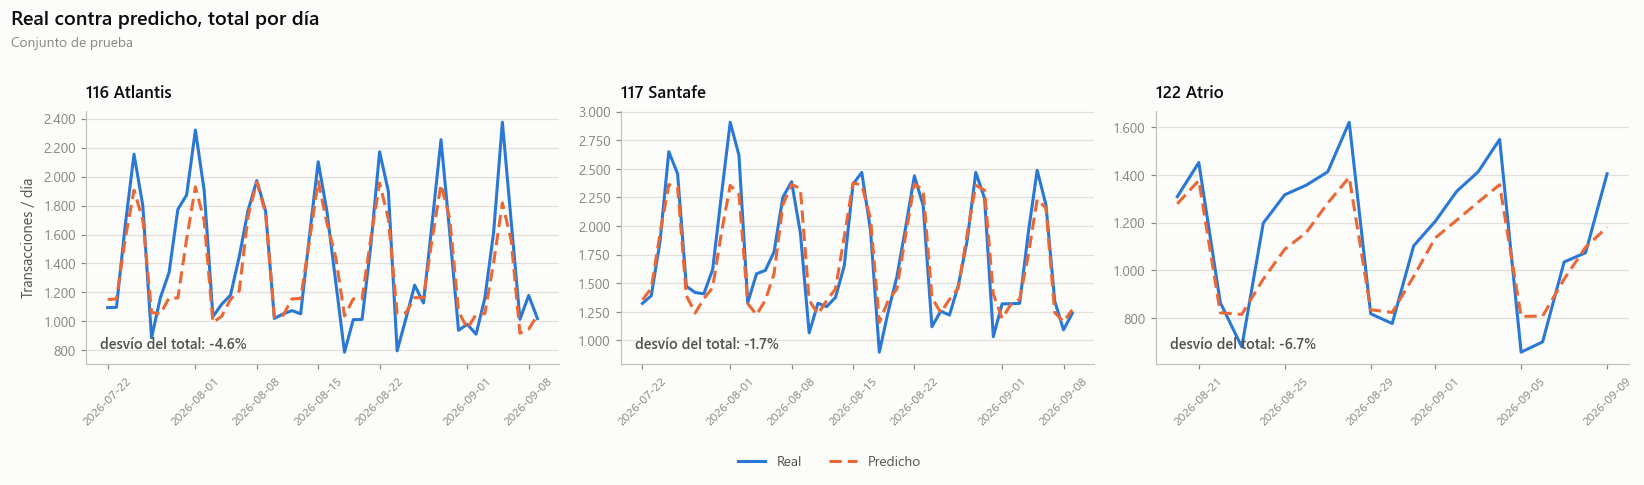

In [58]:
fig, axes = plt.subplots(1, len(SUCURSALES), figsize=(15, 4.4))
axes = np.atleast_1d(axes)
for ax, suc in zip(axes, SUCURSALES):
    g = (errores[errores["sucursal"] == suc]
         .groupby("fecha", as_index=False)[[TARGET, "pred"]].sum())
    ax.plot(g["fecha"], g[TARGET], color=SERIES[0], label="Real", lw=2)
    ax.plot(g["fecha"], g["pred"], color=SERIES[1], label="Predicho", lw=2, ls=(0, (4, 2)))
    desv = g["pred"].sum() / g[TARGET].sum() - 1
    ax.text(0.03, 0.06, f"desvío del total: {desv:+.1%}", transform=ax.transAxes,
            fontsize=9.5, color=TINTA_2, fontweight="semibold")
    marco(ax, ETIQUETA_SUC[suc],
          ylabel="Transacciones / día" if suc == SUCURSALES[0] else None)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)

top = titulo_figura(fig, "Real contra predicho, total por día", "Conjunto de prueba")
bot = leyenda_figura(fig, axes[0], ncol=2)
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "12_serie_real_predicho")
plt.show()

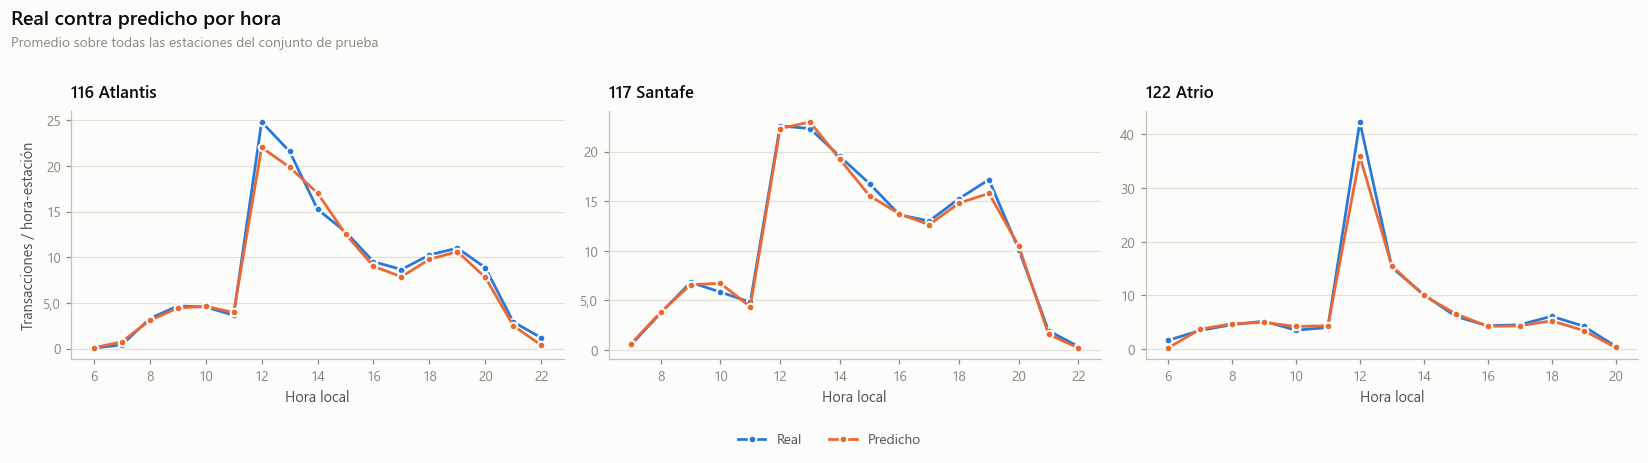

In [59]:
fig, axes = plt.subplots(1, len(SUCURSALES), figsize=(15, 4.2))
axes = np.atleast_1d(axes)
for ax, suc in zip(axes, SUCURSALES):
    g = (errores[errores["sucursal"] == suc]
         .groupby("hora", observed=True).agg(real=(TARGET, "mean"), pred=("pred", "mean")))
    ax.plot(g.index, g["real"], color=SERIES[0], label="Real", marker="o",
            markeredgecolor=SUPERFICIE, markeredgewidth=1.3)
    ax.plot(g.index, g["pred"], color=SERIES[1], label="Predicho", marker="o",
            markeredgecolor=SUPERFICIE, markeredgewidth=1.3)
    marco(ax, ETIQUETA_SUC[suc], xlabel="Hora local",
          ylabel="Transacciones / hora-estación" if suc == SUCURSALES[0] else None)

top = titulo_figura(fig, "Real contra predicho por hora",
                    "Promedio sobre todas las estaciones del conjunto de prueba")
bot = leyenda_figura(fig, axes[0], ncol=2)
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "12_real_vs_predicho_hora")
plt.show()

### 12.9 Error por estación

Un MAE global esconde dónde falla. Para dotación importa más acertar en la hora pico de Parrilla
que en el promedio.

In [60]:
for suc in SUCURSALES:
    e = errores[errores["sucursal"] == suc]
    t = (e.groupby("estacion", observed=True)
         .agg(real=(TARGET, "mean"), predicho=("pred", "mean"), mae=("error_abs", "mean"))
         .assign(sesgo=lambda x: x["predicho"] / x["real"].replace(0, np.nan) - 1)
         .sort_values("mae", ascending=False))
    print(f"--- {ETIQUETA_SUC[suc]}: error por estación (conjunto de prueba) ---")
    display(t.style.format({"real": "{:,.2f}", "predicho": "{:,.2f}", "mae": "{:,.2f}",
                            "sesgo": "{:+.1%}"}, na_rep="—"))

--- 116 Atlantis: error por estación (conjunto de prueba) ---


,real,predicho,mae,sesgo
estacion,,,,
Cocina Fria,20.56,18.06,6.58,-12.2%
Parrilla,14.42,13.88,5.01,-3.8%
Panaderia Y Reposteria,11.85,11.60,4.71,-2.1%
preparacion de bebidas,10.03,10.18,4.18,+1.5%
Sodas,9.83,9.10,3.66,-7.3%
Pastas,11.06,10.47,3.58,-5.3%
Freidora / Apanados,7.50,7.77,2.84,+3.6%
Jugos,5.80,5.66,2.60,-2.4%
Licores,1.43,1.50,1.15,+5.6%


--- 117 Santafe: error por estación (conjunto de prueba) ---


,real,predicho,mae,sesgo
estacion,,,,
Cocina Fria,22.92,22.51,5.91,-1.8%
Panaderia Y Reposteria,15.97,15.62,5.77,-2.2%
Parrilla,17.90,17.48,5.29,-2.4%
preparacion de bebidas,13.77,14.07,4.91,+2.2%
Pastas,13.53,12.83,3.88,-5.2%
Sodas,10.22,9.87,3.20,-3.4%
Jugos,8.67,8.79,3.12,+1.4%
Freidora / Apanados,9.44,9.21,3.01,-2.4%
Licores,1.51,1.65,1.10,+9.3%


--- 122 Atrio: error por estación (conjunto de prueba) ---


,real,predicho,mae,sesgo
estacion,,,,
Cocina Fria,20.14,17.23,7.12,-14.4%
Panaderia Y Reposteria,11.37,11.37,5.09,-0.1%
preparacion de bebidas,10.81,10.84,4.13,+0.3%
Parrilla,11.61,11.33,4.04,-2.4%
Pastas,7.94,7.35,2.74,-7.3%
Sodas,6.98,6.22,2.58,-10.9%
Jugos,4.69,4.07,2.23,-13.1%
Freidora / Apanados,5.54,5.43,2.07,-2.1%
Licores,1.04,0.91,0.89,-12.8%


### 12.10 Modelo final

Con todo decidido y medido, las dos etapas se reentrenan **sobre el historial completo**,
incluida la prueba: es el tramo más reciente y por lo tanto el más informativo sobre el
presente, así que dejarlo fuera del modelo de producción sería desperdiciarlo.

Los hiperparámetros se conservan tal como salieron de la búsqueda; lo que se reajusta son los
parámetros del modelo.

In [61]:
MODELOS = {}
for suc, d in datos.items():
    if MEJOR_MODELO == "baseline":
        forma = BaselineEstacional().fit(d.frame[columnas()], d.frame[TARGET])
    else:
        forma = clone(MODELOS_FORMA[suc])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            forma.fit(d.frame[columnas()], d.frame[TARGET])

    nivel = (ajustar_nivel(type(MODELOS_NIVEL[suc]), serie_diaria(d.frame))
             if USAR_NIVEL else None)

    MODELOS[suc] = ModeloSucursal(suc, forma, nivel, d.estaciones, VENTANAS[suc], d.fecha_max)
    print(f"{ETIQUETA_SUC[suc]}: '{GANADORA}' reentrenado sobre {len(d.frame):,} filas")

116 Atlantis: 'extra_trees' reentrenado sobre 38,730 filas
117 Santafe: 'extra_trees' reentrenado sobre 38,370 filas
122 Atrio: 'extra_trees' reentrenado sobre 15,300 filas


### Resumen — el modelo

**El mejor modelo es ExtraTrees**, un bosque de árboles en paralelo con cortes aleatorios, con
variables de calendario y festivos. Solo, sin ajuste de nivel. Las tres sucursales usan lo mismo.

### El ranking completo

Doce configuraciones: los seis modelos, cada uno con y sin el ajuste de serie de tiempo. MAE
promedio en validación, de mejor a peor.

| Puesto | Configuración | Atlantis | Santafé | Atrio | Promedio | Desvío |
|---|---|---|---|---|---|---|
| 1 | extra_trees + serie de tiempo | 3,80 | 3,95 | 2,92 | 3,5556 | 6,5 % |
| 2 | **extra_trees** | 3,74 | 3,92 | 3,01 | **3,5564** | **5,4 %** |
| 3 | random_forest + serie de tiempo | 3,86 | 4,01 | 2,93 | 3,602 | 6,5 % |
| 4 | random_forest | 3,82 | 4,02 | 3,00 | 3,614 | 6,2 % |
| 5 | baseline | 3,76 | 4,28 | 2,88 | 3,640 | 10,2 % |
| 6 | hist_gb_log1p | 3,89 | 3,97 | 3,17 | 3,676 | 10,2 % |
| 7 | baseline + serie de tiempo | 3,95 | 4,34 | 2,85 | 3,712 | 6,5 % |
| 8 | hist_gb | 3,81 | 4,09 | 3,32 | 3,739 | 4,7 % |
| 9 | hist_gb + serie de tiempo | 4,02 | 4,08 | 3,17 | 3,756 | 6,5 % |
| 10 | hist_gb_log1p + serie de tiempo | 4,35 | 4,01 | 2,94 | 3,765 | 6,5 % |
| 11 | ridge + serie de tiempo | 6,65 | 7,52 | 6,29 | 6,818 | 6,5 % |
| 12 | ridge | 6,46 | 7,59 | 6,42 | 6,827 | 4,4 % |

**Por qué gana el puesto 2 y no el 1.** La diferencia entre los dos primeros es de 0,0008 en
MAE, un 0,02 %. Eso es ruido: no hay razón para creer que se sostendría con otro bloque de
fechas. La regla de desempate se queda con la configuración más simple, que además alinea mejor
el volumen (5,4 % contra 6,5 %).

### La serie de tiempo no aporta

Cada modelo aparece dos veces en la tabla y el patrón es claro: **añadir el ajuste de nivel no
mejora nada de forma consistente**. Mejora algo en Atrio y empeora en Atlantis, y en promedio
queda igual.

Tiene explicación. La etapa de serie de tiempo se había introducido para corregir un sesgo de
volumen del 17 %, que venía de entrenar contra `log1p` del objetivo. Al quitar esa
transformación el sesgo bajó solo a 5 %, y la etapa se quedó sin trabajo que hacer.

Queda implementada y medida, con `USAR_NIVEL` decidiéndose solo a partir de la tabla. Si más
adelante, con más datos, vuelve a aportar, se enciende sin tocar código.

### Por qué los árboles y no una regresión lineal

Ridge queda último, con casi el doble de error. La demanda no crece parejo con la hora: se
dispara a las 12 y se desploma a las 15. Y el efecto de la hora depende de la estación, igual
que el del día depende de la sucursal. A un modelo lineal hay que escribirle esas interacciones
a mano; los árboles las encuentran solos.

Entre los árboles, en cambio, la diferencia es chica. Del puesto 1 al 5 hay un 2,4 %, y el
promedio histórico está ahí en medio. **Con esta cantidad de datos, la familia del modelo no es
donde está la palanca.**

### El log1p había que quitarlo

El mismo modelo con y sin la transformación del objetivo:

| | MAE promedio | Desvío del volumen |
|---|---|---|
| `hist_gb` (sin log1p) | 3,739 | **4,7 %** |
| `hist_gb_log1p` | 3,676 | **10,2 %** |

Mejora el error por celda un 2 %, pero duplica el desvío del volumen. La transformación inversa
devuelve algo cercano a la mediana, así que el modelo subestima el total.

### Resultados sobre la prueba

El bloque de prueba no participó en nada: ni en ajustar, ni en buscar hiperparámetros, ni en
decidir.

| Sucursal | Exactitud | MAE | R2 | Dentro de ±2 tx | Dentro de ±5 tx | Desvío del total |
|---|---|---|---|---|---|---|
| 116 Atlantis | 62,9 % | 3,43 | 0,794 | 52,2 % | 76,5 % | -4,6 % |
| 117 Santafé | 68,2 % | 3,62 | 0,824 | 50,5 % | 73,2 % | -1,7 % |
| 122 Atrio | 61,4 % | 3,09 | 0,876 | 58,8 % | 80,6 % | -6,7 % |

Tres de cada cuatro celdas caen dentro de ±5 transacciones del valor real. El error típico es de
3 a 4 transacciones en celdas donde las horas pico manejan entre 20 y 50.

### Los festivos aportan más que cambiar de modelo

| Sucursal | Mejora en MAE al agregarlos |
|---|---|
| 116 Atlantis | +3,0 % |
| 117 Santafé | +7,2 % |
| 122 Atrio | +7,1 % |

Hasta un 7 %, contra el 2,3 % que saca el mejor modelo sobre el promedio histórico. La variable
pesa más que el algoritmo.

### Dónde está la palanca

Cambiar de modelo mueve un 2 %. Lo que movería de verdad:

- **Mapear los 134 ítems sin estación.** Hoy se descarta el 5,7 % del volumen.
- **Más historial**, sobre todo de Atrio, que con 106 días es donde el promedio histórico casi
  no se deja ganar.
- **Un año completo**, para poder proyectar octubre a diciembre con algo más que extrapolación.

## 13. Consulta: proyección por rango de fechas

La función que resuelve el caso de uso. Se le pasa una sucursal y un rango, y devuelve una fila
por `fecha × hora × estación` con la transaccionalidad estimada.

Usa `construir_grilla()` y `marcar_calendario()`, **las mismas funciones del entrenamiento**, así
que las variables que ve al proyectar son exactamente las que vio al aprender. Los festivos se
calculan, no se consultan de una tabla, así que funciona para cualquier fecha futura.

In [62]:
def proyectar(sucursal: int, desde, hasta, estaciones=None) -> pd.DataFrame:
    '''Transaccionalidad estimada por fecha, hora y estación para un rango de fechas.

    Devuelve una fila por combinación válida: solo las horas en que esa sucursal opera
    ese día de la semana.
    '''
    if sucursal not in MODELOS:
        raise KeyError(f"No hay modelo para la sucursal {sucursal}. Disponibles: {sorted(MODELOS)}")

    modelo = MODELOS[sucursal]
    fechas = pd.date_range(pd.to_datetime(desde), pd.to_datetime(hasta), freq="D")
    if len(fechas) == 0:
        raise ValueError("El rango de fechas está vacío.")

    grilla = construir_grilla(sucursal, fechas, estaciones or modelo.estaciones)
    if grilla.empty:
        return pd.DataFrame()

    grilla["transacciones_estimadas"] = modelo.predecir(grilla).round(2)

    # Avisos de extrapolación: el historial solo cubre 8 meses, así que no hay
    # estacionalidad anual aprendida y diciembre nunca se ha visto.
    dias_futuro = (fechas.max() - modelo.fecha_max_entrenamiento).days
    if dias_futuro > 90:
        print(f"AVISO: se está proyectando {dias_futuro} días más allá del último dato de "
              "entrenamiento. La incertidumbre crece con la distancia.")
    meses_vistos = set(pd.DatetimeIndex(datos[sucursal].frame["fecha"]).month)
    meses_nuevos = sorted(set(fechas.month) - meses_vistos)
    if meses_nuevos:
        print(f"AVISO: el rango incluye meses sin historial {meses_nuevos}. El nivel se "
              "extrapola con la serie de tiempo, pero no hay estacionalidad anual aprendida.")

    salida = grilla[["fecha", "hora", "area", "estacion", "transacciones_estimadas",
                     "es_festivo", "es_puente"]].copy()
    salida["dia"] = salida["fecha"].dt.dayofweek.map(dict(enumerate(DIAS_ES)))
    return (salida[["fecha", "dia", "hora", "area", "estacion",
                    "transacciones_estimadas", "es_festivo", "es_puente"]]
            .sort_values(["fecha", "hora", "area", "estacion"]).reset_index(drop=True))


print("Función `proyectar(sucursal, desde, hasta)` lista.")

Función `proyectar(sucursal, desde, hasta)` lista.


### 13.1 Ejemplo — una semana de la sucursal 116

In [63]:
DESDE = "2026-09-14"   # lunes
HASTA = "2026-09-20"   # domingo

proyeccion = proyectar(116, DESDE, HASTA)
print(f"{len(proyeccion):,} filas · {proyeccion['fecha'].nunique()} días · "
      f"{proyeccion['estacion'].nunique()} estaciones")
display(proyeccion.head(12).style.format({"transacciones_estimadas": "{:,.2f}"}).hide(axis="index"))

1,080 filas · 7 días · 10 estaciones


fecha,dia,hora,area,estacion,transacciones_estimadas,es_festivo,es_puente
2026-09-14 00:00:00,Lunes,7,Bar,Jugos,0.13,0,0
2026-09-14 00:00:00,Lunes,7,Bar,Sodas,0.25,0,0
2026-09-14 00:00:00,Lunes,7,Cocina 1,Cocina Fria,0.10,0,0
2026-09-14 00:00:00,Lunes,7,Cocina 1,Freidora / Apanados,0.01,0,0
2026-09-14 00:00:00,Lunes,7,Cocina 1,Parrilla,0.01,0,0
2026-09-14 00:00:00,Lunes,7,Cocina 2,Pastas,0.10,0,0
2026-09-14 00:00:00,Lunes,7,SIN AREA,Licores,0.00,0,0
2026-09-14 00:00:00,Lunes,7,Salon,Caja / Toma Pedidos,0.00,0,0
2026-09-14 00:00:00,Lunes,7,Todo Fresa,Panaderia Y Reposteria,1.09,0,0
2026-09-14 00:00:00,Lunes,7,Todo Fresa,preparacion de bebidas,2.17,0,0


### 13.2 Las tres vistas que pide el negocio

In [64]:
print("1) Por estación y hora — la vista operativa para armar turnos:")
display(proyeccion[proyeccion["fecha"] == proyeccion["fecha"].min()]
        .pivot_table(index="hora", columns="estacion", values="transacciones_estimadas",
                     aggfunc="sum", observed=True)
        .style.format("{:,.1f}", na_rep="—")
        .set_caption(f"Sucursal 116 — {proyeccion['fecha'].min():%Y-%m-%d}"))

print("\n2) Por área de servicio y día:")
display(proyeccion.pivot_table(index="area", columns="dia", values="transacciones_estimadas",
                               aggfunc="sum", observed=True)
        .reindex(columns=[d for d in DIAS_ES if d in set(proyeccion["dia"])])
        .style.format("{:,.0f}", na_rep="—"))

print("\n3) Total por día:")
display(proyeccion.groupby(["fecha", "dia"], as_index=False)["transacciones_estimadas"].sum()
        .style.format({"transacciones_estimadas": "{:,.0f}"}).hide(axis="index"))

1) Por estación y hora — la vista operativa para armar turnos:


estacion,Caja / Toma Pedidos,Cocina Fria,Freidora / Apanados,Jugos,Licores,Panaderia Y Reposteria,Parrilla,Pastas,Sodas,preparacion de bebidas
hora,,,,,,,,,,
7,0.0,0.1,0.0,0.1,0.0,1.1,0.0,0.1,0.2,2.2
8,0.0,1.6,0.1,1.9,0.0,8.6,5.0,0.4,1.8,8.6
9,0.0,3.2,0.2,1.2,0.0,6.3,5.2,0.5,1.5,7.2
10,0.0,2.3,0.1,1.3,0.0,7.8,5.5,0.7,2.5,8.5
11,0.0,2.7,0.7,0.9,0.2,8.1,2.1,1.2,1.6,7.7
12,0.0,77.0,21.4,17.2,2.7,15.2,41.1,30.5,28.0,16.2
13,0.0,46.8,15.0,11.9,1.7,14.1,26.4,20.6,19.8,13.5
14,0.0,21.5,7.0,7.5,0.6,9.3,12.7,10.3,8.6,9.6
15,0.0,14.5,6.2,4.2,0.4,10.8,8.4,7.3,7.0,8.3



2) Por área de servicio y día:


dia,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
area,,,,,,,
Bar,168,174,186,192,270,368,299
Cocina 1,448,476,502,511,731,981,816
Cocina 2,104,112,122,124,186,260,210
SIN AREA,9,10,16,22,38,34,20
Salon,0,0,0,0,0,0,0
Todo Fresa,246,253,261,290,362,492,403



3) Total por día:


fecha,dia,transacciones_estimadas
2026-09-14 00:00:00,Lunes,976
2026-09-15 00:00:00,Martes,"1,025"
2026-09-16 00:00:00,Miércoles,"1,086"
2026-09-17 00:00:00,Jueves,"1,140"
2026-09-18 00:00:00,Viernes,"1,587"
2026-09-19 00:00:00,Sábado,"2,136"
2026-09-20 00:00:00,Domingo,"1,748"


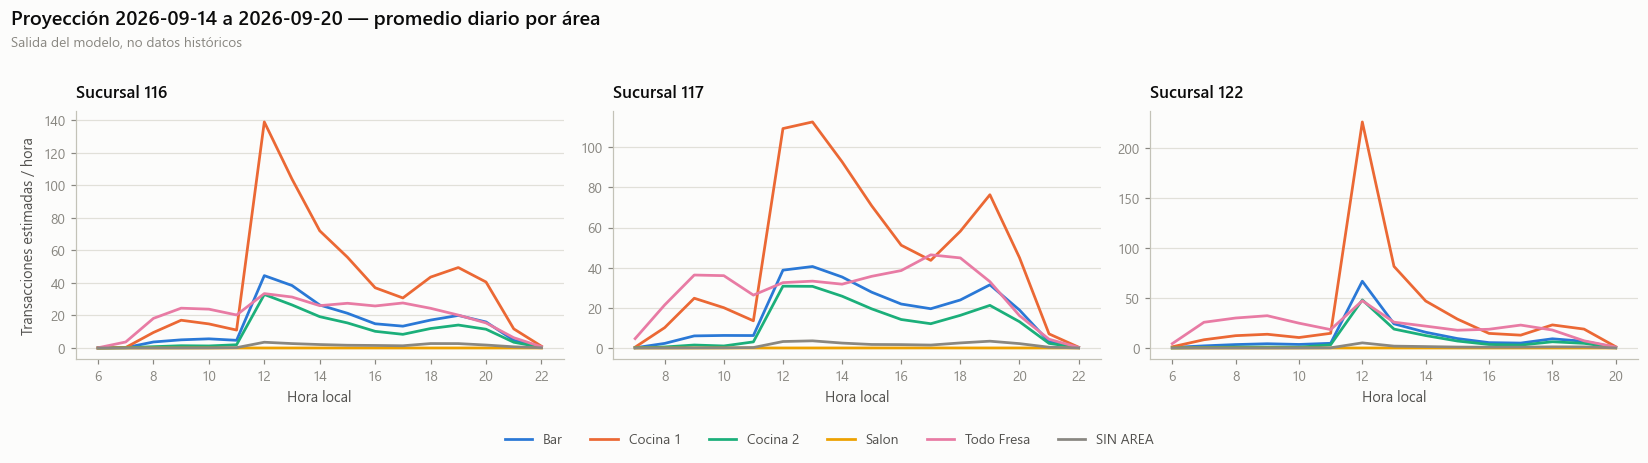

In [65]:
# Proyección de las tres sucursales para el mismo rango
proyecciones = {}
for suc in SUCURSALES:
    p = proyectar(suc, DESDE, HASTA)
    p["sucursal"] = suc
    proyecciones[suc] = p
proyeccion_todas = pd.concat(proyecciones.values(), ignore_index=True)

fig, axes = plt.subplots(1, len(SUCURSALES), figsize=(15, 4.2))
axes = np.atleast_1d(axes)
for ax, suc in zip(axes, SUCURSALES):
    p = proyecciones[suc]
    m = p.pivot_table(index="area", columns="hora", values="transacciones_estimadas",
                      aggfunc="sum", observed=True).fillna(0)
    m = m / p["fecha"].nunique()
    for area in ORDEN_AREAS:
        if area not in m.index:
            continue
        ax.plot(m.columns, m.loc[area], color=COLOR_AREA[area], label=area)
    marco(ax, f"Sucursal {suc}", xlabel="Hora local",
          ylabel="Transacciones estimadas / hora" if suc == SUCURSALES[0] else None)

top = titulo_figura(fig, f"Proyección {DESDE} a {HASTA} — promedio diario por área",
                    "Salida del modelo, no datos históricos")
bot = leyenda_figura(fig, axes[0], ncol=len(ORDEN_AREAS))
fig.tight_layout(rect=[0, bot, 1, top])
guardar(fig, "13_proyeccion_area")
plt.show()

### 13.3 De transacciones a personas

El puente hacia la dotación: la proyección dividida por el benchmark de `Productividad`
(sección 5.7) da las personas-hora que exige cada estación en su hora pico.

Se muestran **los tres niveles de habilidad**, porque la diferencia entre ellos es
justamente la decisión que hay que tomar: BÁSICO es la cota pesimista, AVANZADO la optimista,
e INTERMEDIO lo más parecido a una dotación mixta realista. La columna de personas es
`pico / transacciones por hora del nivel`.

In [66]:
NIVELES = ["BASICO", "INTERMEDIO", "AVANZADO"]

bench = productividad.pivot_table(index="estacion", columns="nivel", values="tx_hora")
bench = bench.reindex(columns=NIVELES)

pico = (proyeccion.groupby("estacion", observed=True)["transacciones_estimadas"].max()
        .rename("pico horario proyectado").to_frame().join(bench))
for nivel in NIVELES:
    pico[f"personas ({nivel})"] = pico["pico horario proyectado"] / pico[nivel]
pico = pico.sort_values("pico horario proyectado", ascending=False)

formato = {"pico horario proyectado": "{:,.1f}"}
formato.update({n: "{:,.0f}" for n in NIVELES})
formato.update({f"personas ({n})": "{:,.2f}" for n in NIVELES})
display(pico.style.format(formato, na_rep="— sin benchmark")
        .set_caption("Personas-hora necesarias en la hora pico, según el nivel del personal"))

_total = pico[[f"personas ({n})" for n in NIVELES]].sum()
print("Suma de personas-hora en el pico, si TODA la dotación fuera de un mismo nivel:")
for nivel in NIVELES:
    print(f"   {nivel:<11} {_total[f'personas ({nivel})']:.1f} personas")
print("(Es una suma de picos, no una dotación simultánea: cada estación llega a su pico")
print(" en una hora distinta, así que el máximo real del turno es menor.)\n")

_sin = pico[pico["AVANZADO"].isna()].index.tolist()
print(f"Estaciones con demanda proyectada pero SIN benchmark de productividad: {_sin}")
print("Para esas, el modelo proyecta carga pero no se puede traducir a personas.")
print("Es el pendiente de la sección 7.5 que bloquea el cierre del ciclo demanda -> dotación.")

,pico horario proyectado,BASICO,INTERMEDIO,AVANZADO,personas (BASICO),personas (INTERMEDIO),personas (AVANZADO)
estacion,,,,,,,
Cocina Fria,82.0,24,37,52,3.42,2.22,1.58
Parrilla,47.1,21,32,45,2.24,1.47,1.05
Pastas,38.3,28,42,59,1.37,0.91,0.65
Sodas,31.6,28,43,60,1.13,0.74,0.53
Freidora / Apanados,27.4,31,47,65,0.88,0.58,0.42
Panaderia Y Reposteria,25.3,14,22,30,1.80,1.15,0.84
preparacion de bebidas,22.3,19,29,40,1.18,0.77,0.56
Jugos,20.0,21,32,45,0.95,0.62,0.44
Licores,6.2,— sin benchmark,— sin benchmark,— sin benchmark,— sin benchmark,— sin benchmark,— sin benchmark


Suma de personas-hora en el pico, si TODA la dotación fuera de un mismo nivel:
   BASICO      13.0 personas
   INTERMEDIO  8.5 personas
   AVANZADO    6.1 personas
(Es una suma de picos, no una dotación simultánea: cada estación llega a su pico
 en una hora distinta, así que el máximo real del turno es menor.)

Estaciones con demanda proyectada pero SIN benchmark de productividad: ['Licores', 'Caja / Toma Pedidos']
Para esas, el modelo proyecta carga pero no se puede traducir a personas.
Es el pendiente de la sección 7.5 que bloquea el cierre del ciclo demanda -> dotación.


### Resumen — la proyección

`proyectar(sucursal, desde, hasta)` devuelve una fila por `fecha x hora x estación`, solo para
las horas en que esa sucursal vende ese día de la semana. Los festivos del rango se calculan
solos.

Las tres vistas cubren los usos reales: estación por hora para armar el turno del día, área por
día para repartir el personal de la semana, y el total diario para presupuesto.

La sección 13.3 divide el pico proyectado por el benchmark de `Productividad` y da las
personas-hora que exige cada estación, en los tres niveles de habilidad. Ahí aparece el límite:
las estaciones sin benchmark quedan con carga proyectada pero sin traducción a personas.

Tres advertencias de uso:

- La función avisa si se proyecta más de 90 días más allá del último dato.
- También avisa si el rango entra en meses sin historial. Los datos llegan hasta septiembre, así
  que octubre a diciembre nunca se han visto. Para un restaurante de centro comercial, diciembre
  es probablemente el mes más atípico del año.
- Los modelos se reentrenan con el historial completo, así que conviene volver a correr el
  notebook cuando entren datos nuevos.

## 14. Guardado de los modelos

Un artefacto por sucursal con todo lo necesario para proyectar sin volver a entrenar: el
objeto `ModeloSucursal` con sus dos etapas, las estaciones, la ventana horaria y el mapa de
áreas.

**Ojo al recargarlos desde otro script:** el artefacto contiene instancias de clases definidas
en este notebook (`ModeloSucursal`, los modelos de nivel y, si ganó, `BaselineEstacional`).
Para hacerle `joblib.load` desde otro archivo hay que tener esas clases importables. Lo más
práctico es moverlas a un `.py` aparte que importen tanto el notebook como el consumidor.

In [67]:
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)
rutas = []
for suc, modelo in MODELOS.items():
    ruta = CARPETA_SALIDA / f"modelo_transaccionalidad_suc{suc}.joblib"
    joblib.dump({"modelo": modelo, "configuracion": GANADORA,
                 "mapa_area": MAPA_AREA, "features": columnas(),
                 "generado": pd.Timestamp.now().isoformat()}, ruta)
    rutas.append(ruta)
    print(f"  {ruta.name}  ({ruta.stat().st_size / 1024**2:.1f} MB)  "
          f"[{GANADORA}]")

# Verificación de ida y vuelta: el artefacto guardado reproduce la misma predicción
_art = joblib.load(rutas[0])
_g = construir_grilla(SUCURSALES[0], pd.date_range(DESDE, DESDE), _art["modelo"].estaciones)
_p = _art["modelo"].predecir(_g).round(2)
_o = proyecciones[SUCURSALES[0]].query("fecha == @DESDE")["transacciones_estimadas"].values
print(f"\nVerificación: el artefacto recargado reproduce la proyección. "
      f"Diferencia máxima: {np.abs(np.sort(_p) - np.sort(_o)).max():.6f}")

  modelo_transaccionalidad_suc116.joblib  (96.3 MB)  [extra_trees]
  modelo_transaccionalidad_suc117.joblib  (94.2 MB)  [extra_trees]
  modelo_transaccionalidad_suc122.joblib  (22.7 MB)  [extra_trees]

Verificación: el artefacto recargado reproduce la proyección. Diferencia máxima: 0.000000


## 15. Exportación

In [68]:
hojas = {
    "inventario_fuentes": inventario,
    "calidad_hallazgos": hallazgos,
    "cobertura_ventas": cobertura.reset_index(),
    "ventana_operativa": ventana_tabla,
    "festivos": calendario,
    "efecto_festivo": efecto,
    "kpi_sucursal": kpi.reset_index(),
    "analisis_area": res_area,
    "analisis_estacion": res_est,
    "modelos_nivel": comparacion_nivel,
    "comparacion_modelos": comparacion_forma,
    "ranking_configuraciones": ranking.reset_index(),
    "hiperparametros": resumen_busqueda.astype(str),
    "comparacion_config": comparacion_config,
    "exactitud_prueba": exactitud,
    "ablacion_festivos": ablacion,
    "proyeccion_ejemplo": proyeccion_todas,
    "maestro_areas": areas,
    "productividad": productividad,
}
with pd.ExcelWriter(ARCHIVO_RESUMEN, engine="openpyxl") as w:
    for nombre, tabla in hojas.items():
        tabla.to_excel(w, sheet_name=nombre[:31], index=False)

print(f"Excel: {ARCHIVO_RESUMEN}\n")
for nombre, tabla in hojas.items():
    print(f"   {nombre:<22} {len(tabla):>7,} filas")
if GUARDAR_FIGURAS:
    print(f"\n{len(list(CARPETA_SALIDA.glob('*.png')))} figuras en {CARPETA_SALIDA}")

Excel: C:\Users\andre\salidas_modelo\analisis_y_proyeccion.xlsx

   inventario_fuentes          14 filas
   calidad_hallazgos           13 filas
   cobertura_ventas             3 filas
   ventana_operativa           21 filas
   festivos                    36 filas
   efecto_festivo               3 filas
   kpi_sucursal                 3 filas
   analisis_area               18 filas
   analisis_estacion           30 filas
   modelos_nivel               15 filas
   comparacion_modelos         18 filas
   ranking_configuraciones      12 filas
   hiperparametros             15 filas
   comparacion_config          36 filas
   exactitud_prueba             3 filas
   ablacion_festivos            3 filas
   proyeccion_ejemplo       3,160 filas
   maestro_areas               19 filas
   productividad               36 filas

17 figuras en C:\Users\andre\salidas_modelo


## 16. Conclusiones y pendientes

### El modelo

**El mejor modelo es ExtraTrees** — un bosque de árboles en paralelo con cortes aleatorios —
entrenado con variables de calendario y festivos, con hiperparámetros buscados por sucursal.
Se usa solo, sin ajuste de serie de tiempo, y es el mismo en las tres sucursales.

Sobre la prueba da entre 61 % y 68 % de exactitud, R2 entre 0,79 y 0,88, y tres de cada cuatro
celdas de hora-estación caen dentro de ±5 transacciones del valor real.

Se compararon **doce configuraciones**: seis modelos, cada uno con y sin ajuste de nivel. Tres
cosas quedaron claras:

1. **Ridge se descarta.** Casi el doble de error. La demanda no es lineal en la hora y el efecto
   de la hora depende de la estación; a un modelo lineal hay que escribirle esas interacciones a
   mano.
2. **Entre los árboles la diferencia es chica.** Del primero al quinto puesto hay un 2,4 %, y el
   promedio histórico está ahí en medio. Con esta cantidad de datos, la familia del modelo no es
   donde está la palanca.
3. **La serie de tiempo no aporta.** Se había introducido para corregir un sesgo de volumen del
   17 % que venía de entrenar contra `log1p`. Al quitar esa transformación el sesgo bajó a 5 %
   y la etapa se quedó sin trabajo. Queda implementada y medida por si con más datos vuelve a
   servir.

### Sobre los datos

4. La fuente de ventas es sólida: 658.259 líneas, 8 meses, sin nulos y con solo 4 filas de
   digitación errada. El problema está en los maestros, no en el historial.
5. 134 ítems vendidos no tienen estación asignada. Son 41.219 unidades, el 5,7 % del volumen,
   que hoy no se le atribuyen a ninguna estación.
6. `Estaciones Sucursal` declara las mismas 19 estaciones para las 6 sucursales, y solo 10
   registran ventas. No sirve para saber qué existe en cada local.
7. `Licores` no tiene área y varias estaciones no tienen benchmark de productividad. Eso rompe
   el paso de proyección a dotación.
8. El horario declarado no coincide con el observado en ninguna sucursal.
9. El modelo no puede dimensionar el Salón: su actividad no pasa por el sistema de ventas.

### Sobre el modelado

10. El efecto del festivo tiene signo opuesto entre las de centro comercial y la de oficinas.
    Por eso hay un modelo por sucursal y no uno solo.
11. **Los festivos aportan entre 3 % y 7 % de mejora en MAE, más que cambiar de familia de
    modelo.** La variable pesa más que el algoritmo.
12. Sin rezagos, porque el caso de uso es proyectar rangos arbitrarios. Un `lag_1d` mejoraría el
    pronóstico de mañana pero no existe a siete días vista.
13. Octubre a diciembre nunca se han visto. Hay que tener cuidado al proyectar temporada alta.

### Lo que hay que resolver antes de la siguiente iteración

Ordenado por cuánto movería el resultado, no por dificultad:

| Pendiente | Quién |
|---|---|
| Mapear en `Estaciones x Item` los 134 ítems que hoy quedan sin estación | Operaciones |
| Conseguir más historial, sobre todo de Atrio | TI / API |
| Definir benchmark de productividad para las estaciones que no lo tienen | Operaciones |
| Asignarle área de servicio a `Licores` | Operaciones |
| Corregir `Estaciones Sucursal` para que refleje cada local | Operaciones |
| Definir cómo se captura la actividad del Salón | Operaciones |
| Conseguir historial de las 3 sucursales sin datos | TI / API |
| Un año completo de historial, para poder proyectar diciembre | Tiempo |